<a href="https://colab.research.google.com/github/OJB-Quantum/Monte-Carlo-Sim/blob/main/Onri_Benally_Career_Monte_Carlo_Sim_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [ ]:
!uv pip install cupy-cuda12x

CUDA device: NVIDIA L4
Compute capability: 8.9
GPU memory: 21.84 GiB free / 22.03 GiB total
CuPy version: 14.0.1
L4 profile active: True
Main trajectories per path: 100,000,000
Sensitivity trajectories per cell: 1,000,000
GPU memory target: 88.0%
Maximum batch cap: 16,000,000
Engine: fused CuPy annual updates, streaming reductions, heavy-tailed private-equity outcomes, career signals, and recruiting-bonus events.
Wealth thresholds use a post-tax liquid-wealth proxy. Quantiles use a high-resolution streaming logarithmic histogram.
Benchmarking candidate GPU batch sizes...
  500,000: 2,872.84 million annual updates/s
  1,000,000: 10,256.56 million annual updates/s
  2,000,000: 6,260.50 million annual updates/s
  4,000,000: 5,876.37 million annual updates/s
  6,000,000: 5,870.05 million annual updates/s
  8,000,000: 5,950.26 million annual updates/s
  12,000,000: 6,051.18 million annual updates/s
  16,000,000: 6,113.42 million annual updates/s
Selected measured maximum-throughput batch si

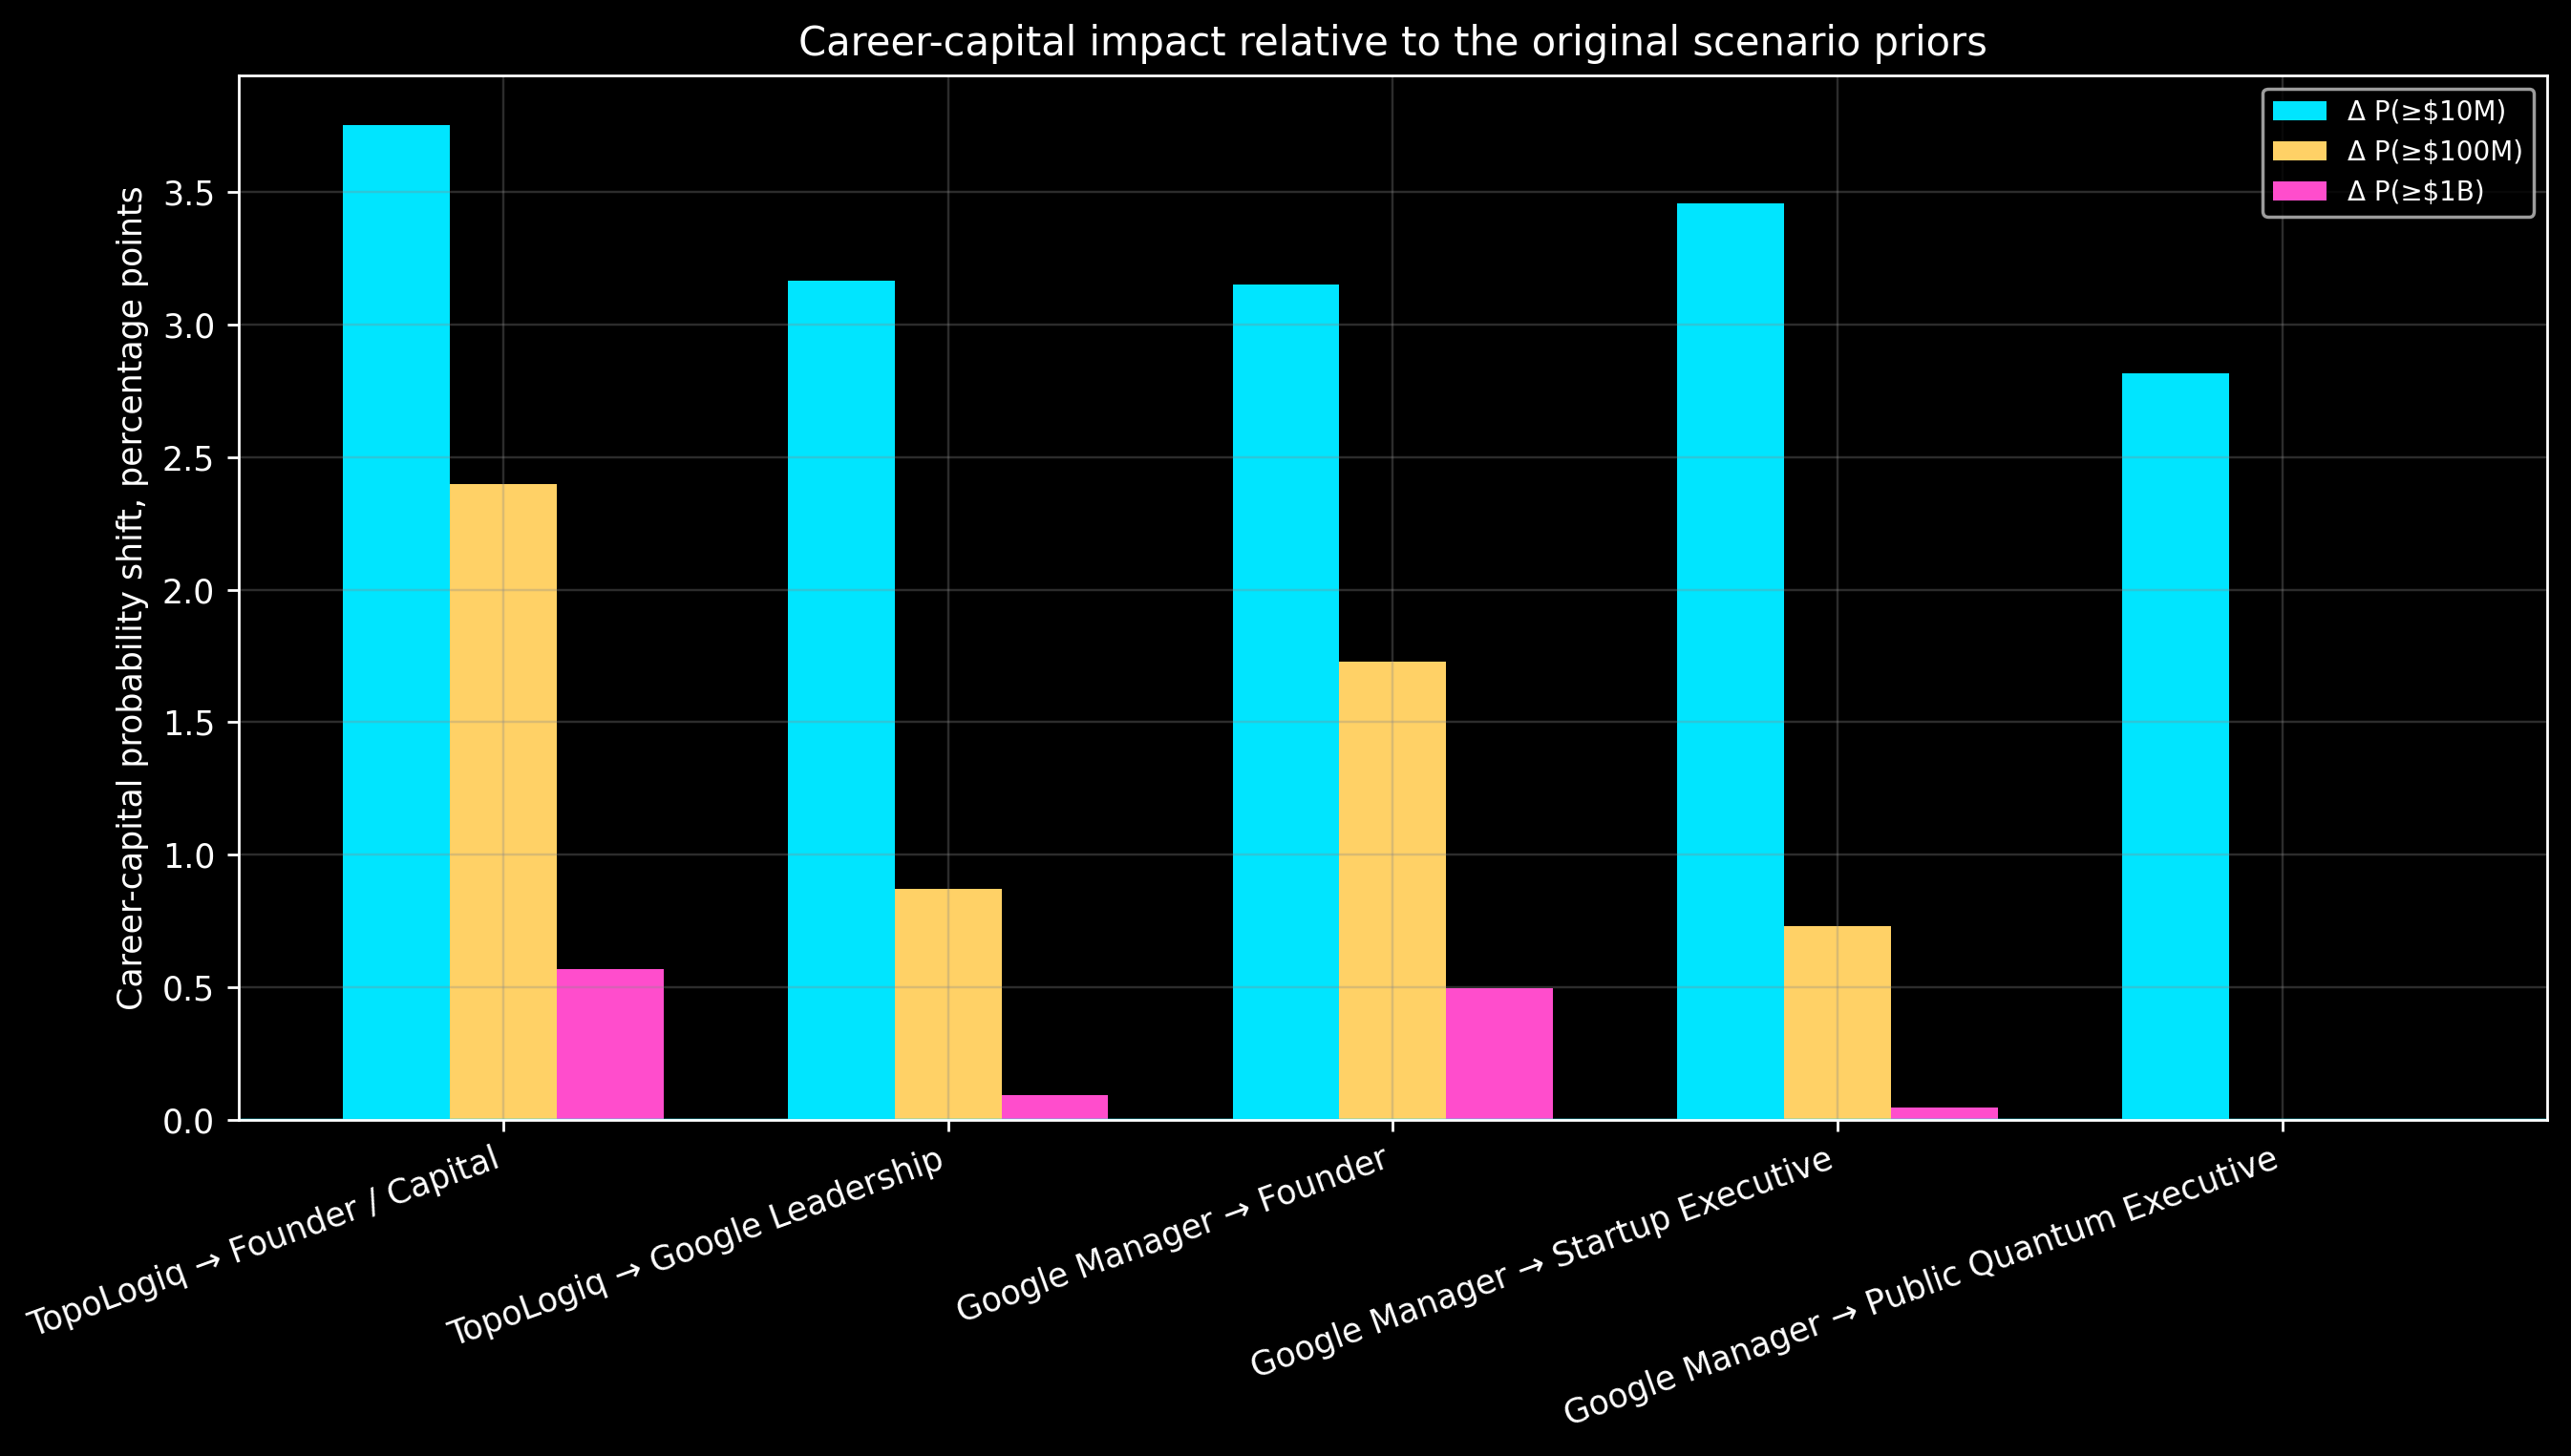


Running career-only versus competitive-offer diagnostic with 5,000,000 trajectories per path and prior.

Competitive-offer incremental impact diagnostic
                                     Path  Career-only P(≥$10M), %  Full-prior P(≥$10M), %  Offer Δ P(≥$10M), pp  Career-only P(≥$100M), %  Full-prior P(≥$100M), %  Offer Δ P(≥$100M), pp  Career-only P(≥$1B), %  Full-prior P(≥$1B), %  Offer Δ P(≥$1B), pp
            TopoLogiq → Founder / Capital                61.657460               64.089740              2.432280                 17.819080                18.183180               0.364100                2.784120               2.843320             0.059200
            TopoLogiq → Google Leadership                73.568780               81.971700              8.402920                  6.663760                 7.144980               0.481220                0.492620               0.538160             0.045540
                 Google Manager → Founder                49.747380               

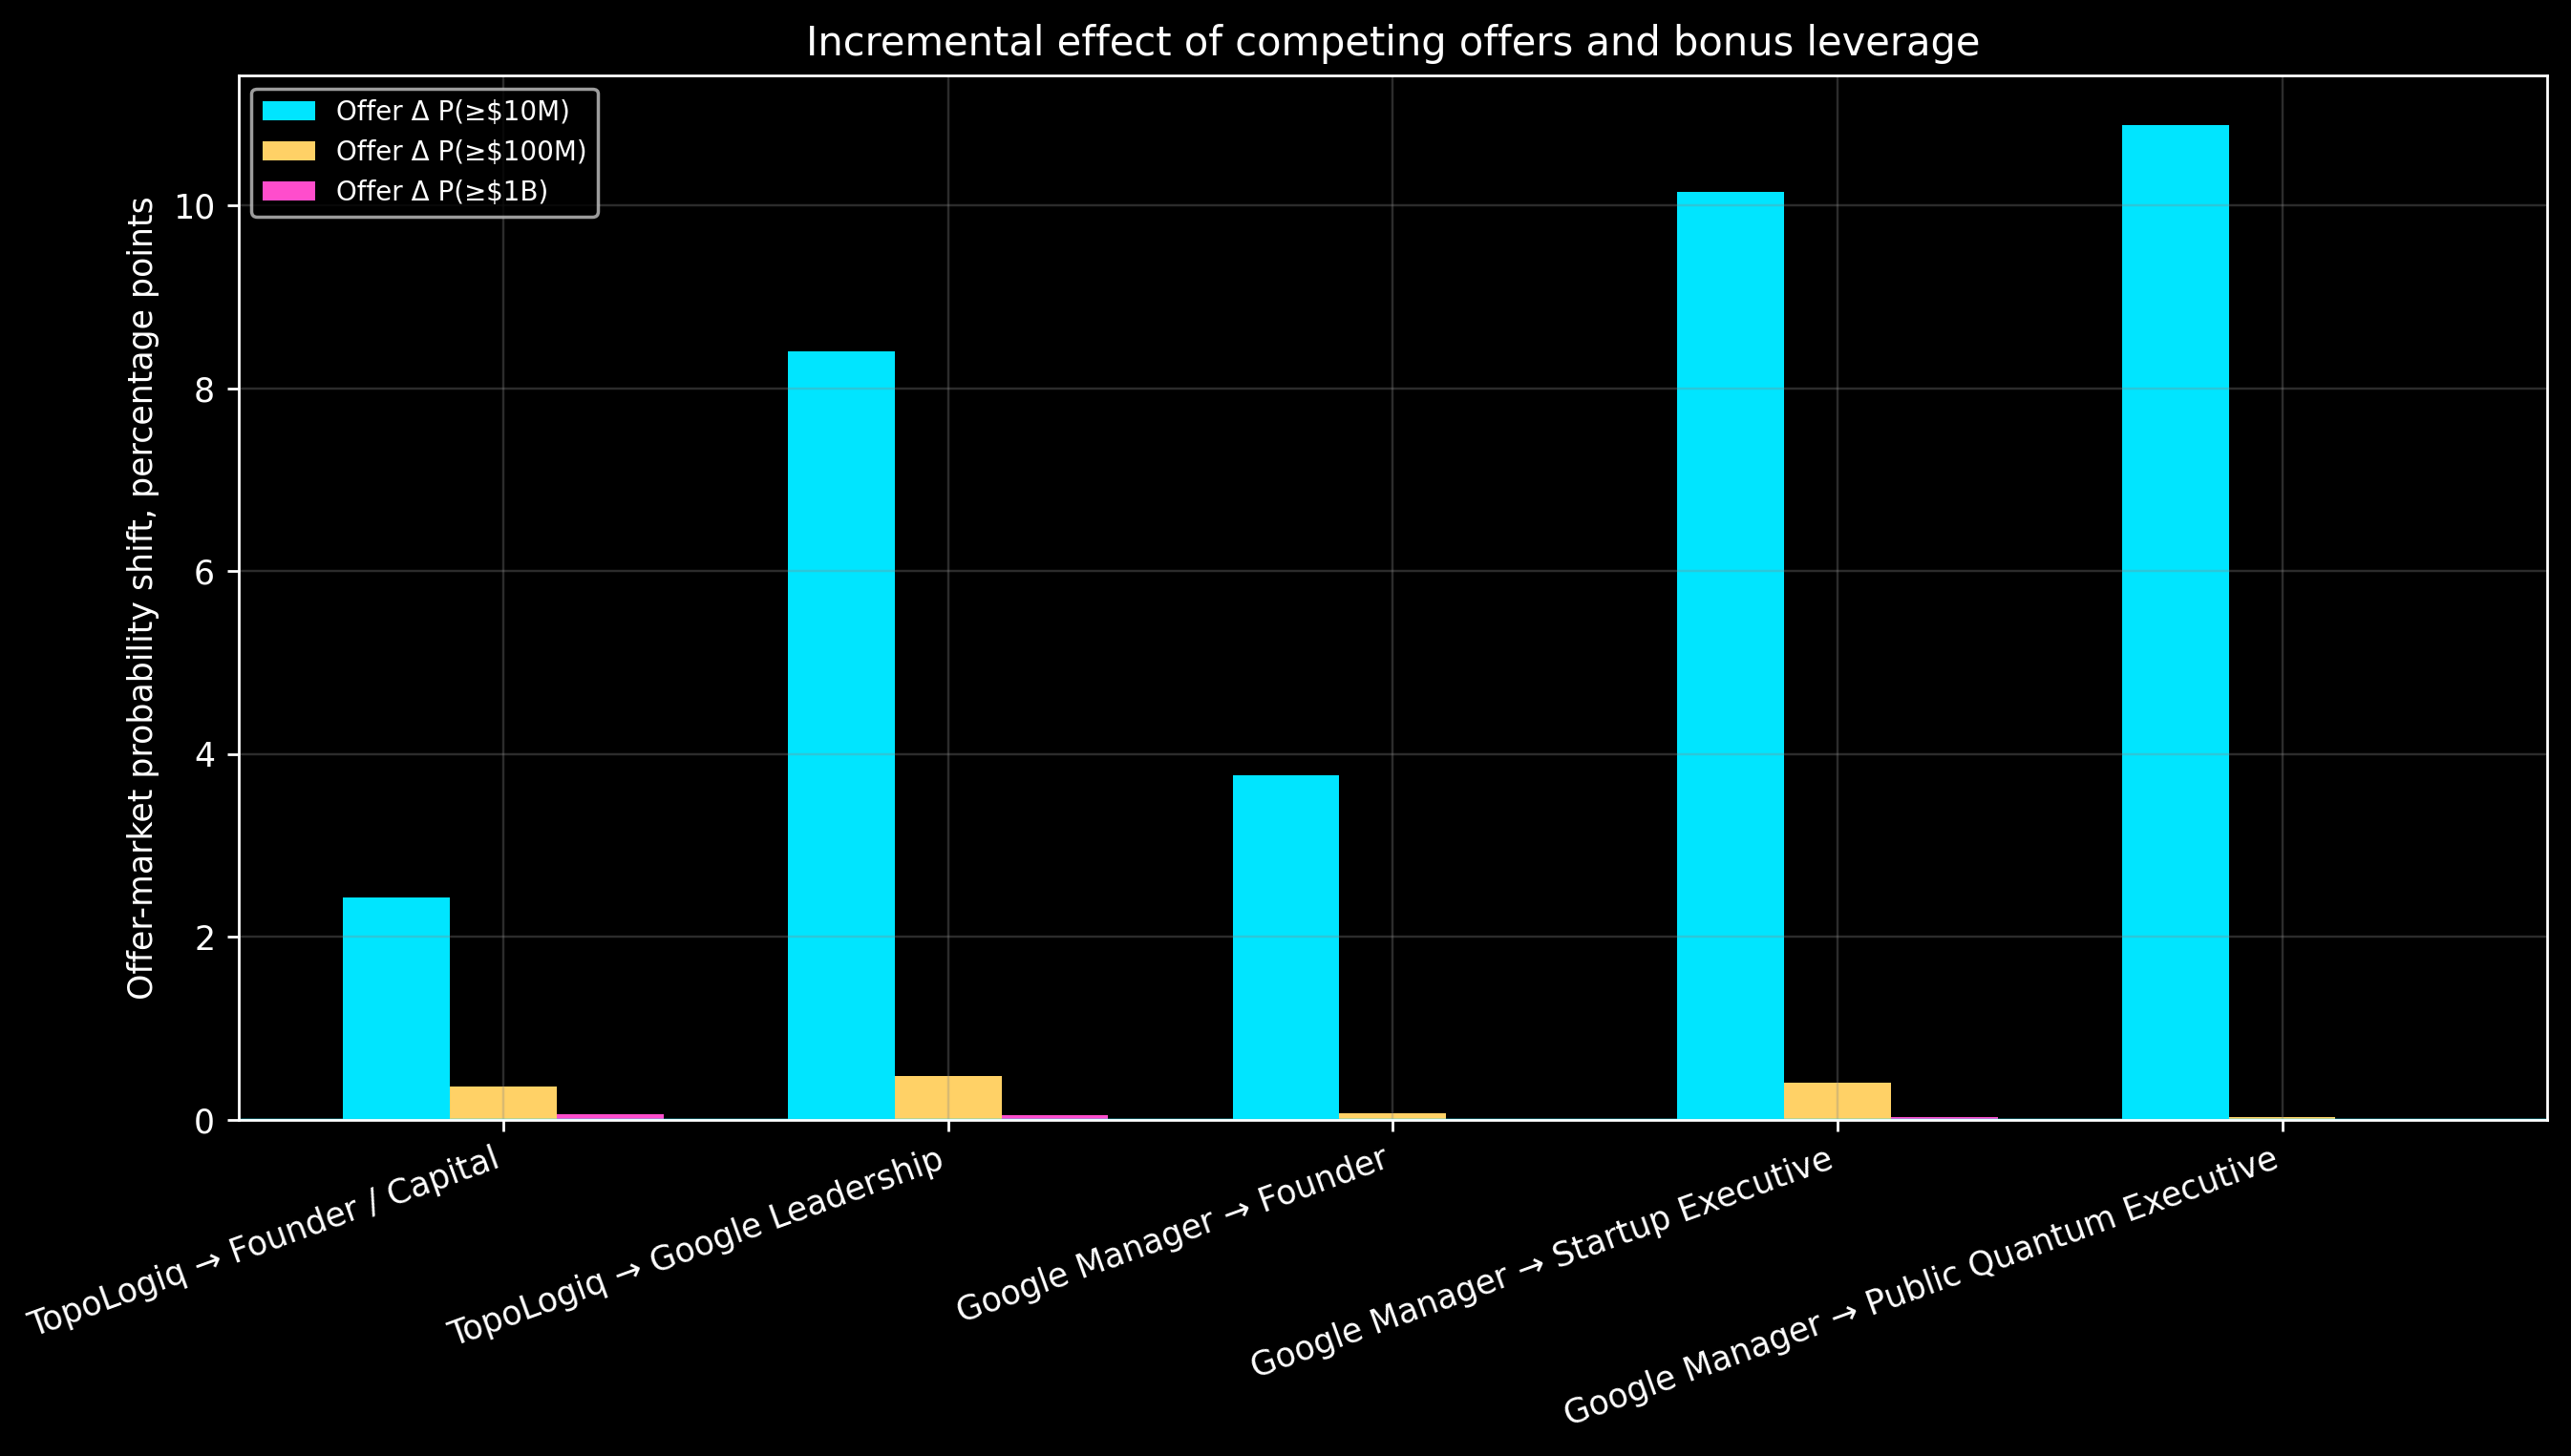

TopoLogiq → Founder / Capital: 100,000,000 trajectories in 1.20 s; $1B hits=2,837,104; P=0.028371
TopoLogiq → Google Leadership: 100,000,000 trajectories in 1.04 s; $1B hits=540,671; P=0.00540671
Google Manager → Founder: 100,000,000 trajectories in 0.96 s; $1B hits=2,423,221; P=0.0242322
Google Manager → Startup Executive: 100,000,000 trajectories in 1.07 s; $1B hits=266,093; P=0.00266093
Google Manager → Public Quantum Executive: 100,000,000 trajectories in 0.77 s; $1B hits=0; P=0
  Tail diagnostic: fewer than 1,000 billionaire trajectories were observed. Interpret the extreme-tail estimate with its interval.

Ranked path summary
                                     Path  N simulated  Billion hits        Tail status  P(≥$10M by year 4)  P(≥$10M by horizon)  P(≥$100M by horizon)  P(≥$1B by year 10)  P(≥$1B by horizon)    P(≥$1B) 95% Wilson interval  Median first $10M year  Median first $1B year Median final wealth 95th percentile 99th percentile
            TopoLogiq → Founder / Capit

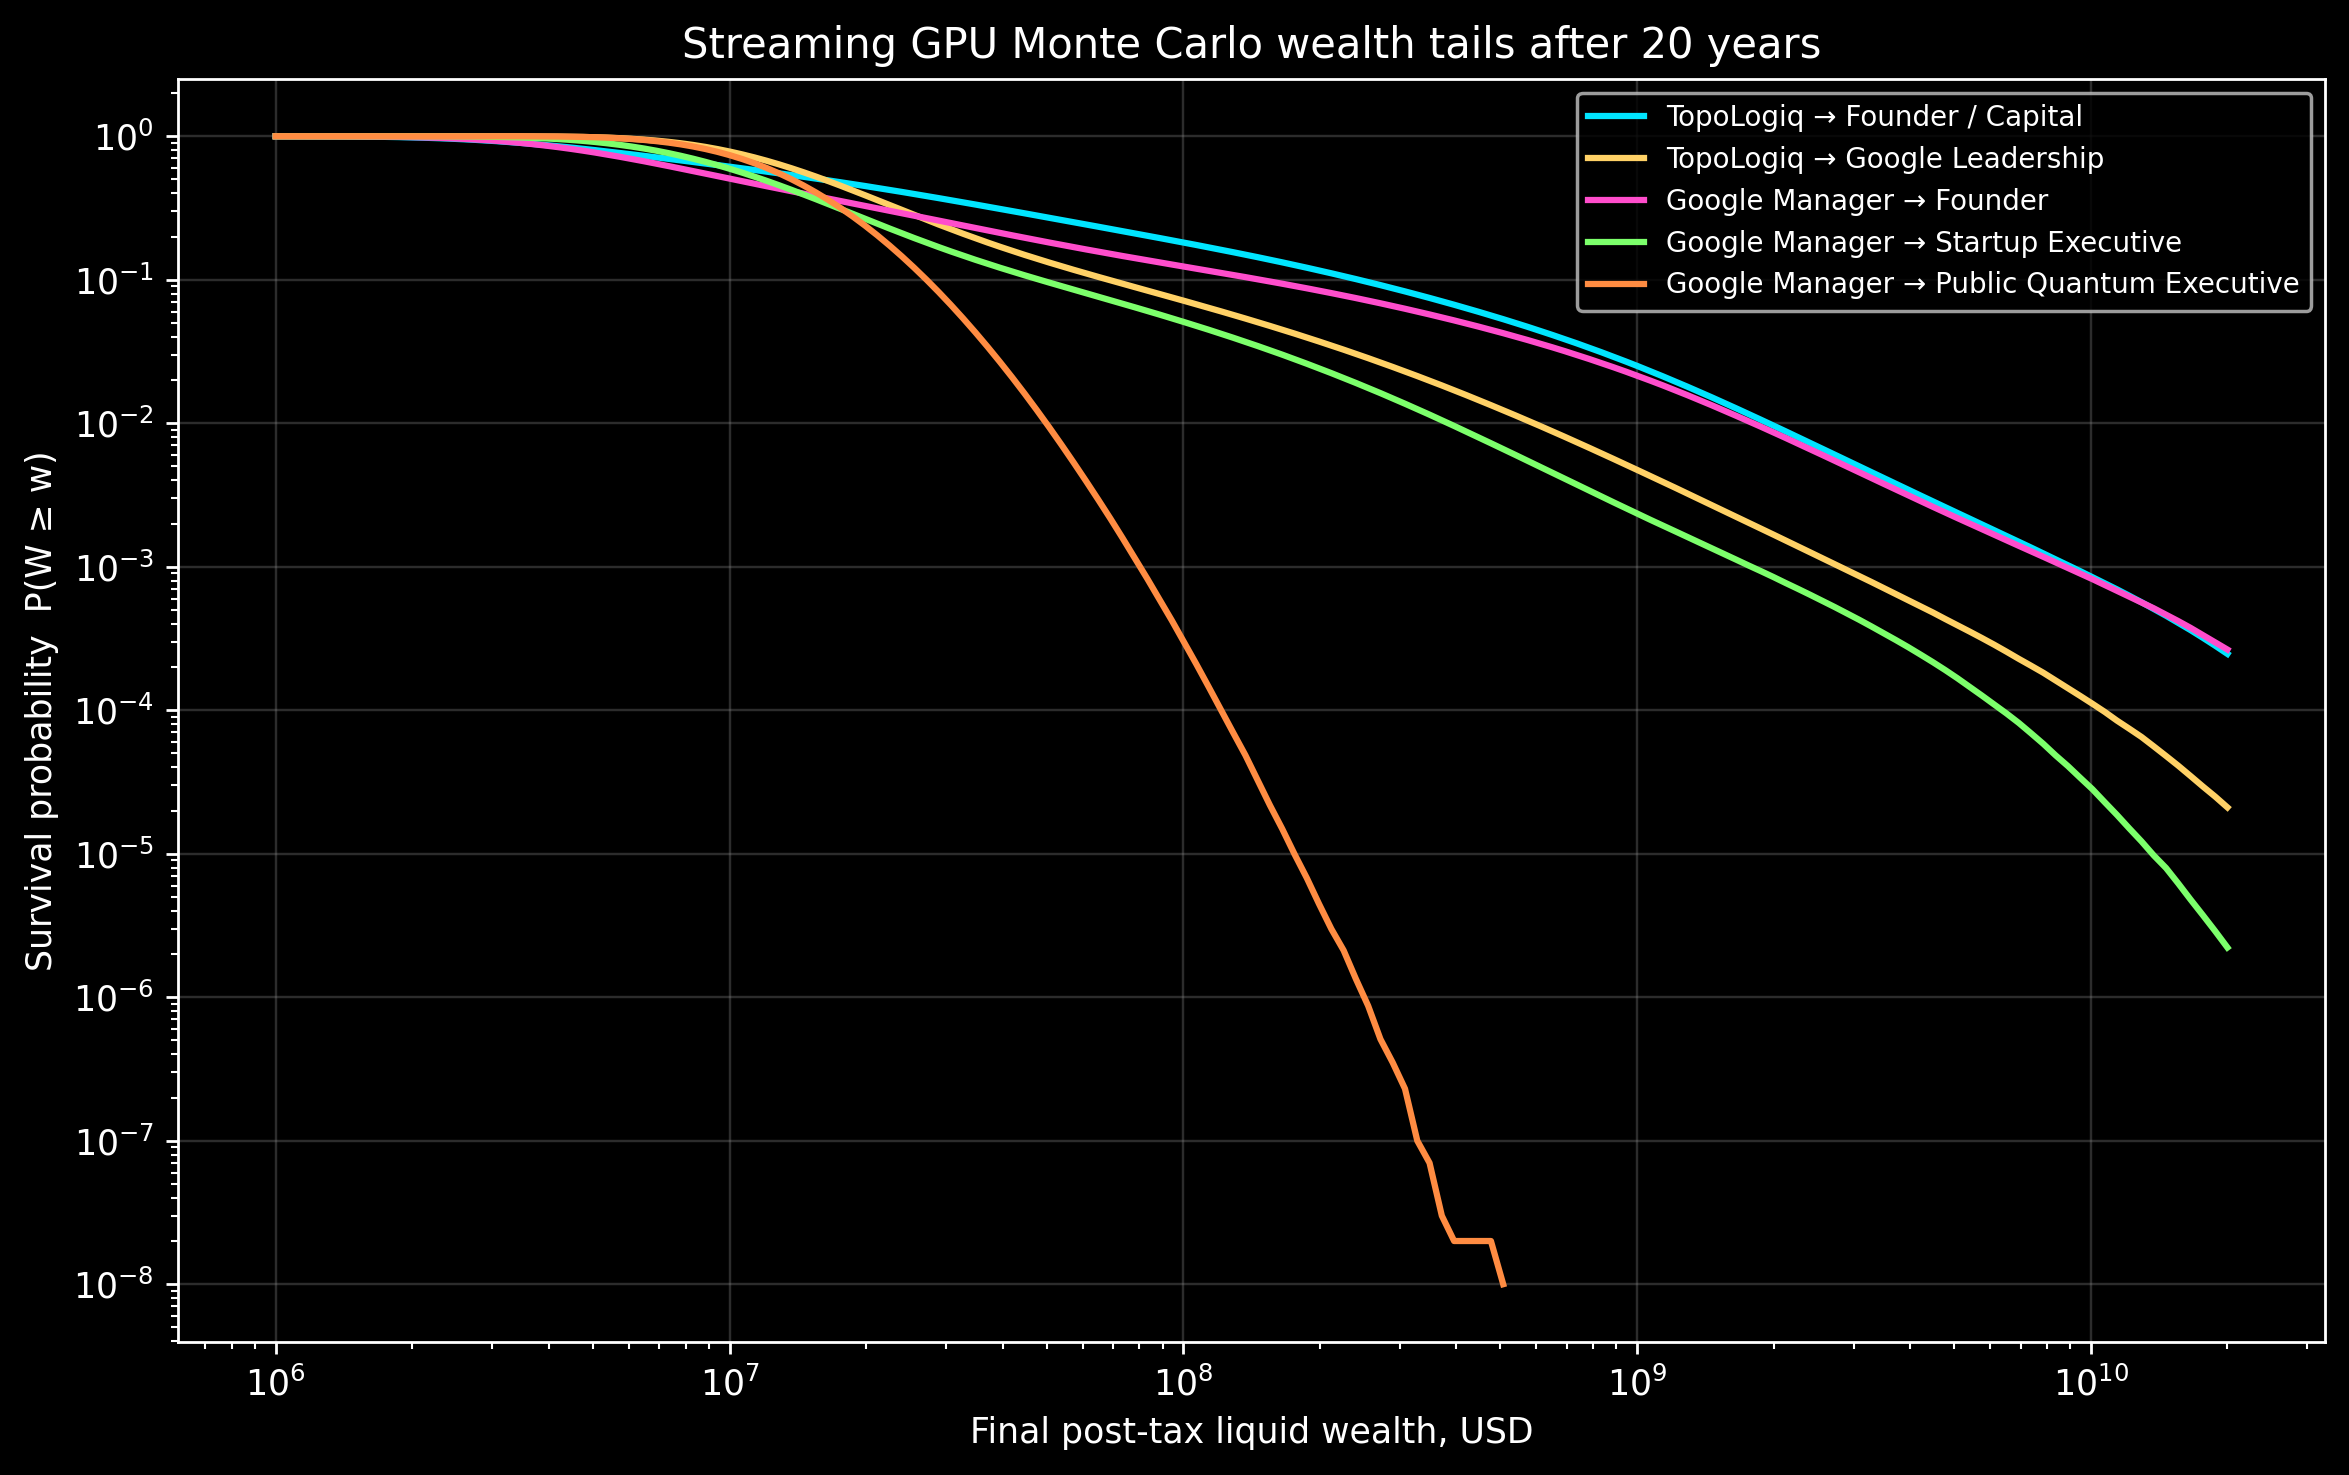

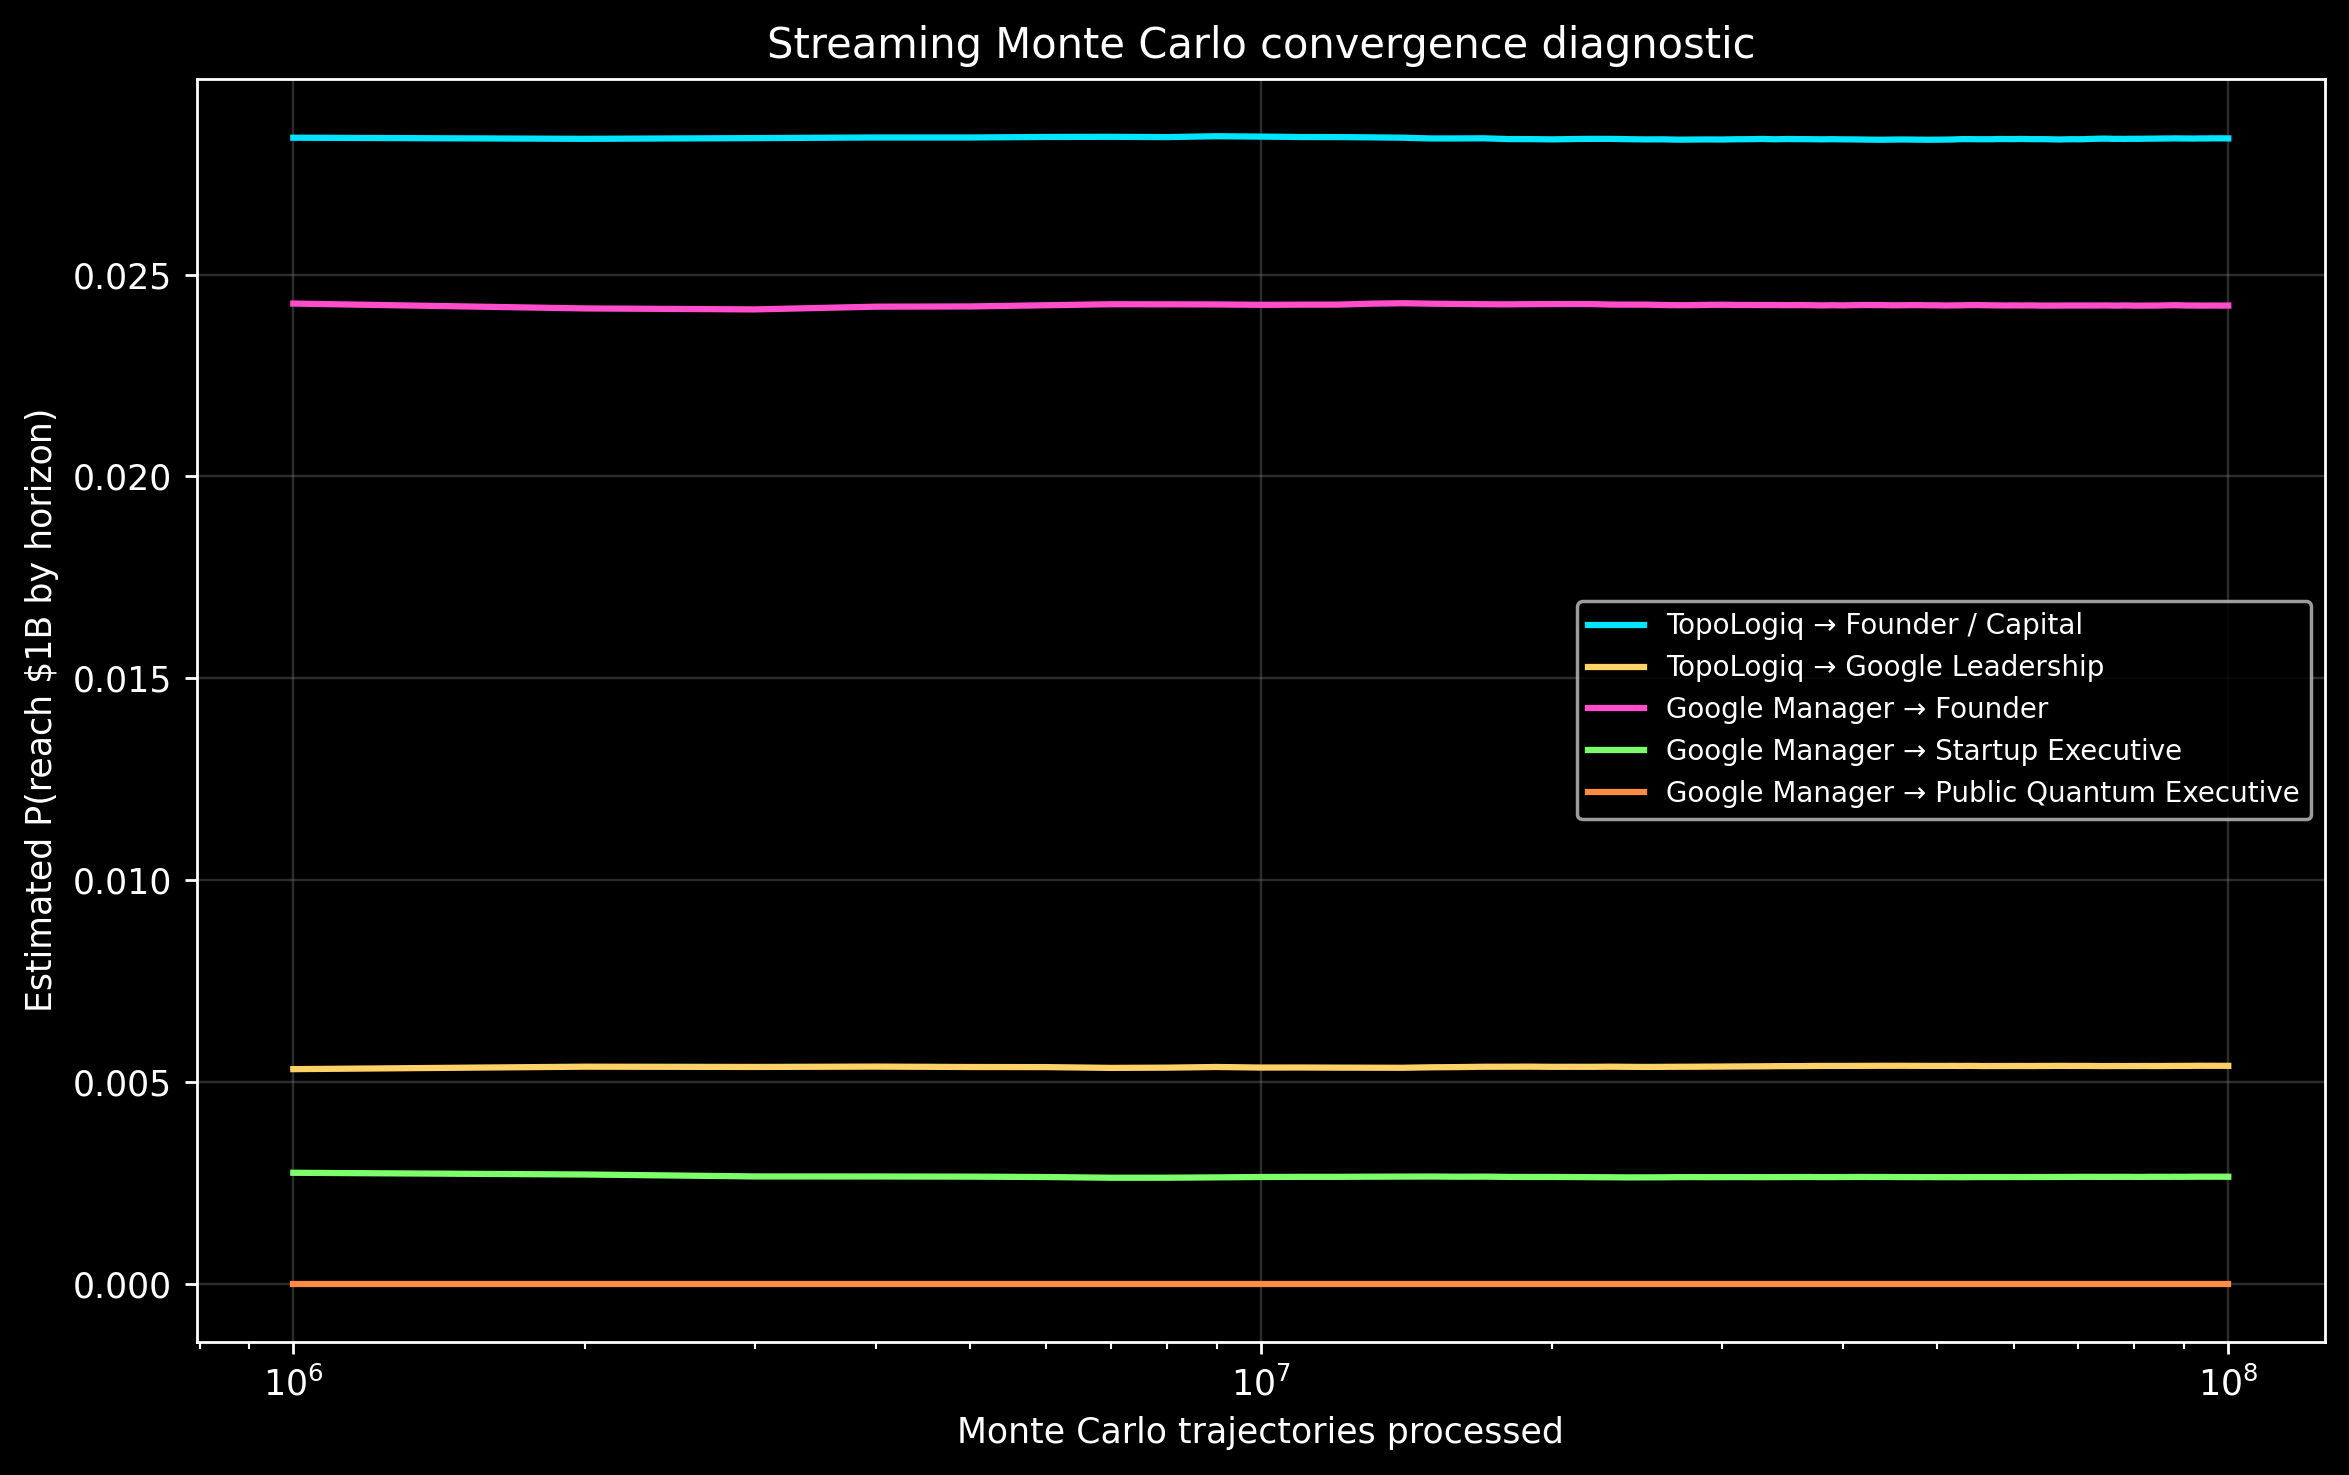

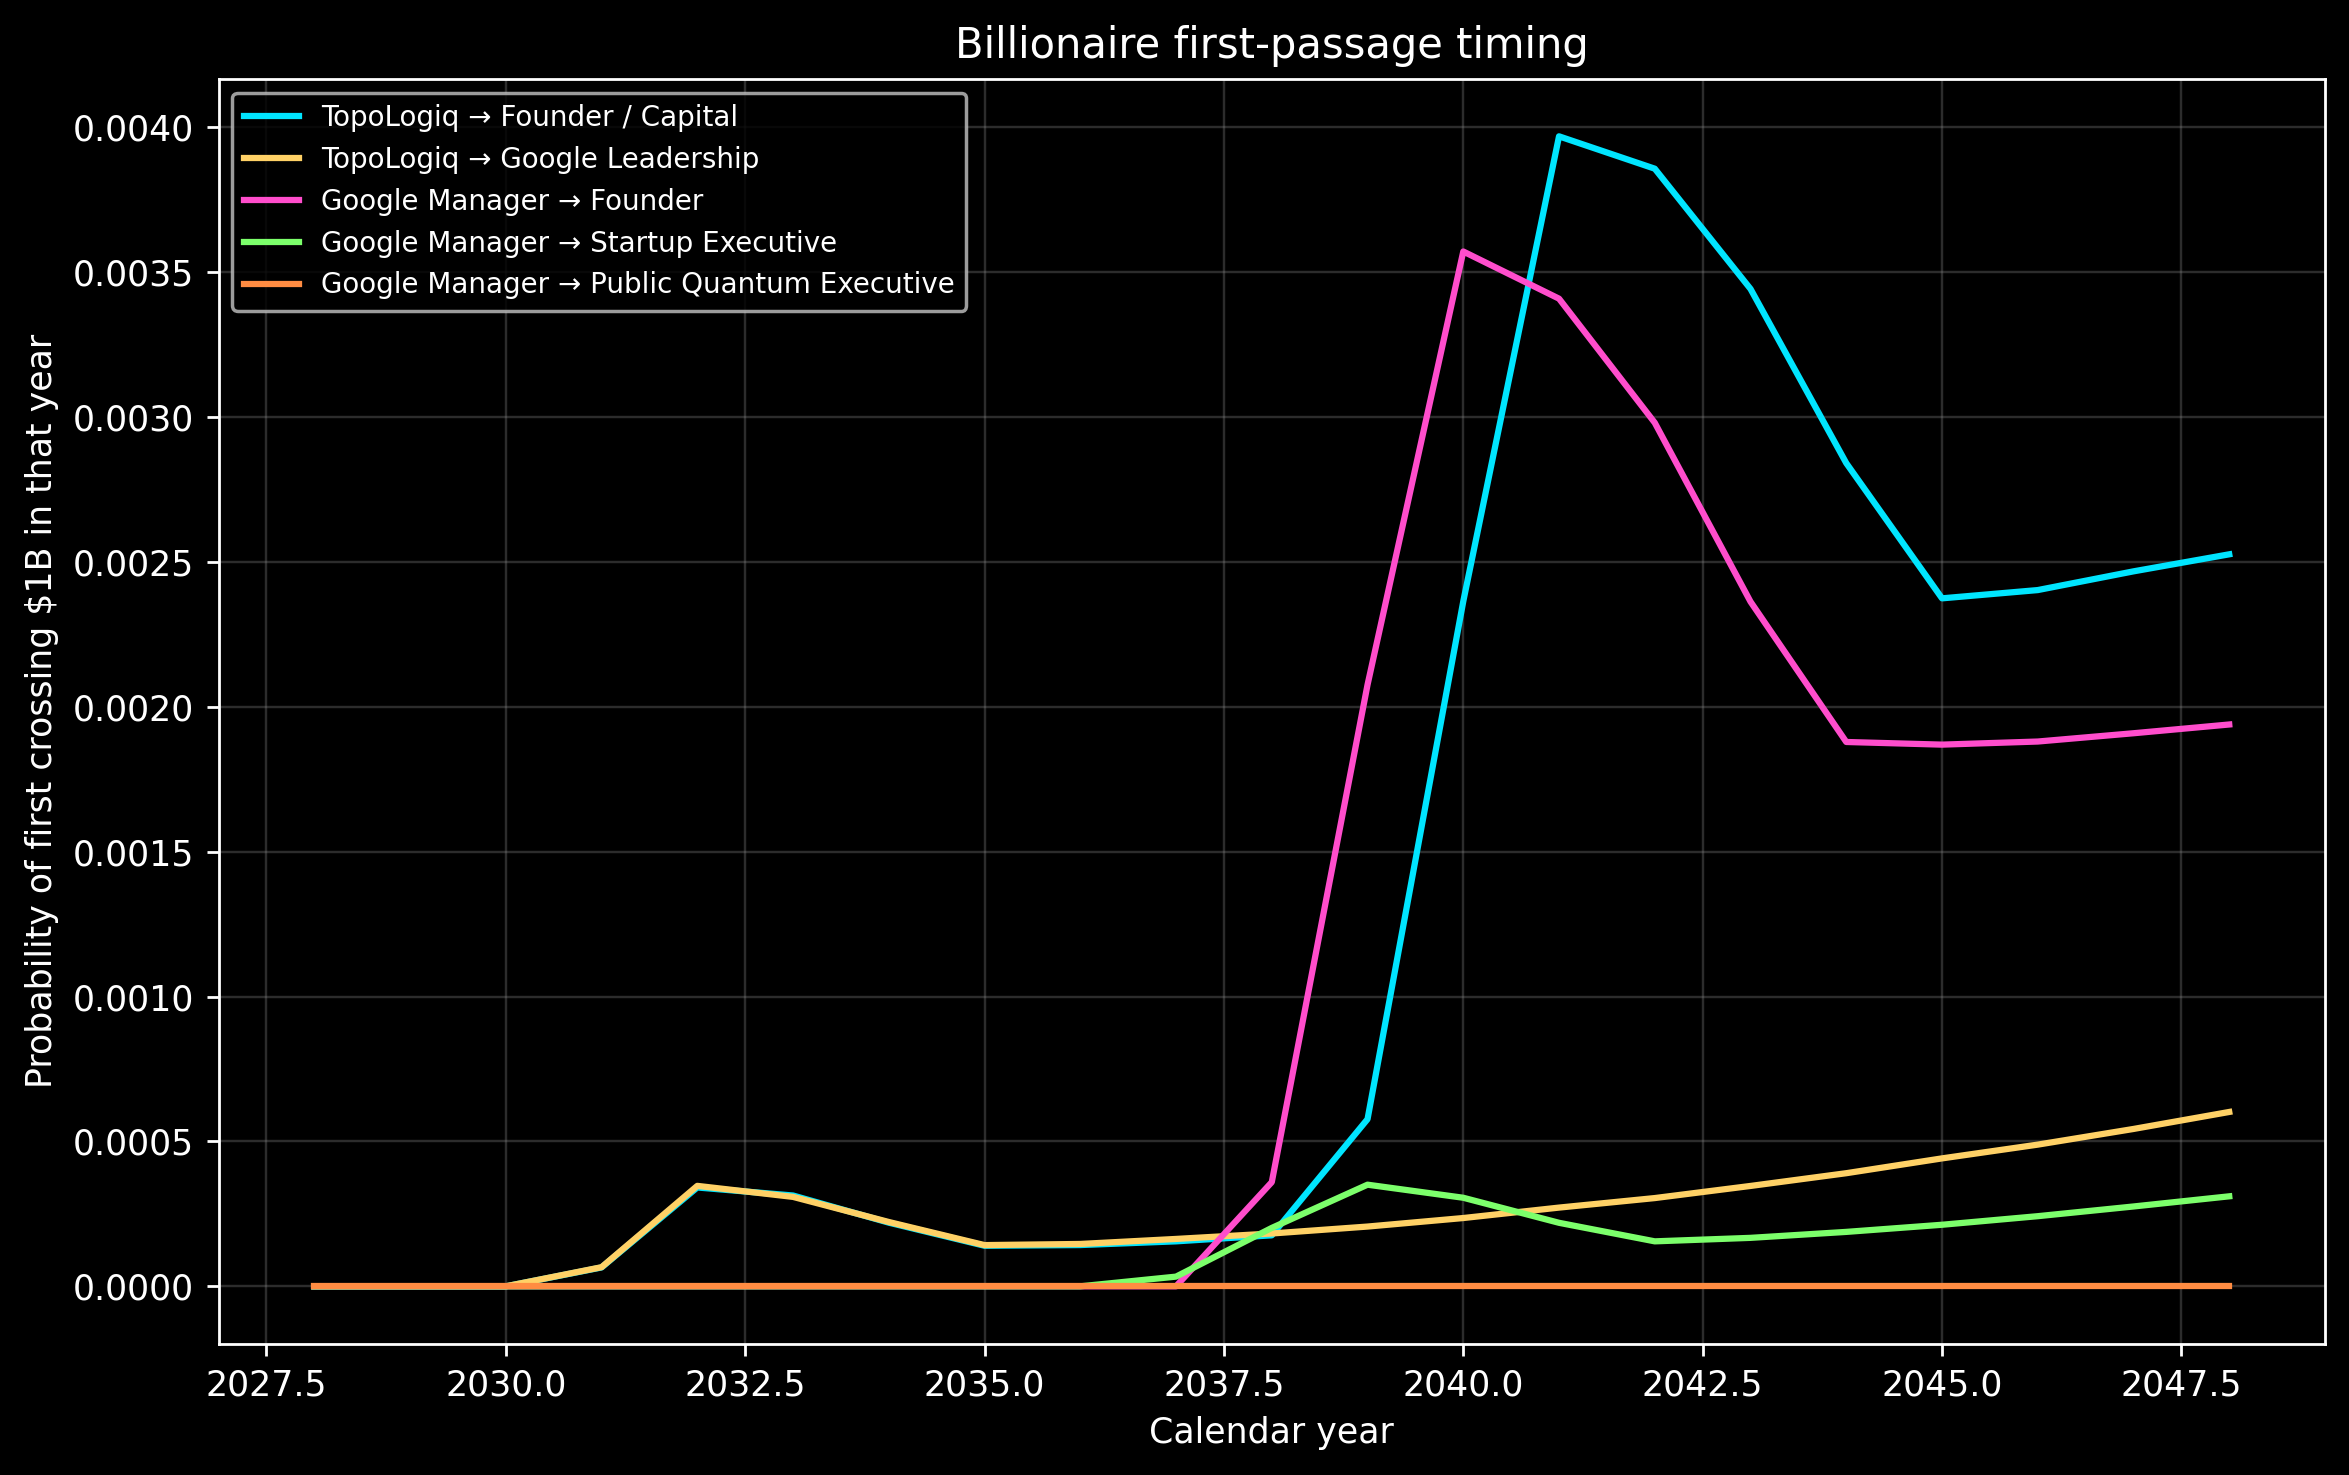

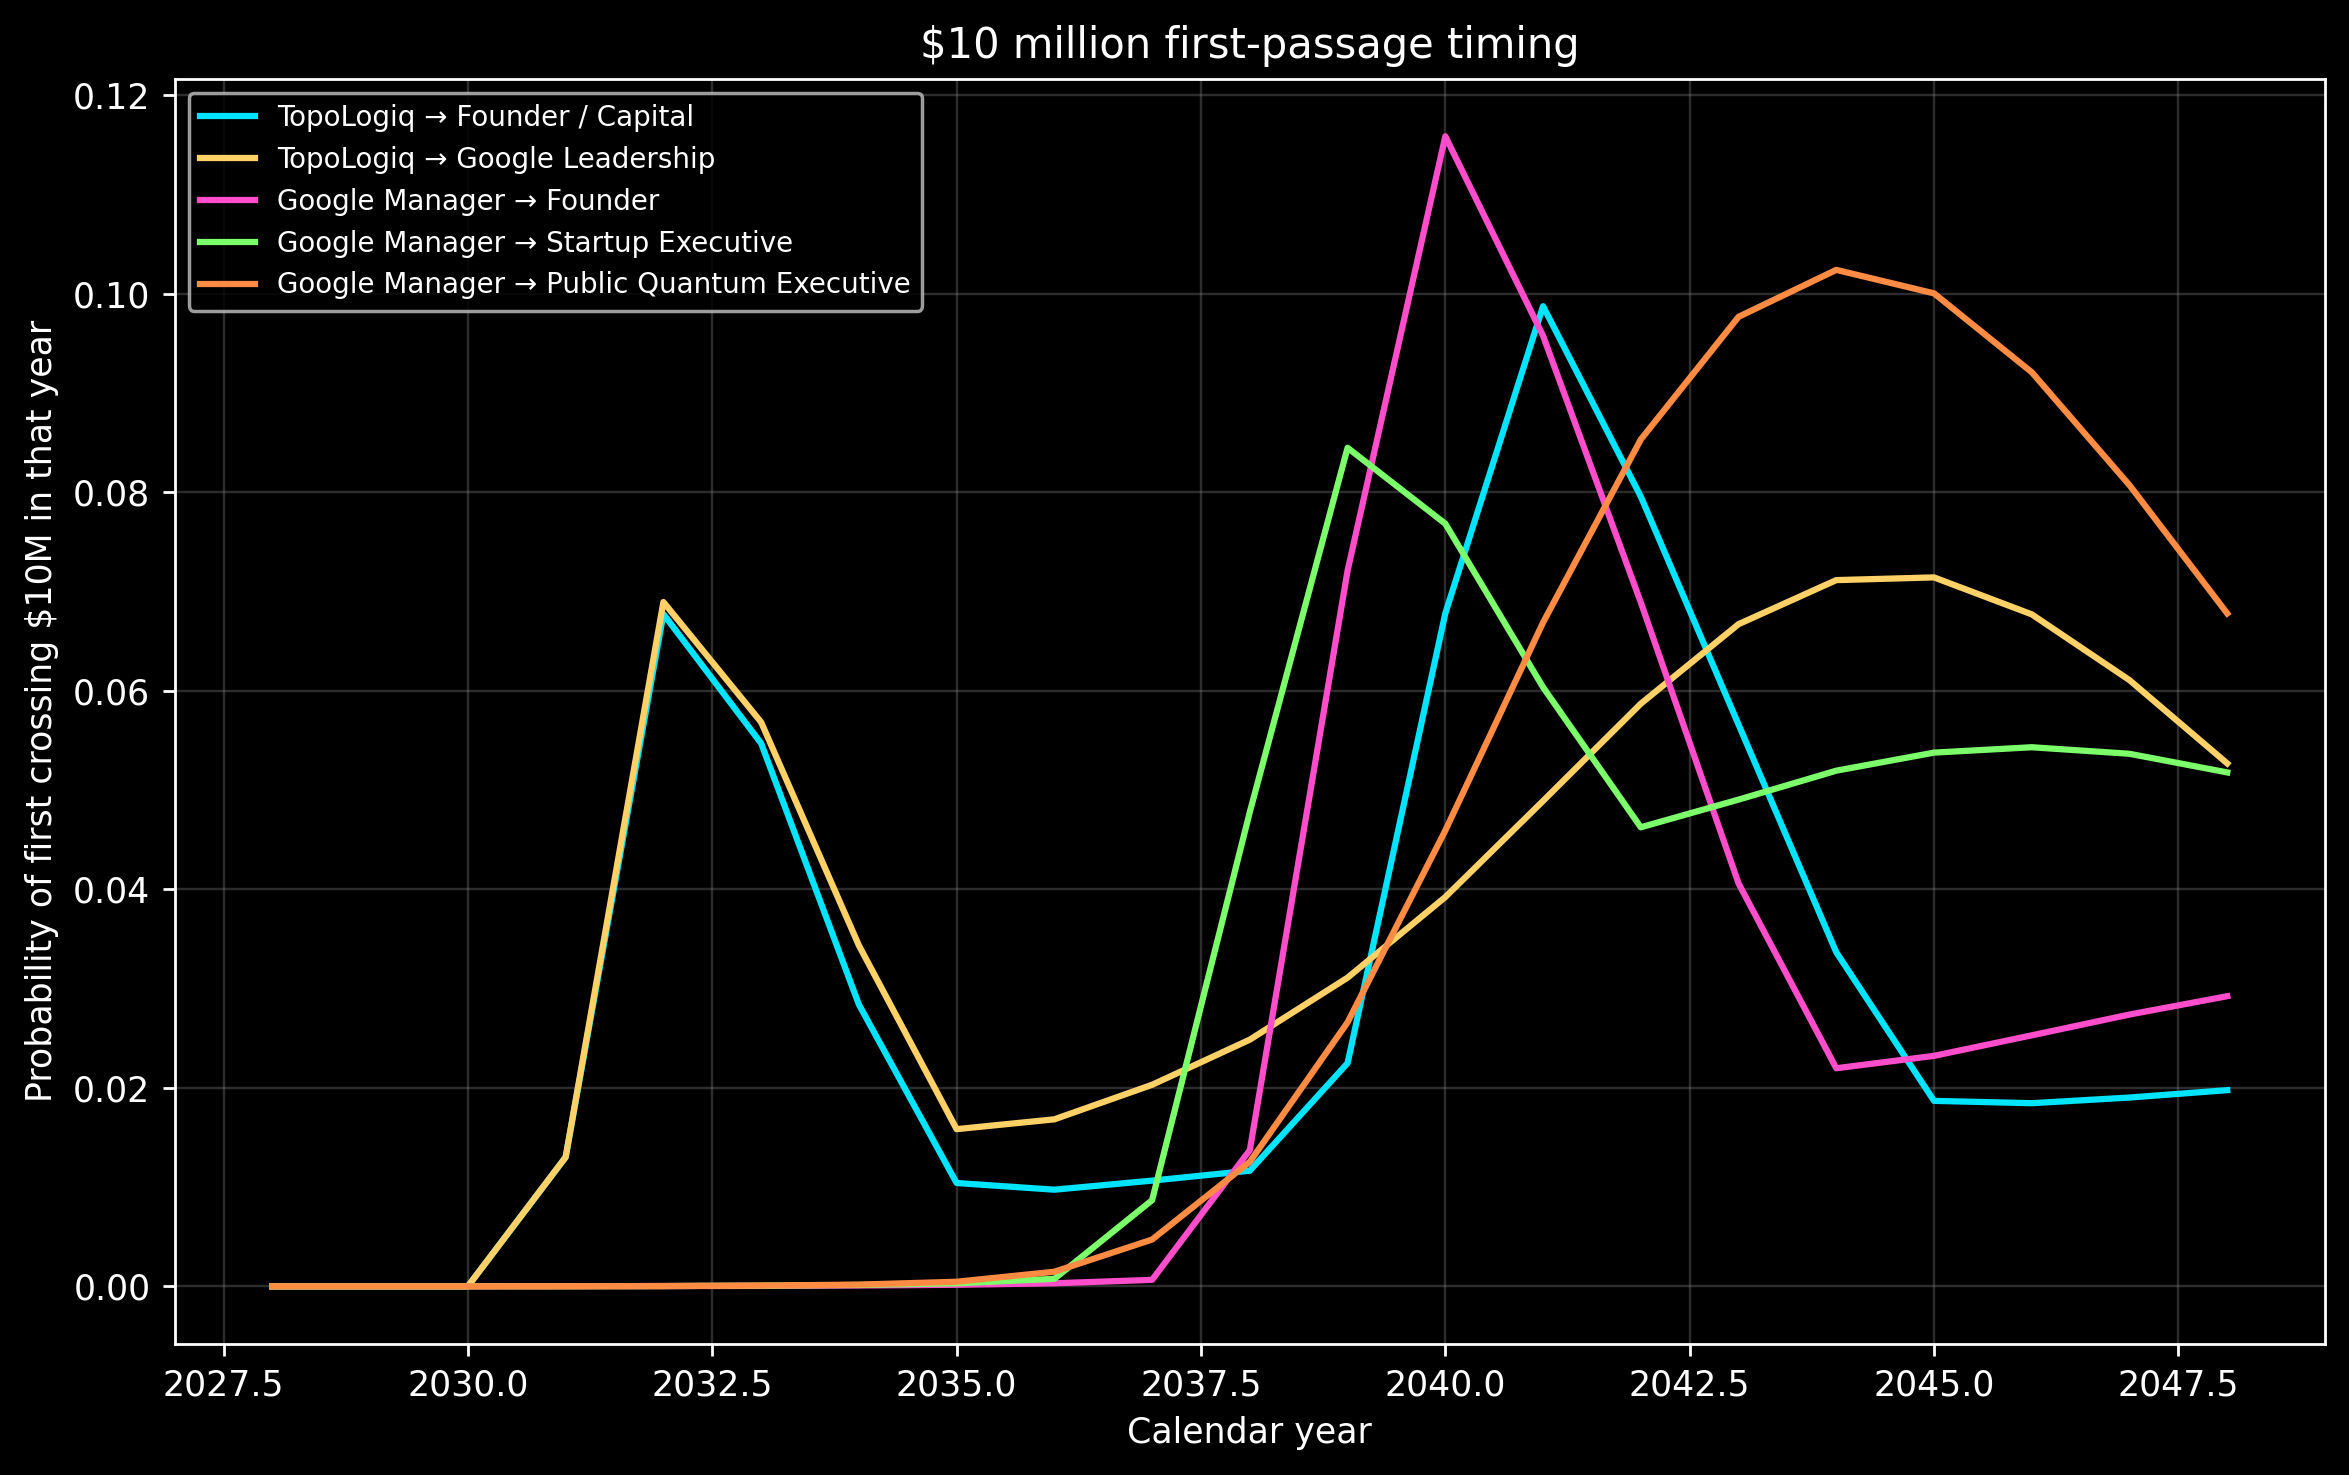

Sensitivity cells: 8/144 (8 cells processed concurrently)
Sensitivity cells: 16/144 (8 cells processed concurrently)
Sensitivity cells: 24/144 (8 cells processed concurrently)
Sensitivity cells: 32/144 (8 cells processed concurrently)
Sensitivity cells: 40/144 (8 cells processed concurrently)
Sensitivity cells: 48/144 (8 cells processed concurrently)
Sensitivity cells: 56/144 (8 cells processed concurrently)
Sensitivity cells: 64/144 (8 cells processed concurrently)
Sensitivity cells: 72/144 (8 cells processed concurrently)
Sensitivity cells: 80/144 (8 cells processed concurrently)
Sensitivity cells: 88/144 (8 cells processed concurrently)
Sensitivity cells: 96/144 (8 cells processed concurrently)
Sensitivity cells: 104/144 (8 cells processed concurrently)
Sensitivity cells: 112/144 (8 cells processed concurrently)
Sensitivity cells: 120/144 (8 cells processed concurrently)
Sensitivity cells: 128/144 (8 cells processed concurrently)
Sensitivity cells: 136/144 (8 cells processed concurr

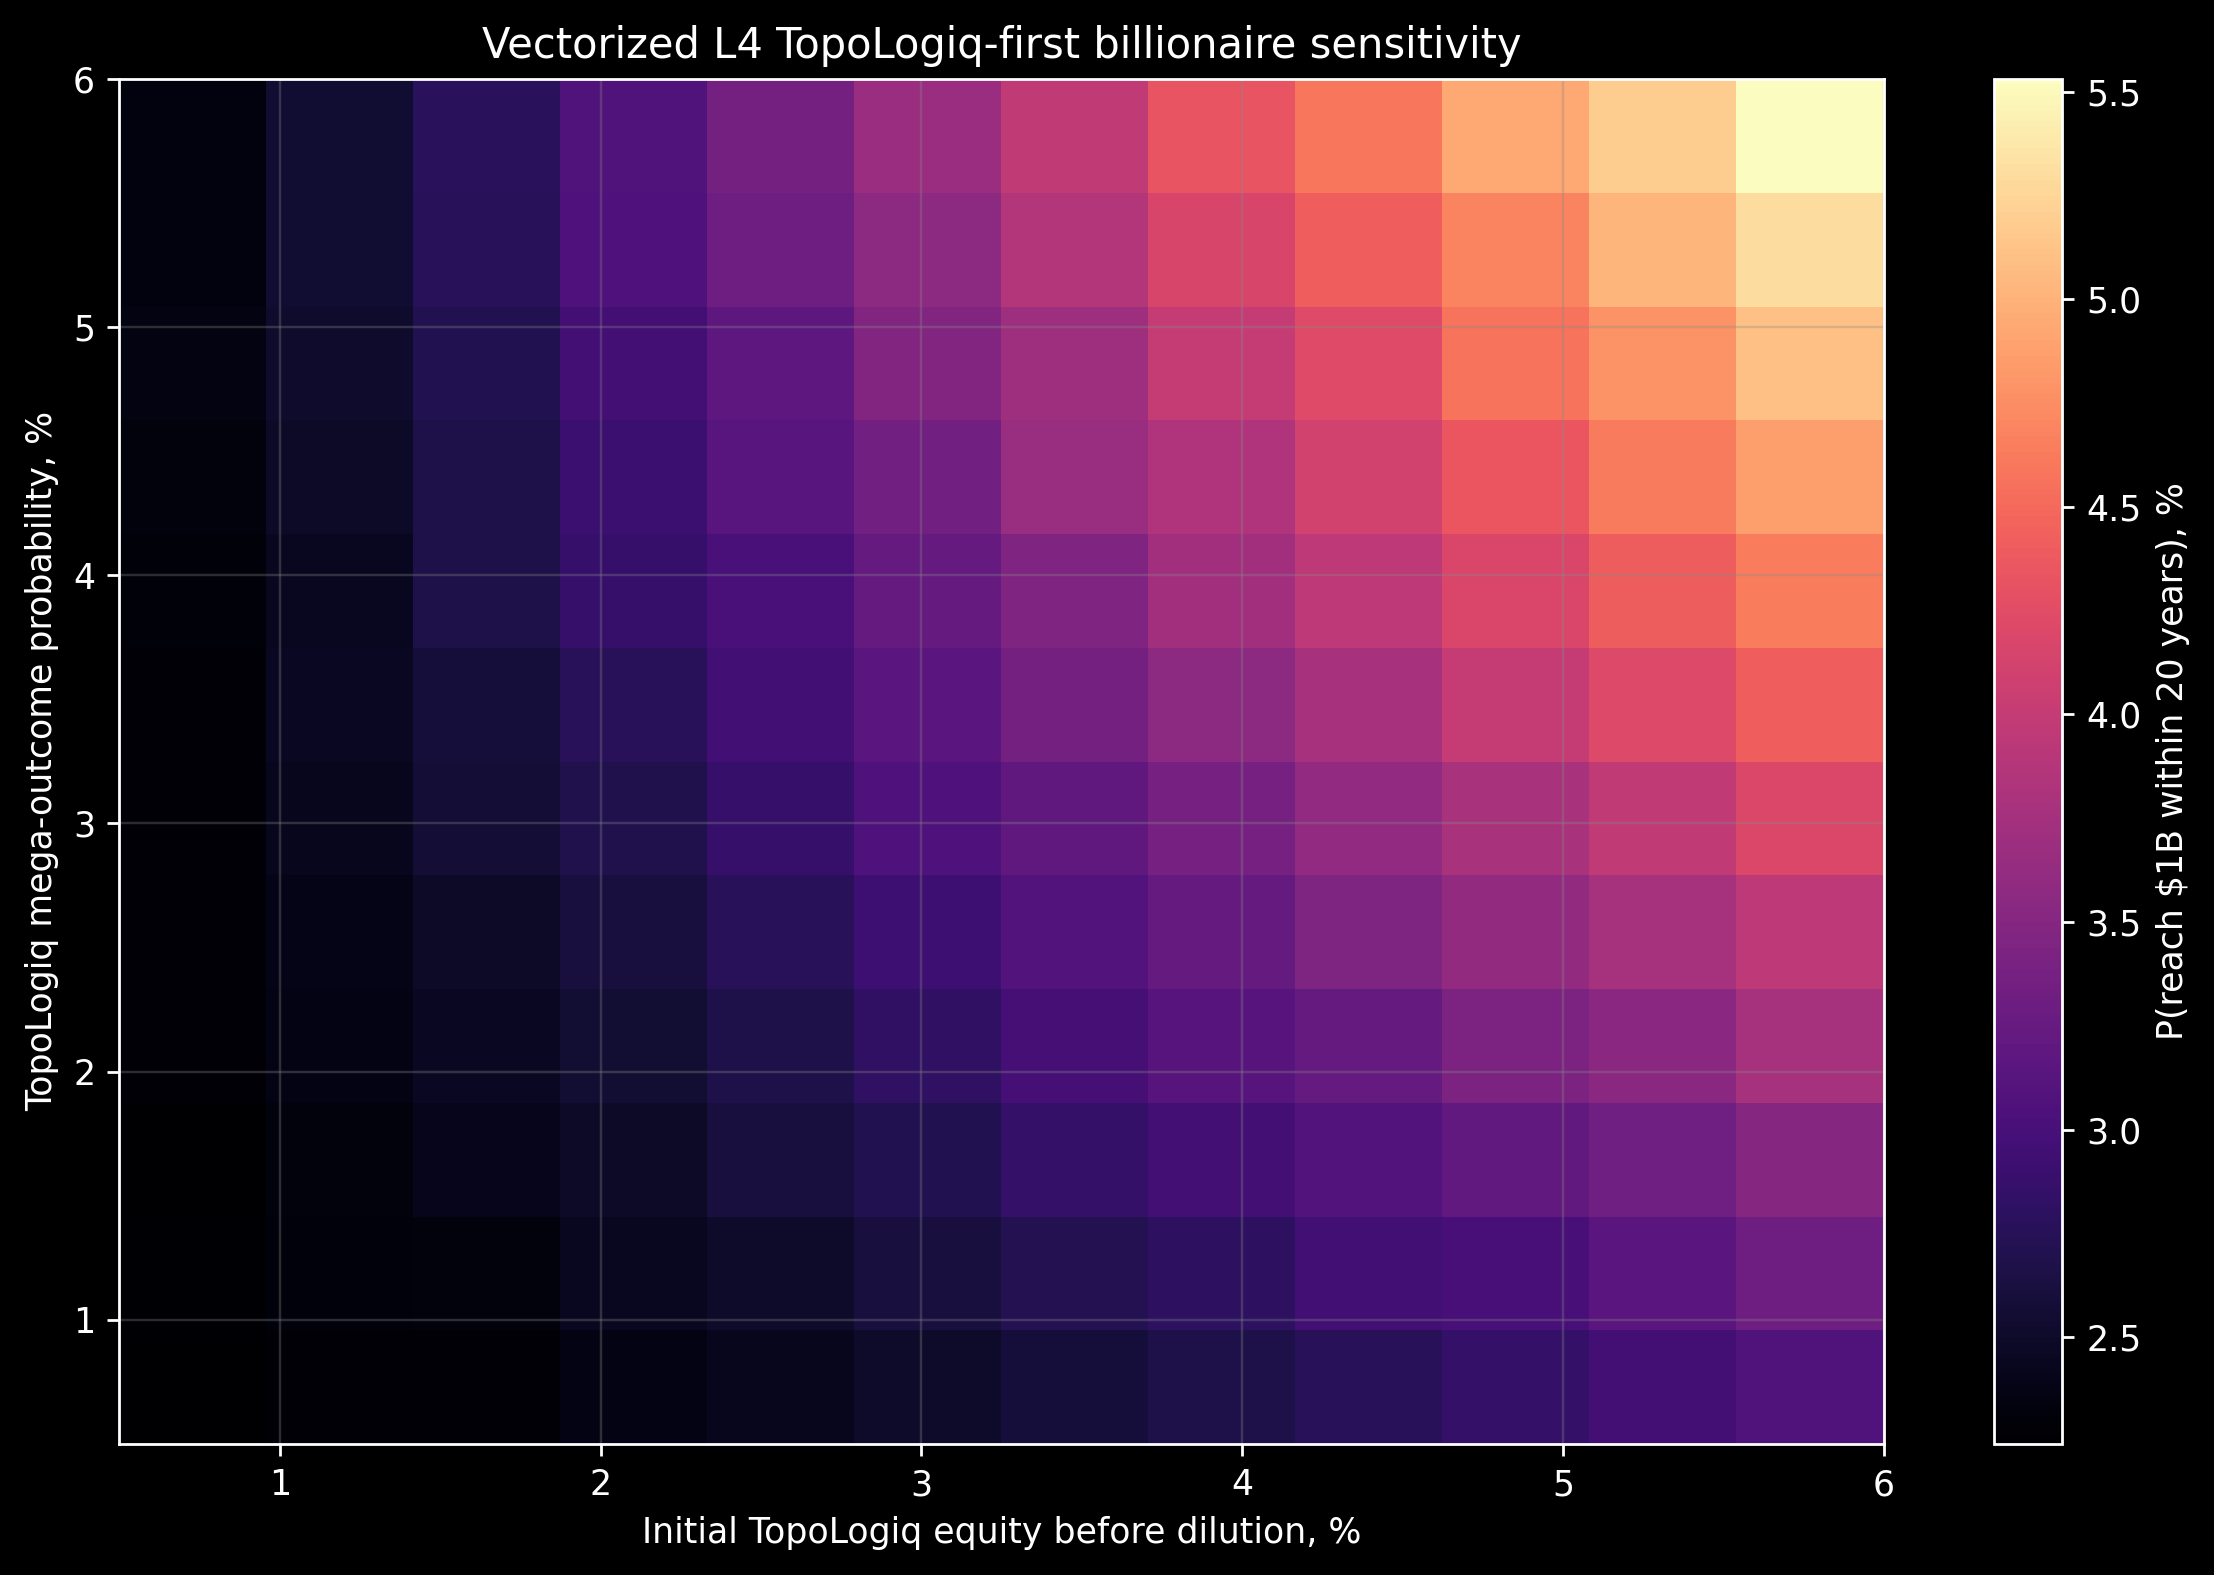


Career-capital and competitive-offer effects are bounded scenario priors. Replace bonus, compensation, equity, financing, and exit inputs with written offers and comparable transaction data as they become available.
Sparse matrices are omitted. Independent Monte Carlo trajectories map directly onto dense elementwise GPU execution, so sparse adjacency machinery would add overhead without improving this model.


In [ ]:
"""Run an L4-optimized GPU Monte Carlo career-to-wealth analysis.

The solver compares several career sequences with vectorized CuPy kernels,
streaming statistical reductions, heavy-tailed private-company outcomes, and
an optional GPU Metropolis-Hastings calibration stage. The implementation
adapts its trajectory count, memory budget, batch size, and sensitivity sweep
to an NVIDIA L4 when that device is detected in Google Colab.

Company-specific values are scenario priors. Replace them with actual offer
terms, cap-table information, financing expectations, comparable exits, and
other decision-relevant data as those values become available.

An optional career-capital model can incorporate observable professional
signals such as research credentials, prior industry experience, sustained
open-source activity, ecosystem integration, and repository traction.
These modifiers are transparent scenario assumptions rather than an empirical
causal model. Protected personal identity attributes have zero numerical weight.

A separate competitive-offer prior represents reported multi-company recruiting
pressure. It can modify negotiated cash compensation and employer equity terms,
and it can generate stochastic signing or retention bonuses with a bounded
million-dollar tail. Reported "blank check" interest is treated as bargaining
leverage rather than as an unbounded cash amount.
"""

import math
import time
from dataclasses import dataclass, field, replace
from typing import Final

import cupy as cp
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# -----------------------------------------------------------------------------
# Control knobs - simulation scale and L4 adaptation
# -----------------------------------------------------------------------------

RANDOM_SEED: Final[int] = 73

START_YEAR: Final[int] = 2028
HORIZON_YEARS: Final[int] = 20

"""Set to an integer to force a trajectory count.

Using None activates hardware-aware defaults. The L4 default is intentionally
larger than the generic-GPU default because the streaming reducer avoids
storing every trajectory for the complete path simulation.
"""
N_SIMULATIONS: Final[int | None] = None

"""Use an aggressive streaming sample budget on NVIDIA L4 hardware.

One hundred million trajectories are evaluated for each career path. Complete
trajectory histories are never retained, so this setting increases statistical
power without requiring all samples to fit in VRAM at the same time.
"""
L4_N_SIMULATIONS: Final[int] = 100_000_000
GENERIC_N_SIMULATIONS: Final[int] = 2_000_000

AUTO_TUNE_BATCH: Final[bool] = True
BENCHMARK_BATCH_AUTOTUNE: Final[bool] = True
PREFER_MAX_THROUGHPUT_BATCH: Final[bool] = True

"""Set to an integer to cap the batch size manually.

Using None enables the hardware-aware ceiling. The L4 profile permits batches
up to sixteen million trajectories, then benchmarks several resident batch
sizes and selects the measured throughput winner. Adaptive OOM recovery still
reduces the batch if the active Colab session has less usable VRAM.
"""
MAX_BATCH_SIZE: Final[int | None] = None
L4_MAX_BATCH_SIZE: Final[int] = 16_000_000
GENERIC_MAX_BATCH_SIZE: Final[int] = 1_000_000
MIN_BATCH_SIZE: Final[int] = 25_000

"""Set to a float in (0, 1) to force a GPU-memory target fraction."""
GPU_MEMORY_FRACTION: Final[float | None] = None
L4_GPU_MEMORY_FRACTION: Final[float] = 0.88
GENERIC_GPU_MEMORY_FRACTION: Final[float] = 0.35

ESTIMATED_BYTES_PER_SAMPLE: Final[int] = 288
OOM_BATCH_REDUCTION_FACTOR: Final[float] = 0.50

L4_BATCH_BENCHMARK_CANDIDATES: Final[tuple[int, ...]] = (
    500_000,
    1_000_000,
    2_000_000,
    4_000_000,
    6_000_000,
    8_000_000,
    12_000_000,
    16_000_000,
)
GENERIC_BATCH_BENCHMARK_CANDIDATES: Final[tuple[int, ...]] = (
    100_000,
    250_000,
    500_000,
    1_000_000,
)
BATCH_BENCHMARK_REPEATS: Final[int] = 5
BATCH_THROUGHPUT_FRACTION_OF_BEST: Final[float] = 0.995

SIM_DTYPE = cp.float32
SUMMARY_DTYPE = cp.float64

INITIAL_LIQUID_WEALTH_USD: Final[float] = 0.0

TEN_MILLION_USD: Final[float] = 10_000_000.0
RETIREMENT_TARGET_USD: Final[float] = TEN_MILLION_USD
RETIREMENT_TEST_YEAR: Final[int] = 4

HUNDRED_MILLION_USD: Final[float] = 100_000_000.0
BILLIONAIRE_TARGET_USD: Final[float] = 1_000_000_000.0

TAIL_HIT_DIAGNOSTIC_TARGET: Final[int] = 1_000


# -----------------------------------------------------------------------------
# Control knobs - streaming distributions and plots
# -----------------------------------------------------------------------------

WEALTH_SURVIVAL_GRID_USD = np.geomspace(
    1.0e6,
    2.0e10,
    160,
).astype(np.float64)

WEALTH_HISTOGRAM_MIN_USD: Final[float] = 1.0
WEALTH_HISTOGRAM_MAX_USD: Final[float] = 1.0e14
WEALTH_HISTOGRAM_LOG_POINTS: Final[int] = 8_192

_WEALTH_HISTOGRAM_BASE = np.geomspace(
    WEALTH_HISTOGRAM_MIN_USD,
    WEALTH_HISTOGRAM_MAX_USD,
    WEALTH_HISTOGRAM_LOG_POINTS,
).astype(np.float64)

WEALTH_HISTOGRAM_THRESHOLDS_USD = np.unique(
    np.concatenate(
        [
            _WEALTH_HISTOGRAM_BASE,
            WEALTH_SURVIVAL_GRID_USD,
            np.asarray(
                [
                    RETIREMENT_TARGET_USD,
                    HUNDRED_MILLION_USD,
                    BILLIONAIRE_TARGET_USD,
                ],
                dtype=np.float64,
            ),
        ]
    )
)


# -----------------------------------------------------------------------------
# Control knobs - diversified liquid portfolio
# -----------------------------------------------------------------------------

PUBLIC_MARKET_EXPECTED_RETURN: Final[float] = 0.075
PUBLIC_MARKET_VOLATILITY: Final[float] = 0.18


# -----------------------------------------------------------------------------
# Control knobs - observable career capital
# -----------------------------------------------------------------------------

USE_CAREER_CAPITAL_MODEL: Final[bool] = True

"""Shrink the career-capital model toward the original model.

Zero reproduces the original career and venture priors. One applies the full
bounded career-capital effect. The default retains substantial shrinkage because
GitHub activity and professional credentials are informative career signals,
yet they do not constitute a calibrated causal model of private-company exits.
"""
CAREER_CAPITAL_MODEL_STRENGTH: Final[float] = 0.35

"""Observable professional and open-source inputs from the supplied summary."""
CAREER_TOTAL_STARS: Final[int] = 699
CAREER_REPOSITORY_COUNT: Final[int] = 64
CAREER_PINNED_STARS: Final[int] = 271
CAREER_PINNED_FORKS: Final[int] = 45

CAREER_CONTRIBUTIONS_1Y: Final[int] = 2_128
CAREER_CONTRIBUTIONS_4Y: Final[int] = 7_841
CAREER_AUG_2026_COMMITS: Final[int] = 170
CAREER_AUG_2026_ACTIVE_REPOSITORIES: Final[int] = 9

CAREER_FORMER_IBM_QUANTUM_HARDWARE: Final[bool] = True
CAREER_NSF_GRFP: Final[bool] = True
CAREER_LEAD_DOCTORAL_RESEARCHER: Final[bool] = True
CAREER_QUANTUM_METAL_ECOSYSTEM_INTEGRATION: Final[bool] = True

"""Saturation scales prevent raw activity counts from growing without bound."""
CAREER_STAR_SCALE: Final[float] = 500.0
CAREER_PINNED_STAR_SCALE: Final[float] = 180.0
CAREER_FORK_SCALE: Final[float] = 35.0
CAREER_REPOSITORY_SCALE: Final[float] = 50.0

CAREER_CONTRIBUTION_1Y_SCALE: Final[float] = 1_800.0
CAREER_ANNUALIZED_4Y_CONTRIBUTION_SCALE: Final[float] = 1_800.0
CAREER_MONTHLY_COMMIT_SCALE: Final[float] = 150.0
CAREER_ACTIVE_REPOSITORY_SCALE: Final[float] = 8.0

CAREER_OPEN_SOURCE_WEIGHT: Final[float] = 0.40
CAREER_EXECUTION_WEIGHT: Final[float] = 0.25
CAREER_CREDENTIAL_WEIGHT: Final[float] = 0.35

"""Maximum full-strength shifts before stage-specific exposure is applied."""
CAREER_MAX_COMPENSATION_UPLIFT: Final[float] = 0.12
CAREER_MAX_EQUITY_UPLIFT: Final[float] = 0.25
CAREER_MAX_EXIT_DELAY_REDUCTION: Final[float] = 0.10
CAREER_MAX_SALARY_GROWTH_SHIFT: Final[float] = 0.006

CAREER_FAILURE_LOG_WEIGHT: Final[float] = -0.30
CAREER_MODERATE_LOG_WEIGHT: Final[float] = 0.02
CAREER_BREAKOUT_LOG_WEIGHT: Final[float] = 0.25
CAREER_MEGA_LOG_WEIGHT: Final[float] = 0.35

"""Exposure controls how strongly career capital can affect each setting."""
CAREER_TOPO_STAGE_EXPOSURE: Final[float] = 0.85
CAREER_FOUNDER_STAGE_EXPOSURE: Final[float] = 1.00
CAREER_EXEC_STAGE_EXPOSURE: Final[float] = 0.90

CAREER_TOPO_COMP_EXPOSURE: Final[float] = 0.70
CAREER_FOUNDER_COMP_EXPOSURE: Final[float] = 0.45
CAREER_GOOGLE_MANAGER_COMP_EXPOSURE: Final[float] = 0.65
CAREER_GOOGLE_LEADERSHIP_COMP_EXPOSURE: Final[float] = 0.80
CAREER_EXEC_COMP_EXPOSURE: Final[float] = 0.85
CAREER_PUBLIC_EXEC_COMP_EXPOSURE: Final[float] = 0.85

CAREER_TOPO_FOUNDER_GROWTH_EXPOSURE: Final[float] = 0.75
CAREER_TOPO_GOOGLE_GROWTH_EXPOSURE: Final[float] = 0.80
CAREER_GOOGLE_FOUNDER_GROWTH_EXPOSURE: Final[float] = 0.75
CAREER_GOOGLE_EXEC_GROWTH_EXPOSURE: Final[float] = 0.85
CAREER_GOOGLE_PUBLIC_GROWTH_EXPOSURE: Final[float] = 0.85

RUN_CAREER_IMPACT_COMPARISON: Final[bool] = True
L4_CAREER_COMPARISON_SIMULATIONS: Final[int] = 5_000_000
GENERIC_CAREER_COMPARISON_SIMULATIONS: Final[int] = 500_000


# -----------------------------------------------------------------------------
# Control knobs - competitive offer market
# -----------------------------------------------------------------------------

USE_COMPETITIVE_OFFER_PRIOR: Final[bool] = True

"""Shrink reported recruiting leverage toward the original compensation model."""
COMPETITIVE_OFFER_PRIOR_STRENGTH: Final[float] = 0.60

REPORTED_MULTIPLE_COMPANIES_RECRUITING: Final[bool] = True
REPORTED_BLANK_CHECK_LANGUAGE: Final[bool] = True
REPORTED_MILLION_DOLLAR_BONUS_POTENTIAL: Final[bool] = True

"""Maximum full-strength recurring compensation and employer-equity leverage."""
OFFER_MAX_COMPENSATION_UPLIFT: Final[float] = 0.18
OFFER_MAX_EMPLOYER_EQUITY_UPLIFT: Final[float] = 0.12

"""One-time recruiting or retention bonus mixture.

The ordinary component represents a large negotiated cash bonus. The
million-plus component represents the reported possibility of unusually large
packages. These values are scenario priors and should be replaced with written
offer terms whenever available.
"""
OFFER_BONUS_AWARD_PROBABILITY: Final[float] = 0.80
OFFER_MILLION_PLUS_CONDITIONAL_PROBABILITY: Final[float] = 0.12

OFFER_REGULAR_BONUS_USD_TRIANGLE: Final[tuple[float, float, float]] = (
    100_000.0,
    350_000.0,
    750_000.0,
)

OFFER_MILLION_BONUS_MEDIAN_USD: Final[float] = 1_500_000.0
OFFER_MILLION_BONUS_LOG_SIGMA: Final[float] = 0.55
OFFER_MILLION_BONUS_MIN_USD: Final[float] = 1_000_000.0
OFFER_MILLION_BONUS_MAX_USD: Final[float] = 8_000_000.0

OFFER_BONUS_EFFECTIVE_TAX_TRIANGLE: Final[tuple[float, float, float]] = (
    0.30,
    0.40,
    0.50,
)

"""Path-specific exposure to the competitive-offer market."""
OFFER_TOPO_INITIAL_EXPOSURE: Final[float] = 0.85
OFFER_GOOGLE_INITIAL_EXPOSURE: Final[float] = 0.90
OFFER_GOOGLE_LEADERSHIP_TRANSITION_EXPOSURE: Final[float] = 1.00
OFFER_STARTUP_EXEC_TRANSITION_EXPOSURE: Final[float] = 1.00
OFFER_PUBLIC_EXEC_TRANSITION_EXPOSURE: Final[float] = 1.00

RUN_OFFER_IMPACT_COMPARISON: Final[bool] = True
L4_OFFER_COMPARISON_SIMULATIONS: Final[int] = 5_000_000
GENERIC_OFFER_COMPARISON_SIMULATIONS: Final[int] = 500_000


# -----------------------------------------------------------------------------
# Control knobs - TopoLogiq executive-stage priors
# -----------------------------------------------------------------------------

TOPO_EQUITY_PCT_TRIANGLE: Final[tuple[float, float, float]] = (
    0.50,
    2.00,
    5.00,
)

TOPO_DILUTION_TRIANGLE: Final[tuple[float, float, float]] = (
    0.25,
    0.45,
    0.70,
)

TOPO_EXIT_DELAY_YEARS_TRIANGLE: Final[tuple[float, float, float]] = (
    3.0,
    4.0,
    7.0,
)

TOPO_P_FAILURE: Final[float] = 0.45
TOPO_P_MODERATE: Final[float] = 0.40
TOPO_P_BREAKOUT: Final[float] = 0.13
TOPO_P_MEGA: Final[float] = 0.02

TOPO_MODERATE_MEDIAN_USD: Final[float] = 250_000_000.0
TOPO_MODERATE_LOG_SIGMA: Final[float] = 0.80
TOPO_MODERATE_MIN_USD: Final[float] = 20_000_000.0
TOPO_MODERATE_MAX_USD: Final[float] = 5_000_000_000.0

TOPO_BREAKOUT_MEDIAN_USD: Final[float] = 3_000_000_000.0
TOPO_BREAKOUT_LOG_SIGMA: Final[float] = 0.85
TOPO_BREAKOUT_MIN_USD: Final[float] = 500_000_000.0
TOPO_BREAKOUT_MAX_USD: Final[float] = 40_000_000_000.0

TOPO_MEGA_PARETO_MIN_USD: Final[float] = 10_000_000_000.0
TOPO_MEGA_PARETO_ALPHA: Final[float] = 1.35
TOPO_MEGA_CAP_USD: Final[float] = 300_000_000_000.0

TOPO_LIQUIDITY_FRACTION_TRIANGLE: Final[tuple[float, float, float]] = (
    0.60,
    0.85,
    1.00,
)

TOPO_COMMON_PAYOUT_TRIANGLE: Final[tuple[float, float, float]] = (
    0.80,
    0.95,
    1.00,
)

TOPO_EFFECTIVE_TAX_TRIANGLE: Final[tuple[float, float, float]] = (
    0.20,
    0.28,
    0.38,
)

TOPO_START_TOTAL_COMP_USD: Final[float] = 220_000.0


# -----------------------------------------------------------------------------
# Control knobs - later founder-stage priors
# -----------------------------------------------------------------------------

FOUNDER_START_YEAR: Final[int] = 6

FOUNDER_EQUITY_PCT_TRIANGLE: Final[tuple[float, float, float]] = (
    10.0,
    18.0,
    30.0,
)

FOUNDER_DILUTION_TRIANGLE: Final[tuple[float, float, float]] = (
    0.40,
    0.58,
    0.75,
)

FOUNDER_EXIT_DELAY_YEARS_TRIANGLE: Final[tuple[float, float, float]] = (
    5.0,
    7.0,
    11.0,
)

FOUNDER_CAPITAL_FRACTION: Final[float] = 0.05
FOUNDER_CAPITAL_CAP_USD: Final[float] = 5_000_000.0

FOUNDER_P_FAILURE: Final[float] = 0.60
FOUNDER_P_MODERATE: Final[float] = 0.28
FOUNDER_P_BREAKOUT: Final[float] = 0.10
FOUNDER_P_MEGA: Final[float] = 0.02

FOUNDER_START_TOTAL_COMP_USD: Final[float] = 180_000.0


# -----------------------------------------------------------------------------
# Control knobs - startup executive stage after Google
# -----------------------------------------------------------------------------

EXEC_START_YEAR: Final[int] = 5

EXEC_EQUITY_PCT_TRIANGLE: Final[tuple[float, float, float]] = (
    1.0,
    2.5,
    5.0,
)

EXEC_DILUTION_TRIANGLE: Final[tuple[float, float, float]] = (
    0.30,
    0.50,
    0.70,
)

EXEC_EXIT_DELAY_YEARS_TRIANGLE: Final[tuple[float, float, float]] = (
    4.0,
    6.0,
    9.0,
)

EXEC_P_FAILURE: Final[float] = 0.50
EXEC_P_MODERATE: Final[float] = 0.36
EXEC_P_BREAKOUT: Final[float] = 0.12
EXEC_P_MEGA: Final[float] = 0.02

EXEC_START_TOTAL_COMP_USD: Final[float] = 300_000.0


# -----------------------------------------------------------------------------
# Control knobs - Google and scaled-company compensation
# -----------------------------------------------------------------------------

GOOGLE_MANAGER_TOTAL_COMP_USD: Final[float] = 450_000.0
GOOGLE_LEADERSHIP_TOTAL_COMP_USD: Final[float] = 550_000.0
PUBLIC_QUANTUM_EXEC_TOTAL_COMP_USD: Final[float] = 600_000.0

SAVINGS_RATE_TRIANGLE: Final[tuple[float, float, float]] = (
    0.25,
    0.40,
    0.55,
)

SALARY_GROWTH_TRIANGLE: Final[tuple[float, float, float]] = (
    0.02,
    0.045,
    0.08,
)


# -----------------------------------------------------------------------------
# Control knobs - optional GPU Metropolis-Hastings calibration
# -----------------------------------------------------------------------------

USE_MH_CALIBRATION: Final[bool] = False

"""Add successful comparable-company exit values here.

The Metropolis-Hastings stage updates the moderate-exit lognormal component.
Leave this array empty to retain the scenario prior.
"""
TOPO_SUCCESSFUL_COMPARABLE_EXITS_USD = np.array(
    [],
    dtype=np.float64,
)

MH_CHAINS: Final[int] = 2_048
MH_STEPS: Final[int] = 2_500
MH_BURN_IN: Final[int] = 1_000
MH_THIN: Final[int] = 5
MH_STEP_MU: Final[float] = 0.06
MH_STEP_LOG_SIGMA: Final[float] = 0.035


# -----------------------------------------------------------------------------
# Control knobs - L4-vectorized TopoLogiq sensitivity map
# -----------------------------------------------------------------------------

RUN_SENSITIVITY_HEATMAP: Final[bool] = True

"""Set to an integer to force trajectories per sensitivity cell."""
SENSITIVITY_SIMS_PER_CELL: Final[int | None] = None
L4_SENSITIVITY_SIMS_PER_CELL: Final[int] = 1_000_000
GENERIC_SENSITIVITY_SIMS_PER_CELL: Final[int] = 25_000

SENSITIVITY_CELLS_PER_GPU_BLOCK: Final[int] = 8

SENSITIVITY_EQUITY_PCT = np.linspace(
    0.5,
    6.0,
    12,
)

SENSITIVITY_MEGA_PROB = np.linspace(
    0.005,
    0.060,
    12,
)


# -----------------------------------------------------------------------------
# Plot configuration
# -----------------------------------------------------------------------------

HIGH_CONTRAST_COLORS: Final[list[str]] = [
    "#00E5FF",
    "#FFD166",
    "#FF4DCC",
    "#7CFF6B",
    "#FF8C42",
    "#B388FF",
    "#FFFFFF",
]

mpl.rcParams.update(
    {
        "figure.dpi": 250,
        "savefig.dpi": 250,
        "figure.facecolor": "black",
        "figure.edgecolor": "black",
        "savefig.facecolor": "black",
        "savefig.edgecolor": "black",
        "axes.facecolor": "black",
        "axes.edgecolor": "white",
        "axes.labelcolor": "white",
        "axes.titlecolor": "white",
        "axes.grid": True,
        "axes.prop_cycle": mpl.cycler(color=HIGH_CONTRAST_COLORS),
        "grid.color": "#8A8A8A",
        "grid.alpha": 0.32,
        "grid.linewidth": 0.7,
        "text.color": "white",
        "xtick.color": "white",
        "ytick.color": "white",
        "legend.facecolor": "black",
        "legend.edgecolor": "#BFBFBF",
        "legend.labelcolor": "white",
        "legend.framealpha": 0.82,
        "lines.linewidth": 2.0,
        "image.cmap": "magma",
    }
)


# -----------------------------------------------------------------------------
# Data models
# -----------------------------------------------------------------------------


@dataclass(frozen=True)
class GpuProfile:
    """Describe the active CUDA device and memory state."""

    name: str
    free_bytes: int
    total_bytes: int
    compute_capability: tuple[int, int]
    is_l4: bool


@dataclass(frozen=True)
class RuntimeControls:
    """Store hardware-resolved simulation controls."""

    n_simulations: int
    sensitivity_sims_per_cell: int
    memory_fraction: float
    max_batch_size: int


@dataclass(frozen=True)
class CareerSignalRecord:
    """Store observable professional inputs used by the optional prior."""

    total_stars: int
    repository_count: int
    pinned_stars: int
    pinned_forks: int

    contributions_1y: int
    contributions_4y: int
    recent_monthly_commits: int
    recent_active_repositories: int

    former_ibm_quantum_hardware: bool
    nsf_grfp: bool
    lead_doctoral_researcher: bool
    ecosystem_integration: bool


@dataclass(frozen=True)
class CareerCapitalFactors:
    """Store bounded career-capital score components and effective strength."""

    open_source_score: float
    execution_score: float
    credential_score: float
    raw_score: float
    effective_score: float


@dataclass(frozen=True)
class OutcomeModel:
    """Describe a heavy-tailed private-company valuation mixture."""

    p_failure: float
    p_moderate: float
    p_breakout: float
    p_mega: float

    moderate_median_usd: float
    moderate_log_sigma: float
    moderate_min_usd: float
    moderate_max_usd: float

    breakout_median_usd: float
    breakout_log_sigma: float
    breakout_min_usd: float
    breakout_max_usd: float

    mega_pareto_min_usd: float
    mega_pareto_alpha: float
    mega_cap_usd: float


@dataclass(frozen=True)
class VentureStage:
    """Describe one private-equity stage in a career sequence."""

    name: str
    start_year: int

    equity_pct_triangle: tuple[float, float, float]
    dilution_triangle: tuple[float, float, float]
    exit_delay_years_triangle: tuple[float, float, float]

    liquidity_fraction_triangle: tuple[float, float, float]
    common_payout_triangle: tuple[float, float, float]
    effective_tax_triangle: tuple[float, float, float]

    capital_fraction: float
    capital_cap_usd: float

    outcome: OutcomeModel


@dataclass(frozen=True)
class OfferBonusStage:
    """Describe one stochastic recruiting or retention bonus opportunity."""

    name: str
    event_year: int
    exposure: float


@dataclass(frozen=True)
class CareerPath:
    """Describe salary phases, venture stages, and recruiting bonuses."""

    name: str

    phase_1_total_comp_usd: float
    phase_2_total_comp_usd: float
    phase_2_start_year: int

    savings_rate_triangle: tuple[float, float, float]
    salary_growth_triangle: tuple[float, float, float]

    ventures: tuple[VentureStage, ...]
    offer_bonuses: tuple[OfferBonusStage, ...]


@dataclass
class PathAccumulator:
    """Accumulate path statistics without retaining complete trajectories."""

    n_total: int = 0
    retire_count: int = 0
    ten_million_count: int = 0
    hundred_million_count: int = 0
    billion_count: int = 0
    billion_by_10_count: int = 0

    wealth_hist_counts: np.ndarray = field(
        default_factory=lambda: np.zeros(
            WEALTH_HISTOGRAM_THRESHOLDS_USD.size + 1,
            dtype=np.int64,
        )
    )

    ten_million_first_passage_counts: np.ndarray = field(
        default_factory=lambda: np.zeros(
            HORIZON_YEARS + 1,
            dtype=np.int64,
        )
    )

    first_passage_counts: np.ndarray = field(
        default_factory=lambda: np.zeros(
            HORIZON_YEARS + 1,
            dtype=np.int64,
        )
    )

    convergence_n: list[int] = field(default_factory=list)
    convergence_probability: list[float] = field(default_factory=list)


@dataclass(frozen=True)
class PathResult:
    """Store compact CPU-side outputs for one simulated path."""

    name: str
    summary: dict[str, float | int | str]

    survival_probability: np.ndarray

    convergence_n: np.ndarray
    convergence_probability: np.ndarray

    ten_million_first_passage_probability: np.ndarray
    first_passage_probability: np.ndarray


# -----------------------------------------------------------------------------
# Fused annual GPU kernel
# -----------------------------------------------------------------------------

ANNUAL_UPDATE_KERNEL = cp.ElementwiseKernel(
    in_params=(
        "float32 wealth_in, float32 z, float32 savings_rate, "
        "float32 salary_growth_factor, "
        "int16 first_ten_million_hit_in, int16 first_hit_in, "
        "int16 event_year_0, float32 proceeds_0, "
        "int16 event_year_1, float32 proceeds_1, "
        "int16 bonus_year_0, float32 bonus_amount_0, "
        "int16 bonus_year_1, float32 bonus_amount_1, "
        "int16 year, float32 market_mu_log, float32 market_sigma, "
        "float32 salary_base, int16 salary_exponent, "
        "float32 capital_fraction, float32 capital_cap, "
        "float32 ten_million_target, float32 billionaire_target"
    ),
    out_params=(
        "float32 wealth_out, int16 first_ten_million_hit_out, "
        "int16 first_hit_out"
    ),
    operation=r"""
        float w = wealth_in;

        if (year > 0) {
            w *= expf(market_mu_log + market_sigma * z);
        }

        const float salary = salary_base
            * powf(salary_growth_factor, (float)salary_exponent);
        w += salary * savings_rate;

        if (capital_fraction > 0.0f) {
            const float commitment = fminf(
                w * capital_fraction,
                capital_cap
            );
            w -= commitment;
        }

        if (event_year_0 == year) {
            w += proceeds_0;
        }

        if (event_year_1 == year) {
            w += proceeds_1;
        }

        if (bonus_year_0 == year) {
            w += bonus_amount_0;
        }

        if (bonus_year_1 == year) {
            w += bonus_amount_1;
        }

        if (w < 0.0f) {
            w = 0.0f;
        }

        short ten_million_hit = first_ten_million_hit_in;
        if (ten_million_hit < 0 && w >= ten_million_target) {
            ten_million_hit = year;
        }

        short hit = first_hit_in;
        if (hit < 0 && w >= billionaire_target) {
            hit = year;
        }

        wealth_out = w;
        first_ten_million_hit_out = ten_million_hit;
        first_hit_out = hit;
    """,
    name="annual_wealth_update_l4",
)


# -----------------------------------------------------------------------------
# GPU and runtime helpers
# -----------------------------------------------------------------------------


def release_gpu_memory() -> None:
    """Release unused CuPy device and pinned-memory pool blocks."""

    cp.get_default_memory_pool().free_all_blocks()
    cp.get_default_pinned_memory_pool().free_all_blocks()



def get_gpu_profile() -> GpuProfile:
    """Inspect the active CUDA device and identify an NVIDIA L4."""

    device_id = cp.cuda.runtime.getDevice()
    properties = cp.cuda.runtime.getDeviceProperties(device_id)

    name = properties["name"]
    if isinstance(name, bytes):
        name = name.decode("utf-8")

    free_bytes, total_bytes = cp.cuda.runtime.memGetInfo()

    major = int(properties.get("major", 0))
    minor = int(properties.get("minor", 0))

    normalized_name = str(name).upper()
    is_l4 = "NVIDIA L4" in normalized_name or normalized_name.endswith("L4")

    return GpuProfile(
        name=str(name),
        free_bytes=int(free_bytes),
        total_bytes=int(total_bytes),
        compute_capability=(major, minor),
        is_l4=is_l4,
    )



def resolve_runtime_controls(profile: GpuProfile) -> RuntimeControls:
    """Resolve hardware-aware trajectory and memory settings."""

    if N_SIMULATIONS is None:
        n_simulations = (
            L4_N_SIMULATIONS
            if profile.is_l4
            else GENERIC_N_SIMULATIONS
        )
    else:
        n_simulations = int(N_SIMULATIONS)

    if SENSITIVITY_SIMS_PER_CELL is None:
        sensitivity_sims = (
            L4_SENSITIVITY_SIMS_PER_CELL
            if profile.is_l4
            else GENERIC_SENSITIVITY_SIMS_PER_CELL
        )
    else:
        sensitivity_sims = int(SENSITIVITY_SIMS_PER_CELL)

    if GPU_MEMORY_FRACTION is None:
        memory_fraction = (
            L4_GPU_MEMORY_FRACTION
            if profile.is_l4
            else GENERIC_GPU_MEMORY_FRACTION
        )
    else:
        memory_fraction = float(GPU_MEMORY_FRACTION)

    if MAX_BATCH_SIZE is None:
        max_batch_size = (
            L4_MAX_BATCH_SIZE
            if profile.is_l4
            else GENERIC_MAX_BATCH_SIZE
        )
    else:
        max_batch_size = int(MAX_BATCH_SIZE)

    if n_simulations <= 0:
        raise ValueError("n_simulations must be positive.")

    if sensitivity_sims <= 0:
        raise ValueError("sensitivity_sims_per_cell must be positive.")

    if not 0.0 < memory_fraction < 1.0:
        raise ValueError("GPU memory fraction must lie inside (0, 1).")

    if max_batch_size < MIN_BATCH_SIZE:
        raise ValueError(
            "max_batch_size must be at least MIN_BATCH_SIZE."
        )

    return RuntimeControls(
        n_simulations=n_simulations,
        sensitivity_sims_per_cell=sensitivity_sims,
        memory_fraction=memory_fraction,
        max_batch_size=max_batch_size,
    )



def print_runtime_profile(
    profile: GpuProfile,
    controls: RuntimeControls,
) -> None:
    """Print the resolved CUDA execution profile."""

    print(f"CUDA device: {profile.name}")
    print(
        "Compute capability: "
        f"{profile.compute_capability[0]}.{profile.compute_capability[1]}"
    )
    print(
        f"GPU memory: {profile.free_bytes / 2**30:.2f} GiB free / "
        f"{profile.total_bytes / 2**30:.2f} GiB total"
    )
    print(f"CuPy version: {cp.__version__}")
    print(f"L4 profile active: {profile.is_l4}")
    print(f"Main trajectories per path: {controls.n_simulations:,}")
    print(
        "Sensitivity trajectories per cell: "
        f"{controls.sensitivity_sims_per_cell:,}"
    )
    print(f"GPU memory target: {100.0 * controls.memory_fraction:.1f}%")
    print(f"Maximum batch cap: {controls.max_batch_size:,}")


# -----------------------------------------------------------------------------
# Distribution helpers
# -----------------------------------------------------------------------------


def validate_probability_model(model: OutcomeModel) -> None:
    """Check mixture probabilities before simulation."""

    total = (
        model.p_failure
        + model.p_moderate
        + model.p_breakout
        + model.p_mega
    )

    if abs(total - 1.0) > 1.0e-9:
        raise ValueError(
            "Outcome probabilities must sum to 1.0. "
            f"Received {total:.8f}."
        )

    values = (
        model.p_failure,
        model.p_moderate,
        model.p_breakout,
        model.p_mega,
    )

    if any(value < 0.0 or value > 1.0 for value in values):
        raise ValueError("Every outcome probability must lie in [0, 1].")



def gpu_triangular(
    low: float,
    mode: float,
    high: float,
    size: int,
    dtype: type,
) -> cp.ndarray:
    """Draw triangular random variates directly in the requested GPU dtype."""

    if abs(high - low) <= 1.0e-15:
        return cp.full(size, low, dtype=dtype)

    if low > mode or mode > high:
        raise ValueError(
            "Triangular parameters require low <= mode <= high."
        )

    u = cp.random.random(size, dtype=dtype)

    width = dtype(high - low)
    left_width = dtype(mode - low)
    right_width = dtype(high - mode)
    split = dtype((mode - low) / (high - low))

    left = dtype(low) + cp.sqrt(
        cp.maximum(
            u * width * left_width,
            dtype(0.0),
        )
    )

    right = dtype(high) - cp.sqrt(
        cp.maximum(
            (dtype(1.0) - u) * width * right_width,
            dtype(0.0),
        )
    )

    return cp.where(u <= split, left, right).astype(dtype, copy=False)



def sample_exit_valuation(
    n: int,
    model: OutcomeModel,
    dtype: type,
) -> cp.ndarray:
    """Sample a four-component heavy-tailed company valuation mixture."""

    validate_probability_model(model)

    valuation = cp.zeros(n, dtype=dtype)
    u = cp.random.random(n, dtype=dtype)

    moderate_upper = model.p_failure + model.p_moderate
    breakout_upper = moderate_upper + model.p_breakout

    moderate_mask = (
        (u >= dtype(model.p_failure))
        & (u < dtype(moderate_upper))
    )

    breakout_mask = (
        (u >= dtype(moderate_upper))
        & (u < dtype(breakout_upper))
    )

    mega_mask = u >= dtype(breakout_upper)

    z_moderate = cp.random.standard_normal(n, dtype=dtype)
    moderate = dtype(model.moderate_median_usd) * cp.exp(
        dtype(model.moderate_log_sigma) * z_moderate
    )
    moderate = cp.clip(
        moderate,
        dtype(model.moderate_min_usd),
        dtype(model.moderate_max_usd),
    )
    valuation = cp.where(moderate_mask, moderate, valuation)

    z_breakout = cp.random.standard_normal(n, dtype=dtype)
    breakout = dtype(model.breakout_median_usd) * cp.exp(
        dtype(model.breakout_log_sigma) * z_breakout
    )
    breakout = cp.clip(
        breakout,
        dtype(model.breakout_min_usd),
        dtype(model.breakout_max_usd),
    )
    valuation = cp.where(breakout_mask, breakout, valuation)

    u_mega = cp.maximum(
        cp.random.random(n, dtype=dtype),
        dtype(1.0e-7),
    )

    mega = dtype(model.mega_pareto_min_usd) * cp.power(
        u_mega,
        dtype(-1.0 / model.mega_pareto_alpha),
    )
    mega = cp.minimum(mega, dtype(model.mega_cap_usd))
    valuation = cp.where(mega_mask, mega, valuation)

    return valuation



def sample_exit_valuation_variable_mega(
    mega_probability: cp.ndarray,
    model: OutcomeModel,
    dtype: type,
) -> cp.ndarray:
    """Sample valuations with a per-trajectory mega-outcome probability.

    Failure and breakout probabilities stay fixed. Changing the mega-outcome
    probability transfers probability mass to or from the moderate component.
    This form lets one L4 batch process several sensitivity-map cells at once.
    """

    n = int(mega_probability.size)

    moderate_probability = (
        dtype(1.0)
        - dtype(model.p_failure)
        - dtype(model.p_breakout)
        - mega_probability
    )

    if bool(cp.any(moderate_probability <= dtype(0.0)).get()):
        raise ValueError(
            "Sensitivity settings leave no positive moderate-outcome mass."
        )

    valuation = cp.zeros(n, dtype=dtype)
    u = cp.random.random(n, dtype=dtype)

    moderate_upper = dtype(model.p_failure) + moderate_probability
    breakout_upper = dtype(1.0) - mega_probability

    moderate_mask = (
        (u >= dtype(model.p_failure))
        & (u < moderate_upper)
    )
    breakout_mask = (
        (u >= moderate_upper)
        & (u < breakout_upper)
    )
    mega_mask = u >= breakout_upper

    z_moderate = cp.random.standard_normal(n, dtype=dtype)
    moderate = dtype(model.moderate_median_usd) * cp.exp(
        dtype(model.moderate_log_sigma) * z_moderate
    )
    moderate = cp.clip(
        moderate,
        dtype(model.moderate_min_usd),
        dtype(model.moderate_max_usd),
    )
    valuation = cp.where(moderate_mask, moderate, valuation)

    z_breakout = cp.random.standard_normal(n, dtype=dtype)
    breakout = dtype(model.breakout_median_usd) * cp.exp(
        dtype(model.breakout_log_sigma) * z_breakout
    )
    breakout = cp.clip(
        breakout,
        dtype(model.breakout_min_usd),
        dtype(model.breakout_max_usd),
    )
    valuation = cp.where(breakout_mask, breakout, valuation)

    u_mega = cp.maximum(
        cp.random.random(n, dtype=dtype),
        dtype(1.0e-7),
    )
    mega = dtype(model.mega_pareto_min_usd) * cp.power(
        u_mega,
        dtype(-1.0 / model.mega_pareto_alpha),
    )
    mega = cp.minimum(mega, dtype(model.mega_cap_usd))
    valuation = cp.where(mega_mask, mega, valuation)

    return valuation



def sample_venture_event(
    n: int,
    stage: VentureStage,
    dtype: type,
) -> tuple[cp.ndarray, cp.ndarray]:
    """Sample timing and post-tax realized value for a venture stage."""

    equity_pct = gpu_triangular(
        *stage.equity_pct_triangle,
        size=n,
        dtype=dtype,
    )
    dilution = gpu_triangular(
        *stage.dilution_triangle,
        size=n,
        dtype=dtype,
    )
    delay = gpu_triangular(
        *stage.exit_delay_years_triangle,
        size=n,
        dtype=dtype,
    )
    liquidity_fraction = gpu_triangular(
        *stage.liquidity_fraction_triangle,
        size=n,
        dtype=dtype,
    )
    common_payout = gpu_triangular(
        *stage.common_payout_triangle,
        size=n,
        dtype=dtype,
    )
    tax_rate = gpu_triangular(
        *stage.effective_tax_triangle,
        size=n,
        dtype=dtype,
    )

    valuation = sample_exit_valuation(n, stage.outcome, dtype)

    ownership_at_exit = (
        equity_pct
        * dtype(0.01)
        * cp.maximum(dtype(1.0) - dilution, dtype(0.0))
    )

    realized_proceeds = (
        valuation
        * ownership_at_exit
        * liquidity_fraction
        * common_payout
        * cp.maximum(dtype(1.0) - tax_rate, dtype(0.0))
    )

    event_year = (
        stage.start_year
        + cp.rint(delay).astype(cp.int16)
    )

    return (
        event_year,
        realized_proceeds.astype(dtype, copy=False),
    )



def sample_topo_sensitivity_event(
    equity_pct_by_sample: cp.ndarray,
    mega_probability_by_sample: cp.ndarray,
    stage: VentureStage,
    dtype: type,
) -> tuple[cp.ndarray, cp.ndarray]:
    """Sample TopoLogiq proceeds for several sensitivity cells in one batch."""

    n = int(equity_pct_by_sample.size)

    dilution = gpu_triangular(
        *stage.dilution_triangle,
        size=n,
        dtype=dtype,
    )
    delay = gpu_triangular(
        *stage.exit_delay_years_triangle,
        size=n,
        dtype=dtype,
    )
    liquidity_fraction = gpu_triangular(
        *stage.liquidity_fraction_triangle,
        size=n,
        dtype=dtype,
    )
    common_payout = gpu_triangular(
        *stage.common_payout_triangle,
        size=n,
        dtype=dtype,
    )
    tax_rate = gpu_triangular(
        *stage.effective_tax_triangle,
        size=n,
        dtype=dtype,
    )

    valuation = sample_exit_valuation_variable_mega(
        mega_probability_by_sample,
        stage.outcome,
        dtype,
    )

    ownership_at_exit = (
        equity_pct_by_sample
        * dtype(0.01)
        * cp.maximum(dtype(1.0) - dilution, dtype(0.0))
    )

    realized_proceeds = (
        valuation
        * ownership_at_exit
        * liquidity_fraction
        * common_payout
        * cp.maximum(dtype(1.0) - tax_rate, dtype(0.0))
    )

    event_year = (
        stage.start_year
        + cp.rint(delay).astype(cp.int16)
    )

    return (
        event_year,
        realized_proceeds.astype(dtype, copy=False),
    )


# -----------------------------------------------------------------------------
# Optional Metropolis-Hastings calibration
# -----------------------------------------------------------------------------


def dtype_scalar(value: float, dtype: cp.dtype) -> cp.ndarray:
    """Create a scalar matching a CuPy array dtype."""

    return cp.asarray(value, dtype=dtype)



def lognormal_log_posterior(
    log_exit_values: cp.ndarray,
    mu: cp.ndarray,
    log_sigma: cp.ndarray,
    prior_mu: float,
    prior_log_sigma: float,
) -> cp.ndarray:
    """Evaluate the parallel-chain log posterior used by MH."""

    sigma = cp.exp(log_sigma)

    residual = (
        log_exit_values[None, :]
        - mu[:, None]
    ) / sigma[:, None]

    n_obs = log_exit_values.size

    log_like = (
        -dtype_scalar(n_obs, mu.dtype) * log_sigma
        - 0.5 * cp.sum(residual * residual, axis=1)
    )

    mu_prior_scale = dtype_scalar(1.50, mu.dtype)
    sigma_prior_scale = dtype_scalar(0.50, mu.dtype)

    log_prior_mu = -0.5 * (
        (
            mu
            - dtype_scalar(prior_mu, mu.dtype)
        )
        / mu_prior_scale
    ) ** 2

    log_prior_sigma = -0.5 * (
        (
            log_sigma
            - dtype_scalar(prior_log_sigma, mu.dtype)
        )
        / sigma_prior_scale
    ) ** 2

    return log_like + log_prior_mu + log_prior_sigma



def calibrate_moderate_exit_with_mh(
    observed_exit_values_usd: np.ndarray,
    prior_median_usd: float,
    prior_sigma_log: float,
) -> tuple[float, float, float]:
    """Calibrate a successful-exit lognormal model with parallel GPU MH."""

    values = np.asarray(observed_exit_values_usd, dtype=np.float64)

    if values.size < 3:
        raise ValueError(
            "MH calibration requires at least three positive comparable exits."
        )

    if np.any(values <= 0.0):
        raise ValueError("Comparable exit values must all be positive.")

    x = cp.asarray(np.log(values), dtype=cp.float64)

    prior_mu = math.log(prior_median_usd)
    prior_log_sigma = math.log(prior_sigma_log)

    mu = (
        prior_mu
        + 0.15 * cp.random.standard_normal(MH_CHAINS, dtype=cp.float64)
    )
    log_sigma = (
        prior_log_sigma
        + 0.10 * cp.random.standard_normal(MH_CHAINS, dtype=cp.float64)
    )

    current_lp = lognormal_log_posterior(
        x,
        mu,
        log_sigma,
        prior_mu,
        prior_log_sigma,
    )

    stored_mu: list[cp.ndarray] = []
    stored_log_sigma: list[cp.ndarray] = []
    accepted = cp.zeros(MH_CHAINS, dtype=cp.int32)

    for step in range(MH_STEPS):
        proposal_mu = (
            mu
            + MH_STEP_MU
            * cp.random.standard_normal(MH_CHAINS, dtype=cp.float64)
        )

        proposal_log_sigma = (
            log_sigma
            + MH_STEP_LOG_SIGMA
            * cp.random.standard_normal(MH_CHAINS, dtype=cp.float64)
        )

        proposal_lp = lognormal_log_posterior(
            x,
            proposal_mu,
            proposal_log_sigma,
            prior_mu,
            prior_log_sigma,
        )

        log_u = cp.log(
            cp.maximum(
                cp.random.random(MH_CHAINS, dtype=cp.float64),
                1.0e-300,
            )
        )

        accept = log_u < (proposal_lp - current_lp)

        mu = cp.where(accept, proposal_mu, mu)
        log_sigma = cp.where(accept, proposal_log_sigma, log_sigma)
        current_lp = cp.where(accept, proposal_lp, current_lp)
        accepted += accept.astype(cp.int32)

        keep_sample = (
            step >= MH_BURN_IN
            and (step - MH_BURN_IN) % MH_THIN == 0
        )

        if keep_sample:
            stored_mu.append(mu.copy())
            stored_log_sigma.append(log_sigma.copy())

    mu_samples = cp.concatenate(stored_mu)
    sigma_samples = cp.exp(cp.concatenate(stored_log_sigma))

    posterior_median = float(cp.median(cp.exp(mu_samples)).get())
    posterior_sigma = float(cp.median(sigma_samples).get())

    acceptance_rate = float(
        cp.mean(
            accepted.astype(cp.float64) / MH_STEPS
        ).get()
    )

    return posterior_median, posterior_sigma, acceptance_rate


# -----------------------------------------------------------------------------
# Career-capital prior helpers
# -----------------------------------------------------------------------------


def saturating_signal(value: float, scale: float) -> float:
    """Map a nonnegative observable to [0, 1) with diminishing returns."""

    if value < 0.0:
        raise ValueError("Profile observables must be nonnegative.")

    if scale <= 0.0:
        raise ValueError("Profile saturation scales must be positive.")

    return 1.0 - math.exp(-value / scale)


def build_career_signal_record() -> CareerSignalRecord:
    """Build the professional signal record supplied for this scenario."""

    return CareerSignalRecord(
        total_stars=CAREER_TOTAL_STARS,
        repository_count=CAREER_REPOSITORY_COUNT,
        pinned_stars=CAREER_PINNED_STARS,
        pinned_forks=CAREER_PINNED_FORKS,
        contributions_1y=CAREER_CONTRIBUTIONS_1Y,
        contributions_4y=CAREER_CONTRIBUTIONS_4Y,
        recent_monthly_commits=CAREER_AUG_2026_COMMITS,
        recent_active_repositories=CAREER_AUG_2026_ACTIVE_REPOSITORIES,
        former_ibm_quantum_hardware=CAREER_FORMER_IBM_QUANTUM_HARDWARE,
        nsf_grfp=CAREER_NSF_GRFP,
        lead_doctoral_researcher=CAREER_LEAD_DOCTORAL_RESEARCHER,
        ecosystem_integration=CAREER_QUANTUM_METAL_ECOSYSTEM_INTEGRATION,
    )


def compute_career_capital_factors(
    profile: CareerSignalRecord,
    prior_strength: float,
) -> CareerCapitalFactors:
    """Convert observable professional signals into a bounded scenario prior."""

    if not 0.0 <= prior_strength <= 1.0:
        raise ValueError("CAREER_CAPITAL_MODEL_STRENGTH must lie in [0, 1].")

    open_source_score = float(
        np.mean(
            [
                saturating_signal(profile.total_stars, CAREER_STAR_SCALE),
                saturating_signal(
                    profile.pinned_stars,
                    CAREER_PINNED_STAR_SCALE,
                ),
                saturating_signal(profile.pinned_forks, CAREER_FORK_SCALE),
                saturating_signal(
                    profile.repository_count,
                    CAREER_REPOSITORY_SCALE,
                ),
            ]
        )
    )

    annualized_four_year_contributions = profile.contributions_4y / 4.0

    execution_score = float(
        np.mean(
            [
                saturating_signal(
                    profile.contributions_1y,
                    CAREER_CONTRIBUTION_1Y_SCALE,
                ),
                saturating_signal(
                    annualized_four_year_contributions,
                    CAREER_ANNUALIZED_4Y_CONTRIBUTION_SCALE,
                ),
                saturating_signal(
                    profile.recent_monthly_commits,
                    CAREER_MONTHLY_COMMIT_SCALE,
                ),
                saturating_signal(
                    profile.recent_active_repositories,
                    CAREER_ACTIVE_REPOSITORY_SCALE,
                ),
            ]
        )
    )

    credential_score = float(
        np.mean(
            [
                float(profile.former_ibm_quantum_hardware),
                float(profile.nsf_grfp),
                float(profile.lead_doctoral_researcher),
                float(profile.ecosystem_integration),
            ]
        )
    )

    weight_total = (
        CAREER_OPEN_SOURCE_WEIGHT
        + CAREER_EXECUTION_WEIGHT
        + CAREER_CREDENTIAL_WEIGHT
    )

    if abs(weight_total - 1.0) > 1.0e-12:
        raise ValueError("Career-capital component weights must sum to 1.0.")

    raw_score = (
        CAREER_OPEN_SOURCE_WEIGHT * open_source_score
        + CAREER_EXECUTION_WEIGHT * execution_score
        + CAREER_CREDENTIAL_WEIGHT * credential_score
    )

    effective_score = raw_score * prior_strength

    return CareerCapitalFactors(
        open_source_score=open_source_score,
        execution_score=execution_score,
        credential_score=credential_score,
        raw_score=raw_score,
        effective_score=effective_score,
    )


def print_career_capital_factors(
    adjustment: CareerCapitalFactors,
) -> None:
    """Print the career-capital model and its shrinkage."""

    print()
    print("Career-capital prior diagnostics")
    print(f"  Open-source reach score: {adjustment.open_source_score:.4f}")
    print(f"  Execution consistency score: {adjustment.execution_score:.4f}")
    print(f"  Professional credential score: {adjustment.credential_score:.4f}")
    print(f"  Raw bounded career-capital score: {adjustment.raw_score:.4f}")
    print(
        "  Prior strength / shrinkage setting: "
        f"{CAREER_CAPITAL_MODEL_STRENGTH:.4f}"
    )
    print(f"  Effective career-capital score: {adjustment.effective_score:.4f}")
    print(
        "  Protected identity attributes are excluded from all numerical "
        "modifiers."
    )


def career_compensation(
    base_compensation_usd: float,
    adjustment: CareerCapitalFactors | None,
    exposure: float,
) -> float:
    """Apply a bounded compensation-leverage adjustment."""

    if adjustment is None:
        return base_compensation_usd

    multiplier = 1.0 + (
        CAREER_MAX_COMPENSATION_UPLIFT
        * adjustment.effective_score
        * exposure
    )

    return base_compensation_usd * multiplier


def career_salary_growth(
    base_triangle: tuple[float, float, float],
    adjustment: CareerCapitalFactors | None,
    exposure: float,
) -> tuple[float, float, float]:
    """Shift salary-growth priors by a bounded additive amount."""

    if adjustment is None:
        return base_triangle

    shift = (
        CAREER_MAX_SALARY_GROWTH_SHIFT
        * adjustment.effective_score
        * exposure
    )

    return tuple(float(value + shift) for value in base_triangle)


def career_outcome_model(
    model: OutcomeModel,
    adjustment: CareerCapitalFactors | None,
    exposure: float,
) -> OutcomeModel:
    """Tilt venture-outcome probabilities with normalized log weights."""

    if adjustment is None:
        return model

    influence = adjustment.effective_score * exposure

    base_probability = np.asarray(
        [
            model.p_failure,
            model.p_moderate,
            model.p_breakout,
            model.p_mega,
        ],
        dtype=np.float64,
    )

    log_weights = influence * np.asarray(
        [
            CAREER_FAILURE_LOG_WEIGHT,
            CAREER_MODERATE_LOG_WEIGHT,
            CAREER_BREAKOUT_LOG_WEIGHT,
            CAREER_MEGA_LOG_WEIGHT,
        ],
        dtype=np.float64,
    )

    weighted_probability = base_probability * np.exp(log_weights)
    adjusted_probability = weighted_probability / np.sum(weighted_probability)

    return replace(
        model,
        p_failure=float(adjusted_probability[0]),
        p_moderate=float(adjusted_probability[1]),
        p_breakout=float(adjusted_probability[2]),
        p_mega=float(adjusted_probability[3]),
    )


def career_venture_stage(
    stage: VentureStage,
    adjustment: CareerCapitalFactors | None,
    exposure: float,
) -> VentureStage:
    """Apply bounded profile effects to one private-equity stage."""

    if adjustment is None:
        return stage

    influence = adjustment.effective_score * exposure

    equity_multiplier = 1.0 + CAREER_MAX_EQUITY_UPLIFT * influence
    delay_multiplier = max(
        0.50,
        1.0 - CAREER_MAX_EXIT_DELAY_REDUCTION * influence,
    )

    adjusted_equity = tuple(
        float(value * equity_multiplier)
        for value in stage.equity_pct_triangle
    )

    adjusted_delay = tuple(
        float(max(0.25, value * delay_multiplier))
        for value in stage.exit_delay_years_triangle
    )

    adjusted_outcome = career_outcome_model(
        stage.outcome,
        adjustment,
        exposure,
    )

    return replace(
        stage,
        equity_pct_triangle=adjusted_equity,
        exit_delay_years_triangle=adjusted_delay,
        outcome=adjusted_outcome,
    )


def career_comparison_simulations(profile: GpuProfile) -> int:
    """Resolve the baseline-versus-career diagnostic simulation count."""

    return (
        L4_CAREER_COMPARISON_SIMULATIONS
        if profile.is_l4
        else GENERIC_CAREER_COMPARISON_SIMULATIONS
    )


# -----------------------------------------------------------------------------
# Competitive-offer prior helpers
# -----------------------------------------------------------------------------


def competitive_offer_signal() -> float:
    """Return a bounded recruiting-leverage score from reported offer signals."""

    signals = np.asarray(
        [
            float(REPORTED_MULTIPLE_COMPANIES_RECRUITING),
            float(REPORTED_BLANK_CHECK_LANGUAGE),
            float(REPORTED_MILLION_DOLLAR_BONUS_POTENTIAL),
        ],
        dtype=np.float64,
    )

    return float(np.mean(signals))


def competitive_offer_effective_score() -> float:
    """Return the shrunk recruiting-leverage score used by the simulation."""

    if not 0.0 <= COMPETITIVE_OFFER_PRIOR_STRENGTH <= 1.0:
        raise ValueError(
            "COMPETITIVE_OFFER_PRIOR_STRENGTH must lie inside [0, 1]."
        )

    if not USE_COMPETITIVE_OFFER_PRIOR:
        return 0.0

    return competitive_offer_signal() * COMPETITIVE_OFFER_PRIOR_STRENGTH


def print_competitive_offer_adjustment() -> None:
    """Print the effective competitive-offer scenario prior."""

    print()
    print("Competitive-offer prior diagnostics")
    print(f"  Reported recruiting signal: {competitive_offer_signal():.4f}")
    print(
        "  Offer-prior strength / shrinkage setting: "
        f"{COMPETITIVE_OFFER_PRIOR_STRENGTH:.4f}"
    )
    print(
        "  Effective recruiting-leverage score: "
        f"{competitive_offer_effective_score():.4f}"
    )
    print(
        "  Blank-check language is modeled as bounded negotiation leverage, "
        "not as unlimited compensation."
    )


def offer_compensation(
    base_compensation_usd: float,
    exposure: float,
) -> float:
    """Apply recurring compensation leverage from competing employer offers."""

    score = competitive_offer_effective_score()
    multiplier = 1.0 + OFFER_MAX_COMPENSATION_UPLIFT * score * exposure
    return base_compensation_usd * multiplier


def offer_venture_stage(
    stage: VentureStage,
    exposure: float,
) -> VentureStage:
    """Apply recruiting leverage to employer-granted equity only."""

    score = competitive_offer_effective_score()

    if score <= 0.0 or exposure <= 0.0:
        return stage

    multiplier = (
        1.0
        + OFFER_MAX_EMPLOYER_EQUITY_UPLIFT
        * score
        * exposure
    )

    adjusted_equity = tuple(
        float(value * multiplier)
        for value in stage.equity_pct_triangle
    )

    return replace(
        stage,
        equity_pct_triangle=adjusted_equity,
    )


def sample_offer_bonus_event(
    n: int,
    stage: OfferBonusStage,
    dtype: type,
) -> tuple[cp.ndarray, cp.ndarray]:
    """Sample one stochastic after-tax recruiting or retention bonus event."""

    score = competitive_offer_effective_score()
    effective_exposure = score * stage.exposure
    event_year = cp.full(n, stage.event_year, dtype=cp.int16)

    if effective_exposure <= 0.0:
        return event_year, cp.zeros(n, dtype=dtype)

    award_probability = min(
        1.0,
        OFFER_BONUS_AWARD_PROBABILITY * effective_exposure,
    )
    million_probability = min(
        1.0,
        OFFER_MILLION_PLUS_CONDITIONAL_PROBABILITY * effective_exposure,
    )

    award_mask = (
        cp.random.random(n, dtype=dtype)
        < dtype(award_probability)
    )

    million_mask = (
        award_mask
        & (
            cp.random.random(n, dtype=dtype)
            < dtype(million_probability)
        )
    )

    regular_bonus = gpu_triangular(
        *OFFER_REGULAR_BONUS_USD_TRIANGLE,
        size=n,
        dtype=dtype,
    )

    z_million = cp.random.standard_normal(n, dtype=dtype)
    million_bonus = dtype(OFFER_MILLION_BONUS_MEDIAN_USD) * cp.exp(
        dtype(OFFER_MILLION_BONUS_LOG_SIGMA) * z_million
    )
    million_bonus = cp.clip(
        million_bonus,
        dtype(OFFER_MILLION_BONUS_MIN_USD),
        dtype(OFFER_MILLION_BONUS_MAX_USD),
    )

    gross_bonus = cp.where(
        million_mask,
        million_bonus,
        regular_bonus,
    )
    gross_bonus = cp.where(
        award_mask,
        gross_bonus,
        dtype(0.0),
    )

    tax_rate = gpu_triangular(
        *OFFER_BONUS_EFFECTIVE_TAX_TRIANGLE,
        size=n,
        dtype=dtype,
    )

    after_tax_bonus = (
        gross_bonus
        * cp.maximum(dtype(1.0) - tax_rate, dtype(0.0))
    )

    return event_year, after_tax_bonus.astype(dtype, copy=False)


def pad_offer_bonus_data(
    bonus_data: list[tuple[cp.ndarray, cp.ndarray]],
    n: int,
) -> tuple[
    cp.ndarray,
    cp.ndarray,
    cp.ndarray,
    cp.ndarray,
]:
    """Pad recruiting bonuses to the two-event fused-kernel representation."""

    if len(bonus_data) > 2:
        raise ValueError(
            "The fused annual kernel supports at most two offer-bonus events."
        )

    padded = list(bonus_data)

    while len(padded) < 2:
        padded.append(
            (
                cp.full(n, -32768, dtype=cp.int16),
                cp.zeros(n, dtype=SIM_DTYPE),
            )
        )

    bonus_year_0, bonus_amount_0 = padded[0]
    bonus_year_1, bonus_amount_1 = padded[1]

    return (
        bonus_year_0,
        bonus_amount_0,
        bonus_year_1,
        bonus_amount_1,
    )


def offer_comparison_simulations(profile: GpuProfile) -> int:
    """Resolve the career-only versus full-prior diagnostic sample count."""

    return (
        L4_OFFER_COMPARISON_SIMULATIONS
        if profile.is_l4
        else GENERIC_OFFER_COMPARISON_SIMULATIONS
    )


# -----------------------------------------------------------------------------
# Model construction
# -----------------------------------------------------------------------------


def build_outcome_models() -> tuple[OutcomeModel, OutcomeModel, OutcomeModel]:
    """Build TopoLogiq, founder, and executive outcome priors."""

    topo = OutcomeModel(
        p_failure=TOPO_P_FAILURE,
        p_moderate=TOPO_P_MODERATE,
        p_breakout=TOPO_P_BREAKOUT,
        p_mega=TOPO_P_MEGA,
        moderate_median_usd=TOPO_MODERATE_MEDIAN_USD,
        moderate_log_sigma=TOPO_MODERATE_LOG_SIGMA,
        moderate_min_usd=TOPO_MODERATE_MIN_USD,
        moderate_max_usd=TOPO_MODERATE_MAX_USD,
        breakout_median_usd=TOPO_BREAKOUT_MEDIAN_USD,
        breakout_log_sigma=TOPO_BREAKOUT_LOG_SIGMA,
        breakout_min_usd=TOPO_BREAKOUT_MIN_USD,
        breakout_max_usd=TOPO_BREAKOUT_MAX_USD,
        mega_pareto_min_usd=TOPO_MEGA_PARETO_MIN_USD,
        mega_pareto_alpha=TOPO_MEGA_PARETO_ALPHA,
        mega_cap_usd=TOPO_MEGA_CAP_USD,
    )

    founder = replace(
        topo,
        p_failure=FOUNDER_P_FAILURE,
        p_moderate=FOUNDER_P_MODERATE,
        p_breakout=FOUNDER_P_BREAKOUT,
        p_mega=FOUNDER_P_MEGA,
    )

    executive = replace(
        topo,
        p_failure=EXEC_P_FAILURE,
        p_moderate=EXEC_P_MODERATE,
        p_breakout=EXEC_P_BREAKOUT,
        p_mega=EXEC_P_MEGA,
    )

    return topo, founder, executive



def maybe_calibrate_topo_model(topo: OutcomeModel) -> OutcomeModel:
    """Optionally update the moderate-exit component with GPU MH."""

    if USE_MH_CALIBRATION is False:
        return topo

    if TOPO_SUCCESSFUL_COMPARABLE_EXITS_USD.size < 3:
        print(
            "MH calibration skipped. Add at least three successful "
            "comparable exit values."
        )
        return topo

    median_usd, sigma_log, acceptance = calibrate_moderate_exit_with_mh(
        TOPO_SUCCESSFUL_COMPARABLE_EXITS_USD,
        topo.moderate_median_usd,
        topo.moderate_log_sigma,
    )

    print(
        "MH posterior moderate-exit median: "
        f"${median_usd / 1.0e6:,.1f}M"
    )
    print(f"MH posterior log-sigma: {sigma_log:.3f}")
    print(f"MH mean acceptance rate: {acceptance:.3f}")

    return replace(
        topo,
        moderate_median_usd=median_usd,
        moderate_log_sigma=sigma_log,
    )



def build_paths(
    topo: OutcomeModel,
    founder: OutcomeModel,
    executive: OutcomeModel,
    career_factors: CareerCapitalFactors | None = None,
    include_competitive_offers: bool = True,
) -> list[CareerPath]:
    """Construct career sequences with optional career and offer factors."""

    offer_active = (
        include_competitive_offers
        and USE_COMPETITIVE_OFFER_PRIOR
    )

    topo_stage = VentureStage(
        name="TopoLogiq executive equity",
        start_year=0,
        equity_pct_triangle=TOPO_EQUITY_PCT_TRIANGLE,
        dilution_triangle=TOPO_DILUTION_TRIANGLE,
        exit_delay_years_triangle=TOPO_EXIT_DELAY_YEARS_TRIANGLE,
        liquidity_fraction_triangle=TOPO_LIQUIDITY_FRACTION_TRIANGLE,
        common_payout_triangle=TOPO_COMMON_PAYOUT_TRIANGLE,
        effective_tax_triangle=TOPO_EFFECTIVE_TAX_TRIANGLE,
        capital_fraction=0.0,
        capital_cap_usd=0.0,
        outcome=topo,
    )
    topo_stage = career_venture_stage(
        topo_stage,
        career_factors,
        CAREER_TOPO_STAGE_EXPOSURE,
    )

    if offer_active:
        topo_stage = offer_venture_stage(
            topo_stage,
            OFFER_TOPO_INITIAL_EXPOSURE,
        )

    founder_stage = VentureStage(
        name="Later founder venture",
        start_year=FOUNDER_START_YEAR,
        equity_pct_triangle=FOUNDER_EQUITY_PCT_TRIANGLE,
        dilution_triangle=FOUNDER_DILUTION_TRIANGLE,
        exit_delay_years_triangle=FOUNDER_EXIT_DELAY_YEARS_TRIANGLE,
        liquidity_fraction_triangle=TOPO_LIQUIDITY_FRACTION_TRIANGLE,
        common_payout_triangle=TOPO_COMMON_PAYOUT_TRIANGLE,
        effective_tax_triangle=TOPO_EFFECTIVE_TAX_TRIANGLE,
        capital_fraction=FOUNDER_CAPITAL_FRACTION,
        capital_cap_usd=FOUNDER_CAPITAL_CAP_USD,
        outcome=founder,
    )
    founder_stage = career_venture_stage(
        founder_stage,
        career_factors,
        CAREER_FOUNDER_STAGE_EXPOSURE,
    )

    executive_stage = VentureStage(
        name="Post-Google startup executive equity",
        start_year=EXEC_START_YEAR,
        equity_pct_triangle=EXEC_EQUITY_PCT_TRIANGLE,
        dilution_triangle=EXEC_DILUTION_TRIANGLE,
        exit_delay_years_triangle=EXEC_EXIT_DELAY_YEARS_TRIANGLE,
        liquidity_fraction_triangle=TOPO_LIQUIDITY_FRACTION_TRIANGLE,
        common_payout_triangle=TOPO_COMMON_PAYOUT_TRIANGLE,
        effective_tax_triangle=TOPO_EFFECTIVE_TAX_TRIANGLE,
        capital_fraction=0.0,
        capital_cap_usd=0.0,
        outcome=executive,
    )
    executive_stage = career_venture_stage(
        executive_stage,
        career_factors,
        CAREER_EXEC_STAGE_EXPOSURE,
    )

    if offer_active:
        executive_stage = offer_venture_stage(
            executive_stage,
            OFFER_STARTUP_EXEC_TRANSITION_EXPOSURE,
        )

    google_founder_stage = replace(
        founder_stage,
        start_year=EXEC_START_YEAR,
    )

    topo_comp = career_compensation(
        TOPO_START_TOTAL_COMP_USD,
        career_factors,
        CAREER_TOPO_COMP_EXPOSURE,
    )
    founder_comp = career_compensation(
        FOUNDER_START_TOTAL_COMP_USD,
        career_factors,
        CAREER_FOUNDER_COMP_EXPOSURE,
    )
    google_manager_comp = career_compensation(
        GOOGLE_MANAGER_TOTAL_COMP_USD,
        career_factors,
        CAREER_GOOGLE_MANAGER_COMP_EXPOSURE,
    )
    google_leadership_comp = career_compensation(
        GOOGLE_LEADERSHIP_TOTAL_COMP_USD,
        career_factors,
        CAREER_GOOGLE_LEADERSHIP_COMP_EXPOSURE,
    )
    startup_exec_comp = career_compensation(
        EXEC_START_TOTAL_COMP_USD,
        career_factors,
        CAREER_EXEC_COMP_EXPOSURE,
    )
    public_exec_comp = career_compensation(
        PUBLIC_QUANTUM_EXEC_TOTAL_COMP_USD,
        career_factors,
        CAREER_PUBLIC_EXEC_COMP_EXPOSURE,
    )

    if offer_active:
        topo_comp = offer_compensation(
            topo_comp,
            OFFER_TOPO_INITIAL_EXPOSURE,
        )
        google_manager_comp = offer_compensation(
            google_manager_comp,
            OFFER_GOOGLE_INITIAL_EXPOSURE,
        )
        google_leadership_comp = offer_compensation(
            google_leadership_comp,
            OFFER_GOOGLE_LEADERSHIP_TRANSITION_EXPOSURE,
        )
        startup_exec_comp = offer_compensation(
            startup_exec_comp,
            OFFER_STARTUP_EXEC_TRANSITION_EXPOSURE,
        )
        public_exec_comp = offer_compensation(
            public_exec_comp,
            OFFER_PUBLIC_EXEC_TRANSITION_EXPOSURE,
        )

    topo_initial_bonus = (
        OfferBonusStage(
            name="Initial TopoLogiq recruiting bonus",
            event_year=0,
            exposure=OFFER_TOPO_INITIAL_EXPOSURE,
        ),
    ) if offer_active else ()

    google_initial_bonus = (
        OfferBonusStage(
            name="Initial Google recruiting bonus",
            event_year=0,
            exposure=OFFER_GOOGLE_INITIAL_EXPOSURE,
        ),
    ) if offer_active else ()

    google_leadership_bonus = (
        OfferBonusStage(
            name="Google leadership transition bonus",
            event_year=RETIREMENT_TEST_YEAR,
            exposure=OFFER_GOOGLE_LEADERSHIP_TRANSITION_EXPOSURE,
        ),
    ) if offer_active else ()

    startup_exec_bonus = (
        OfferBonusStage(
            name="Startup executive transition bonus",
            event_year=EXEC_START_YEAR,
            exposure=OFFER_STARTUP_EXEC_TRANSITION_EXPOSURE,
        ),
    ) if offer_active else ()

    public_exec_bonus = (
        OfferBonusStage(
            name="Public quantum executive transition bonus",
            event_year=EXEC_START_YEAR,
            exposure=OFFER_PUBLIC_EXEC_TRANSITION_EXPOSURE,
        ),
    ) if offer_active else ()

    return [
        CareerPath(
            name="TopoLogiq → Founder / Capital",
            phase_1_total_comp_usd=topo_comp,
            phase_2_total_comp_usd=founder_comp,
            phase_2_start_year=FOUNDER_START_YEAR,
            savings_rate_triangle=SAVINGS_RATE_TRIANGLE,
            salary_growth_triangle=career_salary_growth(
                SALARY_GROWTH_TRIANGLE,
                career_factors,
                CAREER_TOPO_FOUNDER_GROWTH_EXPOSURE,
            ),
            ventures=(topo_stage, founder_stage),
            offer_bonuses=topo_initial_bonus,
        ),
        CareerPath(
            name="TopoLogiq → Google Leadership",
            phase_1_total_comp_usd=topo_comp,
            phase_2_total_comp_usd=google_leadership_comp,
            phase_2_start_year=RETIREMENT_TEST_YEAR,
            savings_rate_triangle=SAVINGS_RATE_TRIANGLE,
            salary_growth_triangle=career_salary_growth(
                SALARY_GROWTH_TRIANGLE,
                career_factors,
                CAREER_TOPO_GOOGLE_GROWTH_EXPOSURE,
            ),
            ventures=(topo_stage,),
            offer_bonuses=topo_initial_bonus + google_leadership_bonus,
        ),
        CareerPath(
            name="Google Manager → Founder",
            phase_1_total_comp_usd=google_manager_comp,
            phase_2_total_comp_usd=founder_comp,
            phase_2_start_year=EXEC_START_YEAR,
            savings_rate_triangle=SAVINGS_RATE_TRIANGLE,
            salary_growth_triangle=career_salary_growth(
                SALARY_GROWTH_TRIANGLE,
                career_factors,
                CAREER_GOOGLE_FOUNDER_GROWTH_EXPOSURE,
            ),
            ventures=(google_founder_stage,),
            offer_bonuses=google_initial_bonus,
        ),
        CareerPath(
            name="Google Manager → Startup Executive",
            phase_1_total_comp_usd=google_manager_comp,
            phase_2_total_comp_usd=startup_exec_comp,
            phase_2_start_year=EXEC_START_YEAR,
            savings_rate_triangle=SAVINGS_RATE_TRIANGLE,
            salary_growth_triangle=career_salary_growth(
                SALARY_GROWTH_TRIANGLE,
                career_factors,
                CAREER_GOOGLE_EXEC_GROWTH_EXPOSURE,
            ),
            ventures=(executive_stage,),
            offer_bonuses=google_initial_bonus + startup_exec_bonus,
        ),
        CareerPath(
            name="Google Manager → Public Quantum Executive",
            phase_1_total_comp_usd=google_manager_comp,
            phase_2_total_comp_usd=public_exec_comp,
            phase_2_start_year=EXEC_START_YEAR,
            savings_rate_triangle=SAVINGS_RATE_TRIANGLE,
            salary_growth_triangle=career_salary_growth(
                SALARY_GROWTH_TRIANGLE,
                career_factors,
                CAREER_GOOGLE_PUBLIC_GROWTH_EXPOSURE,
            ),
            ventures=(),
            offer_bonuses=google_initial_bonus + public_exec_bonus,
        ),
    ]


# -----------------------------------------------------------------------------
# Annual schedules and fused trajectory execution
# -----------------------------------------------------------------------------


def build_annual_schedules(
    path: CareerPath,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Build salary and venture-capital schedules for every simulated year."""

    years = np.arange(HORIZON_YEARS + 1, dtype=np.int16)
    phase_1 = years < path.phase_2_start_year

    salary_bases = np.where(
        phase_1,
        path.phase_1_total_comp_usd,
        path.phase_2_total_comp_usd,
    ).astype(np.float32)

    growth_exponents = np.where(
        phase_1,
        years,
        years - path.phase_2_start_year,
    ).astype(np.int16)

    capital_fraction = np.zeros(HORIZON_YEARS + 1, dtype=np.float32)
    capital_cap = np.zeros(HORIZON_YEARS + 1, dtype=np.float32)

    occupied_capital_years: set[int] = set()

    for stage in path.ventures:
        if stage.capital_fraction <= 0.0:
            continue

        if stage.start_year > HORIZON_YEARS:
            continue

        if stage.start_year in occupied_capital_years:
            raise ValueError(
                "The fused schedule supports one capital commitment per year."
            )

        occupied_capital_years.add(stage.start_year)
        capital_fraction[stage.start_year] = stage.capital_fraction
        capital_cap[stage.start_year] = stage.capital_cap_usd

    return (
        salary_bases,
        growth_exponents,
        capital_fraction,
        capital_cap,
    )



def pad_event_data(
    event_data: list[tuple[cp.ndarray, cp.ndarray]],
    n: int,
) -> tuple[
    cp.ndarray,
    cp.ndarray,
    cp.ndarray,
    cp.ndarray,
]:
    """Pad venture events to the two-event fused-kernel representation."""

    if len(event_data) > 2:
        raise ValueError(
            "The fused annual kernel currently supports at most two "
            "venture events per career path."
        )

    padded = list(event_data)

    while len(padded) < 2:
        padded.append(
            (
                cp.full(n, -32768, dtype=cp.int16),
                cp.zeros(n, dtype=SIM_DTYPE),
            )
        )

    event_year_0, proceeds_0 = padded[0]
    event_year_1, proceeds_1 = padded[1]

    return (
        event_year_0,
        proceeds_0,
        event_year_1,
        proceeds_1,
    )



def simulate_trajectory_batch(
    path: CareerPath,
    n: int,
    event_data: list[tuple[cp.ndarray, cp.ndarray]],
    bonus_data: list[tuple[cp.ndarray, cp.ndarray]],
    market_mu_log: float,
    schedules: tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray],
) -> tuple[cp.ndarray, cp.ndarray, cp.ndarray, cp.ndarray]:
    """Simulate one GPU-resident trajectory batch with a fused annual kernel."""

    (
        salary_bases,
        growth_exponents,
        capital_fraction,
        capital_cap,
    ) = schedules

    wealth = cp.full(
        n,
        INITIAL_LIQUID_WEALTH_USD,
        dtype=SIM_DTYPE,
    )

    savings_rate = gpu_triangular(
        *path.savings_rate_triangle,
        size=n,
        dtype=SIM_DTYPE,
    )

    salary_growth = gpu_triangular(
        *path.salary_growth_triangle,
        size=n,
        dtype=SIM_DTYPE,
    )
    salary_growth_factor = SIM_DTYPE(1.0) + salary_growth

    first_ten_million_hit = cp.full(n, -1, dtype=cp.int16)
    first_hit = cp.full(n, -1, dtype=cp.int16)
    retirement_wealth = cp.empty(n, dtype=SIM_DTYPE)

    (
        event_year_0,
        proceeds_0,
        event_year_1,
        proceeds_1,
    ) = pad_event_data(event_data, n)

    (
        bonus_year_0,
        bonus_amount_0,
        bonus_year_1,
        bonus_amount_1,
    ) = pad_offer_bonus_data(bonus_data, n)

    z = cp.zeros(n, dtype=SIM_DTYPE)

    for year in range(HORIZON_YEARS + 1):
        if year > 0:
            z = cp.random.standard_normal(n, dtype=SIM_DTYPE)

        ANNUAL_UPDATE_KERNEL(
            wealth,
            z,
            savings_rate,
            salary_growth_factor,
            first_ten_million_hit,
            first_hit,
            event_year_0,
            proceeds_0,
            event_year_1,
            proceeds_1,
            bonus_year_0,
            bonus_amount_0,
            bonus_year_1,
            bonus_amount_1,
            np.int16(year),
            np.float32(market_mu_log),
            np.float32(PUBLIC_MARKET_VOLATILITY),
            np.float32(salary_bases[year]),
            np.int16(growth_exponents[year]),
            np.float32(capital_fraction[year]),
            np.float32(capital_cap[year]),
            np.float32(TEN_MILLION_USD),
            np.float32(BILLIONAIRE_TARGET_USD),
            wealth,
            first_ten_million_hit,
            first_hit,
        )

        if year == RETIREMENT_TEST_YEAR:
            retirement_wealth[...] = wealth

    return wealth, retirement_wealth, first_ten_million_hit, first_hit


def simulate_path_batch(
    path: CareerPath,
    n: int,
    market_mu_log: float,
    schedules: tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray],
) -> tuple[cp.ndarray, cp.ndarray, cp.ndarray, cp.ndarray]:
    """Sample venture events and simulate one complete path batch."""

    event_data = [
        sample_venture_event(n, stage, SIM_DTYPE)
        for stage in path.ventures
    ]

    bonus_data = [
        sample_offer_bonus_event(n, stage, SIM_DTYPE)
        for stage in path.offer_bonuses
    ]

    return simulate_trajectory_batch(
        path=path,
        n=n,
        event_data=event_data,
        bonus_data=bonus_data,
        market_mu_log=market_mu_log,
        schedules=schedules,
    )


# -----------------------------------------------------------------------------
# L4 batch-size tuning
# -----------------------------------------------------------------------------


def memory_limited_batch_size(
    profile: GpuProfile,
    controls: RuntimeControls,
) -> int:
    """Estimate a safe batch size from current free GPU memory."""

    budget_bytes = int(profile.free_bytes * controls.memory_fraction)
    memory_limit = max(
        MIN_BATCH_SIZE,
        budget_bytes // ESTIMATED_BYTES_PER_SAMPLE,
    )

    return int(
        min(
            controls.max_batch_size,
            controls.n_simulations,
            memory_limit,
        )
    )



def benchmark_batch_throughput(candidate_size: int) -> float:
    """Benchmark representative annual random-generation and fused updates."""

    wealth = cp.full(
        candidate_size,
        1.0e6,
        dtype=SIM_DTYPE,
    )
    savings_rate = cp.full(
        candidate_size,
        0.40,
        dtype=SIM_DTYPE,
    )
    growth_factor = cp.full(
        candidate_size,
        1.045,
        dtype=SIM_DTYPE,
    )
    first_ten_million_hit = cp.full(
        candidate_size,
        -1,
        dtype=cp.int16,
    )
    first_hit = cp.full(
        candidate_size,
        -1,
        dtype=cp.int16,
    )

    event_year_0 = cp.full(
        candidate_size,
        -32768,
        dtype=cp.int16,
    )
    event_year_1 = cp.full(
        candidate_size,
        -32768,
        dtype=cp.int16,
    )
    proceeds_0 = cp.zeros(candidate_size, dtype=SIM_DTYPE)
    proceeds_1 = cp.zeros(candidate_size, dtype=SIM_DTYPE)

    bonus_year_0 = cp.full(
        candidate_size,
        -32768,
        dtype=cp.int16,
    )
    bonus_year_1 = cp.full(
        candidate_size,
        -32768,
        dtype=cp.int16,
    )
    bonus_amount_0 = cp.zeros(candidate_size, dtype=SIM_DTYPE)
    bonus_amount_1 = cp.zeros(candidate_size, dtype=SIM_DTYPE)

    z = cp.random.standard_normal(candidate_size, dtype=SIM_DTYPE)

    ANNUAL_UPDATE_KERNEL(
        wealth,
        z,
        savings_rate,
        growth_factor,
        first_ten_million_hit,
        first_hit,
        event_year_0,
        proceeds_0,
        event_year_1,
        proceeds_1,
        bonus_year_0,
        bonus_amount_0,
        bonus_year_1,
        bonus_amount_1,
        np.int16(1),
        np.float32(0.05),
        np.float32(PUBLIC_MARKET_VOLATILITY),
        np.float32(450_000.0),
        np.int16(1),
        np.float32(0.0),
        np.float32(0.0),
        np.float32(TEN_MILLION_USD),
        np.float32(BILLIONAIRE_TARGET_USD),
        wealth,
        first_ten_million_hit,
        first_hit,
    )
    cp.cuda.Stream.null.synchronize()

    start_time = time.perf_counter()

    for _ in range(BATCH_BENCHMARK_REPEATS):
        z = cp.random.standard_normal(candidate_size, dtype=SIM_DTYPE)

        ANNUAL_UPDATE_KERNEL(
            wealth,
            z,
            savings_rate,
            growth_factor,
            first_ten_million_hit,
            first_hit,
            event_year_0,
            proceeds_0,
            event_year_1,
            proceeds_1,
            bonus_year_0,
            bonus_amount_0,
            bonus_year_1,
            bonus_amount_1,
            np.int16(1),
            np.float32(0.05),
            np.float32(PUBLIC_MARKET_VOLATILITY),
            np.float32(450_000.0),
            np.int16(1),
            np.float32(0.0),
            np.float32(0.0),
            np.float32(TEN_MILLION_USD),
            np.float32(BILLIONAIRE_TARGET_USD),
            wealth,
            first_ten_million_hit,
            first_hit,
        )

    cp.cuda.Stream.null.synchronize()

    elapsed = time.perf_counter() - start_time
    updates = candidate_size * BATCH_BENCHMARK_REPEATS
    throughput = updates / max(elapsed, 1.0e-12)

    del wealth
    del savings_rate
    del growth_factor
    del first_ten_million_hit
    del first_hit
    del event_year_0
    del event_year_1
    del proceeds_0
    del proceeds_1
    del bonus_year_0
    del bonus_year_1
    del bonus_amount_0
    del bonus_amount_1
    del z

    release_gpu_memory()

    return throughput



def choose_batch_size(
    profile: GpuProfile,
    controls: RuntimeControls,
) -> int:
    """Choose a memory-safe, throughput-oriented GPU batch size."""

    safe_ceiling = memory_limited_batch_size(profile, controls)

    if AUTO_TUNE_BATCH is False:
        return safe_ceiling

    if BENCHMARK_BATCH_AUTOTUNE is False:
        return safe_ceiling

    candidates = (
        L4_BATCH_BENCHMARK_CANDIDATES
        if profile.is_l4
        else GENERIC_BATCH_BENCHMARK_CANDIDATES
    )

    candidates = tuple(
        value
        for value in candidates
        if MIN_BATCH_SIZE <= value <= safe_ceiling
    )

    if not candidates:
        return safe_ceiling

    throughput_rows: list[tuple[int, float]] = []

    print("Benchmarking candidate GPU batch sizes...")

    for candidate in candidates:
        try:
            throughput = benchmark_batch_throughput(candidate)
        except cp.cuda.memory.OutOfMemoryError:
            release_gpu_memory()
            print(f"  {candidate:,}: OOM")
            continue

        throughput_rows.append((candidate, throughput))
        print(
            f"  {candidate:,}: "
            f"{throughput / 1.0e6:,.2f} million annual updates/s"
        )

    if not throughput_rows:
        return max(MIN_BATCH_SIZE, min(safe_ceiling, 250_000))

    best_size, best_throughput = max(
        throughput_rows,
        key=lambda item: item[1],
    )

    if PREFER_MAX_THROUGHPUT_BATCH:
        selected = best_size
        print(
            "Selected measured maximum-throughput batch size: "
            f"{selected:,}"
        )
        return selected

    target_throughput = (
        BATCH_THROUGHPUT_FRACTION_OF_BEST
        * best_throughput
    )

    efficient_candidates = [
        size
        for size, throughput in throughput_rows
        if throughput >= target_throughput
    ]

    selected = min(efficient_candidates)

    print(f"Selected throughput-efficient batch size: {selected:,}")
    return selected


# -----------------------------------------------------------------------------
# Streaming statistics
# -----------------------------------------------------------------------------


def accumulate_batch_statistics(
    accumulator: PathAccumulator,
    final_wealth: cp.ndarray,
    retirement_wealth: cp.ndarray,
    first_ten_million_hit: cp.ndarray,
    first_hit: cp.ndarray,
    histogram_thresholds_gpu: cp.ndarray,
) -> None:
    """Accumulate one batch into compact integer statistics."""

    n = int(final_wealth.size)

    retire_count = int(
        cp.count_nonzero(
            retirement_wealth >= SIM_DTYPE(RETIREMENT_TARGET_USD)
        ).get()
    )

    ten_million_hit_mask = first_ten_million_hit >= 0
    ten_million_hit_count = int(cp.count_nonzero(ten_million_hit_mask).get())

    hundred_million_count = int(
        cp.count_nonzero(
            final_wealth >= SIM_DTYPE(HUNDRED_MILLION_USD)
        ).get()
    )

    hit_mask = first_hit >= 0
    hit_count = int(cp.count_nonzero(hit_mask).get())

    hit_by_10_count = int(
        cp.count_nonzero(
            hit_mask & (first_hit <= 10)
        ).get()
    )

    histogram_index = cp.searchsorted(
        histogram_thresholds_gpu,
        final_wealth,
        side="right",
    )

    histogram_counts = cp.bincount(
        histogram_index.astype(cp.int32),
        minlength=histogram_thresholds_gpu.size + 1,
    )

    accumulator.wealth_hist_counts += cp.asnumpy(histogram_counts)

    if ten_million_hit_count > 0:
        ten_million_years = first_ten_million_hit[ten_million_hit_mask]
        ten_million_passage_counts = cp.bincount(
            ten_million_years.astype(cp.int32),
            minlength=HORIZON_YEARS + 1,
        )
        accumulator.ten_million_first_passage_counts += cp.asnumpy(
            ten_million_passage_counts
        )

    if hit_count > 0:
        valid_years = first_hit[hit_mask]
        passage_counts = cp.bincount(
            valid_years.astype(cp.int32),
            minlength=HORIZON_YEARS + 1,
        )
        accumulator.first_passage_counts += cp.asnumpy(passage_counts)

    accumulator.n_total += n
    accumulator.retire_count += retire_count
    accumulator.ten_million_count += ten_million_hit_count
    accumulator.hundred_million_count += hundred_million_count
    accumulator.billion_count += hit_count
    accumulator.billion_by_10_count += hit_by_10_count

    accumulator.convergence_n.append(accumulator.n_total)
    accumulator.convergence_probability.append(
        accumulator.billion_count / accumulator.n_total
    )


def run_streaming_path(
    path: CareerPath,
    n_simulations: int,
    batch_size: int,
) -> PathAccumulator:
    """Run one path with streaming reductions and adaptive OOM retry."""

    accumulator = PathAccumulator()

    market_mu_log = (
        math.log(1.0 + PUBLIC_MARKET_EXPECTED_RETURN)
        - 0.5 * PUBLIC_MARKET_VOLATILITY**2
    )

    schedules = build_annual_schedules(path)

    histogram_thresholds_gpu = cp.asarray(
        WEALTH_HISTOGRAM_THRESHOLDS_USD,
        dtype=SIM_DTYPE,
    )

    current_batch_size = min(batch_size, n_simulations)
    completed = 0

    while completed < n_simulations:
        attempt_size = min(
            current_batch_size,
            n_simulations - completed,
        )

        try:
            (
                final_wealth,
                retirement_wealth,
                first_ten_million_hit,
                first_hit,
            ) = simulate_path_batch(
                path=path,
                n=attempt_size,
                market_mu_log=market_mu_log,
                schedules=schedules,
            )

            accumulate_batch_statistics(
                accumulator,
                final_wealth,
                retirement_wealth,
                first_ten_million_hit,
                first_hit,
                histogram_thresholds_gpu,
            )

            completed += attempt_size

            del final_wealth
            del retirement_wealth
            del first_ten_million_hit
            del first_hit

        except cp.cuda.memory.OutOfMemoryError as exc:
            release_gpu_memory()

            reduced_size = max(
                MIN_BATCH_SIZE,
                int(
                    attempt_size
                    * OOM_BATCH_REDUCTION_FACTOR
                ),
            )

            if reduced_size >= attempt_size:
                reduced_size = attempt_size // 2

            if reduced_size < MIN_BATCH_SIZE:
                raise RuntimeError(
                    "GPU memory stayed insufficient at the minimum batch "
                    f"size of {MIN_BATCH_SIZE:,}. Reduce the simulation "
                    "scale or clear other GPU allocations in the notebook."
                ) from exc

            current_batch_size = reduced_size

            print(
                "GPU OOM encountered. Retrying the current batch at "
                f"{current_batch_size:,} trajectories."
            )

    del histogram_thresholds_gpu
    release_gpu_memory()

    return accumulator



def approximate_histogram_quantile(
    counts: np.ndarray,
    thresholds: np.ndarray,
    quantile: float,
) -> float:
    """Estimate a quantile from the streaming logarithmic wealth histogram."""

    total = int(np.sum(counts))

    if total <= 0:
        return math.nan

    if not 0.0 <= quantile <= 1.0:
        raise ValueError("quantile must lie inside [0, 1].")

    cumulative = np.cumsum(counts, dtype=np.int64)
    target = max(1, int(math.ceil(quantile * total)))
    bin_index = int(np.searchsorted(cumulative, target, side="left"))

    if bin_index <= 0:
        return float(thresholds[0] * 0.5)

    if bin_index >= thresholds.size:
        return float(thresholds[-1])

    low = float(thresholds[bin_index - 1])
    high = float(thresholds[bin_index])

    if low <= 0.0:
        return 0.5 * high

    return math.sqrt(low * high)



def survival_probability_from_histogram(
    counts: np.ndarray,
    thresholds: np.ndarray,
    survival_grid: np.ndarray,
) -> np.ndarray:
    """Compute survival probabilities from streaming histogram counts."""

    total = int(np.sum(counts))

    if total <= 0:
        raise ValueError("Histogram contains no trajectories.")

    reverse_cumulative = np.cumsum(
        counts[::-1],
        dtype=np.int64,
    )[::-1]

    probabilities = np.empty(
        survival_grid.size,
        dtype=np.float64,
    )

    for index, threshold in enumerate(survival_grid):
        position = int(
            np.searchsorted(
                thresholds,
                threshold,
                side="left",
            )
        )

        count_index = position + 1

        if count_index >= reverse_cumulative.size:
            surviving = 0
        else:
            surviving = int(reverse_cumulative[count_index])

        probabilities[index] = surviving / total

    return probabilities



def median_first_passage_from_counts(
    first_passage_counts: np.ndarray,
) -> float:
    """Return the median first-passage year among successful trajectories."""

    hit_count = int(np.sum(first_passage_counts))

    if hit_count <= 0:
        return math.nan

    cumulative = np.cumsum(first_passage_counts, dtype=np.int64)
    target = int(math.ceil(0.5 * hit_count))

    return float(
        np.searchsorted(
            cumulative,
            target,
            side="left",
        )
    )



def wilson_interval(
    successes: int,
    trials: int,
    z_value: float = 1.959963984540054,
) -> tuple[float, float]:
    """Compute a Wilson score interval for a Bernoulli probability."""

    if trials <= 0:
        return math.nan, math.nan

    p_hat = successes / trials
    z2 = z_value**2

    denominator = 1.0 + z2 / trials
    center = (
        p_hat
        + z2 / (2.0 * trials)
    ) / denominator

    half_width = (
        z_value
        * math.sqrt(
            p_hat * (1.0 - p_hat) / trials
            + z2 / (4.0 * trials**2)
        )
        / denominator
    )

    return (
        max(0.0, center - half_width),
        min(1.0, center + half_width),
    )



def finalize_path_result(
    path: CareerPath,
    accumulator: PathAccumulator,
) -> PathResult:
    """Convert a streaming accumulator into user-facing statistics."""

    n_total = accumulator.n_total

    if n_total <= 0:
        raise ValueError("Path accumulator contains zero trajectories.")

    q05 = approximate_histogram_quantile(
        accumulator.wealth_hist_counts,
        WEALTH_HISTOGRAM_THRESHOLDS_USD,
        0.05,
    )
    q50 = approximate_histogram_quantile(
        accumulator.wealth_hist_counts,
        WEALTH_HISTOGRAM_THRESHOLDS_USD,
        0.50,
    )
    q90 = approximate_histogram_quantile(
        accumulator.wealth_hist_counts,
        WEALTH_HISTOGRAM_THRESHOLDS_USD,
        0.90,
    )
    q95 = approximate_histogram_quantile(
        accumulator.wealth_hist_counts,
        WEALTH_HISTOGRAM_THRESHOLDS_USD,
        0.95,
    )
    q99 = approximate_histogram_quantile(
        accumulator.wealth_hist_counts,
        WEALTH_HISTOGRAM_THRESHOLDS_USD,
        0.99,
    )

    p_retire = accumulator.retire_count / n_total
    p_10m = accumulator.ten_million_count / n_total
    p_100m = accumulator.hundred_million_count / n_total
    p_billion = accumulator.billion_count / n_total
    p_billion_by_10 = accumulator.billion_by_10_count / n_total

    billion_ci_low, billion_ci_high = wilson_interval(
        accumulator.billion_count,
        n_total,
    )

    survival_probability = survival_probability_from_histogram(
        accumulator.wealth_hist_counts,
        WEALTH_HISTOGRAM_THRESHOLDS_USD,
        WEALTH_SURVIVAL_GRID_USD,
    )

    ten_million_first_passage_probability = (
        accumulator.ten_million_first_passage_counts.astype(np.float64)
        / n_total
    )

    first_passage_probability = (
        accumulator.first_passage_counts.astype(np.float64)
        / n_total
    )

    median_first_ten_million_passage = median_first_passage_from_counts(
        accumulator.ten_million_first_passage_counts
    )

    median_first_passage = median_first_passage_from_counts(
        accumulator.first_passage_counts
    )

    if accumulator.billion_count >= TAIL_HIT_DIAGNOSTIC_TARGET:
        tail_status = "well sampled"
    elif accumulator.billion_count > 0:
        tail_status = "thin tail sample"
    else:
        tail_status = "zero observed hits"

    summary: dict[str, float | int | str] = {
        "n_simulated": n_total,
        "billion_hits": accumulator.billion_count,
        "tail_status": tail_status,
        "p_retire_by_test_year": p_retire,
        "p_10m_by_horizon": p_10m,
        "p_100m_by_horizon": p_100m,
        "p_billion_by_10": p_billion_by_10,
        "p_billion_by_horizon": p_billion,
        "p_billion_ci_low": billion_ci_low,
        "p_billion_ci_high": billion_ci_high,
        "median_first_10m_year": median_first_ten_million_passage,
        "median_first_billion_year": median_first_passage,
        "q05_final_usd": q05,
        "median_final_usd": q50,
        "q90_final_usd": q90,
        "q95_final_usd": q95,
        "q99_final_usd": q99,
    }

    return PathResult(
        name=path.name,
        summary=summary,
        survival_probability=survival_probability,
        convergence_n=np.asarray(
            accumulator.convergence_n,
            dtype=np.int64,
        ),
        convergence_probability=np.asarray(
            accumulator.convergence_probability,
            dtype=np.float64,
        ),
        ten_million_first_passage_probability=(
            ten_million_first_passage_probability
        ),
        first_passage_probability=first_passage_probability,
    )



def run_path(
    path: CareerPath,
    n_simulations: int,
    batch_size: int,
) -> PathResult:
    """Run and summarize one complete career pathway."""

    start_time = time.perf_counter()

    accumulator = run_streaming_path(
        path=path,
        n_simulations=n_simulations,
        batch_size=batch_size,
    )

    result = finalize_path_result(path, accumulator)

    elapsed = time.perf_counter() - start_time

    hits = int(result.summary["billion_hits"])
    probability = float(result.summary["p_billion_by_horizon"])

    print(
        f"{path.name}: {n_simulations:,} trajectories in {elapsed:.2f} s; "
        f"$1B hits={hits:,}; P={probability:.6g}"
    )

    if hits < TAIL_HIT_DIAGNOSTIC_TARGET:
        print(
            "  Tail diagnostic: fewer than "
            f"{TAIL_HIT_DIAGNOSTIC_TARGET:,} billionaire trajectories were "
            "observed. Interpret the extreme-tail estimate with its interval."
        )

    return result


# -----------------------------------------------------------------------------
# L4-vectorized sensitivity sweep
# -----------------------------------------------------------------------------


def simulate_sensitivity_cell_block(
    base_path: CareerPath,
    equity_values: np.ndarray,
    mega_probabilities: np.ndarray,
    sims_per_cell: int,
) -> np.ndarray:
    """Simulate several TopoLogiq sensitivity cells in one flattened GPU batch."""

    if len(base_path.ventures) != 2:
        raise ValueError(
            "The vectorized sensitivity sweep expects the TopoLogiq-to-founder "
            "path with two venture stages."
        )

    n_cells = int(equity_values.size)

    if n_cells <= 0:
        return np.empty(0, dtype=np.float64)

    if mega_probabilities.size != n_cells:
        raise ValueError(
            "equity_values and mega_probabilities must have equal length."
        )

    moderate_probability = (
        1.0
        - base_path.ventures[0].outcome.p_failure
        - base_path.ventures[0].outcome.p_breakout
        - mega_probabilities
    )

    if np.any(moderate_probability <= 0.0):
        raise ValueError(
            "At least one sensitivity cell leaves no moderate-outcome mass."
        )

    total_n = n_cells * sims_per_cell

    equity_by_sample = cp.repeat(
        cp.asarray(equity_values, dtype=SIM_DTYPE),
        sims_per_cell,
    )
    mega_by_sample = cp.repeat(
        cp.asarray(mega_probabilities, dtype=SIM_DTYPE),
        sims_per_cell,
    )

    topo_stage = base_path.ventures[0]
    founder_stage = base_path.ventures[1]

    topo_event = sample_topo_sensitivity_event(
        equity_by_sample,
        mega_by_sample,
        topo_stage,
        SIM_DTYPE,
    )

    founder_event = sample_venture_event(
        total_n,
        founder_stage,
        SIM_DTYPE,
    )

    bonus_data = [
        sample_offer_bonus_event(total_n, stage, SIM_DTYPE)
        for stage in base_path.offer_bonuses
    ]

    market_mu_log = (
        math.log(1.0 + PUBLIC_MARKET_EXPECTED_RETURN)
        - 0.5 * PUBLIC_MARKET_VOLATILITY**2
    )

    schedules = build_annual_schedules(base_path)

    (
        final_wealth,
        retirement_wealth,
        first_ten_million_hit,
        first_hit,
    ) = simulate_trajectory_batch(
        path=base_path,
        n=total_n,
        event_data=[topo_event, founder_event],
        bonus_data=bonus_data,
        market_mu_log=market_mu_log,
        schedules=schedules,
    )

    hit_matrix = (first_hit >= 0).reshape(n_cells, sims_per_cell)

    probabilities = cp.asnumpy(
        cp.mean(
            hit_matrix,
            axis=1,
            dtype=SUMMARY_DTYPE,
        )
    )

    del equity_by_sample
    del mega_by_sample
    del final_wealth
    del retirement_wealth
    del first_ten_million_hit
    del first_hit
    del hit_matrix

    release_gpu_memory()

    return probabilities.astype(np.float64, copy=False)



def run_sensitivity_heatmap(
    base_path: CareerPath,
    sims_per_cell: int,
) -> np.ndarray:
    """Map billionaire probability with vectorized blocks of sensitivity cells."""

    equity_mesh, mega_mesh = np.meshgrid(
        SENSITIVITY_EQUITY_PCT,
        SENSITIVITY_MEGA_PROB,
    )

    equity_flat = equity_mesh.ravel()
    mega_flat = mega_mesh.ravel()

    probabilities = np.empty(
        equity_flat.size,
        dtype=np.float64,
    )

    total_cells = int(equity_flat.size)
    start_cell = 0
    current_block_size = min(
        SENSITIVITY_CELLS_PER_GPU_BLOCK,
        total_cells,
    )

    start_time = time.perf_counter()

    while start_cell < total_cells:
        block_size = min(
            current_block_size,
            total_cells - start_cell,
        )
        stop_cell = start_cell + block_size

        try:
            block_probability = simulate_sensitivity_cell_block(
                base_path=base_path,
                equity_values=equity_flat[start_cell:stop_cell],
                mega_probabilities=mega_flat[start_cell:stop_cell],
                sims_per_cell=sims_per_cell,
            )

            probabilities[start_cell:stop_cell] = block_probability
            start_cell = stop_cell

            print(
                "Sensitivity cells: "
                f"{start_cell}/{total_cells} "
                f"({block_size} cells processed concurrently)"
            )

        except cp.cuda.memory.OutOfMemoryError as exc:
            release_gpu_memory()

            if current_block_size <= 1:
                raise RuntimeError(
                    "Sensitivity simulation exceeded GPU memory with one cell "
                    "per block. Reduce SENSITIVITY_SIMS_PER_CELL."
                ) from exc

            current_block_size = max(1, current_block_size // 2)

            print(
                "Sensitivity OOM encountered. Reducing concurrent cell block "
                f"to {current_block_size}."
            )

    elapsed = time.perf_counter() - start_time
    print(f"Sensitivity sweep finished in {elapsed:.2f} s")

    heatmap = probabilities.reshape(mega_mesh.shape)

    plt.figure(figsize=(9.5, 6.4))

    image = plt.imshow(
        100.0 * heatmap,
        origin="lower",
        aspect="auto",
        cmap="magma",
        extent=[
            SENSITIVITY_EQUITY_PCT[0],
            SENSITIVITY_EQUITY_PCT[-1],
            100.0 * SENSITIVITY_MEGA_PROB[0],
            100.0 * SENSITIVITY_MEGA_PROB[-1],
        ],
    )

    plt.colorbar(
        image,
        label=(
            "P(reach $1B within "
            f"{HORIZON_YEARS} years), %"
        ),
    )

    plt.xlabel("Initial TopoLogiq equity before dilution, %")
    plt.ylabel("TopoLogiq mega-outcome probability, %")
    plt.title("Vectorized L4 TopoLogiq-first billionaire sensitivity")

    plt.tight_layout()
    plt.show()

    return heatmap


# -----------------------------------------------------------------------------
# Career-capital impact diagnostic
# -----------------------------------------------------------------------------


def run_career_impact_comparison(
    base_paths: list[CareerPath],
    adjusted_paths: list[CareerPath],
    n_simulations: int,
    batch_size: int,
) -> pd.DataFrame:
    """Compare original and career-capital priors with common random seeds."""

    if len(base_paths) != len(adjusted_paths):
        raise ValueError("Baseline and adjusted path lists must have equal length.")

    rows: list[dict[str, float | str]] = []

    print()
    print(
        "Running baseline-versus-career diagnostic with "
        f"{n_simulations:,} trajectories per path and prior."
    )

    for index, (base_path, adjusted_path) in enumerate(
        zip(base_paths, adjusted_paths)
    ):
        diagnostic_seed = RANDOM_SEED + 10_000 + index

        cp.random.seed(diagnostic_seed)
        base_accumulator = run_streaming_path(
            path=base_path,
            n_simulations=n_simulations,
            batch_size=min(batch_size, n_simulations),
        )
        base_result = finalize_path_result(base_path, base_accumulator)

        cp.random.seed(diagnostic_seed)
        adjusted_accumulator = run_streaming_path(
            path=adjusted_path,
            n_simulations=n_simulations,
            batch_size=min(batch_size, n_simulations),
        )
        adjusted_result = finalize_path_result(
            adjusted_path,
            adjusted_accumulator,
        )

        base_summary = base_result.summary
        adjusted_summary = adjusted_result.summary

        base_p10 = float(base_summary["p_10m_by_horizon"])
        adjusted_p10 = float(adjusted_summary["p_10m_by_horizon"])

        base_p100 = float(base_summary["p_100m_by_horizon"])
        adjusted_p100 = float(adjusted_summary["p_100m_by_horizon"])

        base_p1b = float(base_summary["p_billion_by_horizon"])
        adjusted_p1b = float(adjusted_summary["p_billion_by_horizon"])

        rows.append(
            {
                "Path": adjusted_path.name,
                "Base P(≥$10M), %": 100.0 * base_p10,
                "Career P(≥$10M), %": 100.0 * adjusted_p10,
                "Δ P(≥$10M), pp": 100.0 * (adjusted_p10 - base_p10),
                "Base P(≥$100M), %": 100.0 * base_p100,
                "Career P(≥$100M), %": 100.0 * adjusted_p100,
                "Δ P(≥$100M), pp": 100.0 * (adjusted_p100 - base_p100),
                "Base P(≥$1B), %": 100.0 * base_p1b,
                "Career P(≥$1B), %": 100.0 * adjusted_p1b,
                "Δ P(≥$1B), pp": 100.0 * (adjusted_p1b - base_p1b),
            }
        )

    comparison = pd.DataFrame(rows)

    print()
    print("Career-capital impact diagnostic")
    print(
        comparison.to_string(
            index=False,
            float_format=lambda value: f"{value:,.6f}",
        )
    )

    return comparison


def plot_career_impact_comparison(comparison: pd.DataFrame) -> None:
    """Plot career-capital probability shifts at three wealth thresholds."""

    x = np.arange(len(comparison), dtype=np.float64)
    width = 0.24

    plt.figure(figsize=(11.0, 6.2))

    plt.bar(
        x - width,
        comparison["Δ P(≥$10M), pp"],
        width=width,
        label="Δ P(≥$10M)",
    )
    plt.bar(
        x,
        comparison["Δ P(≥$100M), pp"],
        width=width,
        label="Δ P(≥$100M)",
    )
    plt.bar(
        x + width,
        comparison["Δ P(≥$1B), pp"],
        width=width,
        label="Δ P(≥$1B)",
    )

    plt.axhline(0.0, linewidth=1.0)
    plt.xticks(
        x,
        comparison["Path"],
        rotation=20,
        ha="right",
    )
    plt.ylabel("Career-capital probability shift, percentage points")
    plt.title(
        "Career-capital impact relative to the original scenario priors"
    )
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


# -----------------------------------------------------------------------------
# Competitive-offer impact diagnostic
# -----------------------------------------------------------------------------


def run_offer_impact_comparison(
    career_only_paths: list[CareerPath],
    full_prior_paths: list[CareerPath],
    n_simulations: int,
    batch_size: int,
) -> pd.DataFrame:
    """Measure the incremental effect of the competitive-offer prior."""

    if len(career_only_paths) != len(full_prior_paths):
        raise ValueError(
            "Profile-only and full-prior path lists must have equal length."
        )

    rows: list[dict[str, float | str]] = []

    print()
    print(
        "Running career-only versus competitive-offer diagnostic with "
        f"{n_simulations:,} trajectories per path and prior."
    )

    for index, (profile_path, full_path) in enumerate(
        zip(career_only_paths, full_prior_paths)
    ):
        diagnostic_seed = RANDOM_SEED + 20_000 + index

        cp.random.seed(diagnostic_seed)
        profile_accumulator = run_streaming_path(
            path=profile_path,
            n_simulations=n_simulations,
            batch_size=min(batch_size, n_simulations),
        )
        profile_result = finalize_path_result(
            profile_path,
            profile_accumulator,
        )

        cp.random.seed(diagnostic_seed)
        full_accumulator = run_streaming_path(
            path=full_path,
            n_simulations=n_simulations,
            batch_size=min(batch_size, n_simulations),
        )
        full_result = finalize_path_result(
            full_path,
            full_accumulator,
        )

        profile_summary = profile_result.summary
        full_summary = full_result.summary

        profile_p10 = float(profile_summary["p_10m_by_horizon"])
        full_p10 = float(full_summary["p_10m_by_horizon"])
        profile_p100 = float(profile_summary["p_100m_by_horizon"])
        full_p100 = float(full_summary["p_100m_by_horizon"])
        profile_p1b = float(profile_summary["p_billion_by_horizon"])
        full_p1b = float(full_summary["p_billion_by_horizon"])

        rows.append(
            {
                "Path": full_path.name,
                "Career-only P(≥$10M), %": 100.0 * profile_p10,
                "Full-prior P(≥$10M), %": 100.0 * full_p10,
                "Offer Δ P(≥$10M), pp": 100.0 * (full_p10 - profile_p10),
                "Career-only P(≥$100M), %": 100.0 * profile_p100,
                "Full-prior P(≥$100M), %": 100.0 * full_p100,
                "Offer Δ P(≥$100M), pp": 100.0 * (full_p100 - profile_p100),
                "Career-only P(≥$1B), %": 100.0 * profile_p1b,
                "Full-prior P(≥$1B), %": 100.0 * full_p1b,
                "Offer Δ P(≥$1B), pp": 100.0 * (full_p1b - profile_p1b),
            }
        )

    comparison = pd.DataFrame(rows)

    print()
    print("Competitive-offer incremental impact diagnostic")
    print(
        comparison.to_string(
            index=False,
            float_format=lambda value: f"{value:,.6f}",
        )
    )

    return comparison


def plot_offer_impact_comparison(comparison: pd.DataFrame) -> None:
    """Plot probability shifts attributable to the offer-market prior."""

    x = np.arange(len(comparison), dtype=np.float64)
    width = 0.24

    plt.figure(figsize=(11.0, 6.2))

    plt.bar(
        x - width,
        comparison["Offer Δ P(≥$10M), pp"],
        width=width,
        label="Offer Δ P(≥$10M)",
    )
    plt.bar(
        x,
        comparison["Offer Δ P(≥$100M), pp"],
        width=width,
        label="Offer Δ P(≥$100M)",
    )
    plt.bar(
        x + width,
        comparison["Offer Δ P(≥$1B), pp"],
        width=width,
        label="Offer Δ P(≥$1B)",
    )

    plt.axhline(0.0, linewidth=1.0)
    plt.xticks(
        x,
        comparison["Path"],
        rotation=20,
        ha="right",
    )
    plt.ylabel("Offer-market probability shift, percentage points")
    plt.title("Incremental effect of competing offers and bonus leverage")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


# -----------------------------------------------------------------------------
# Tables and plots
# -----------------------------------------------------------------------------


def money_label(value: float) -> str:
    """Format a dollar quantity compactly."""

    if math.isnan(value):
        return "NaN"

    if value >= 1.0e12:
        return f"${value / 1.0e12:,.2f}T"

    if value >= 1.0e9:
        return f"${value / 1.0e9:,.2f}B"

    if value >= 1.0e6:
        return f"${value / 1.0e6:,.2f}M"

    if value >= 1.0e3:
        return f"${value / 1.0e3:,.1f}K"

    return f"${value:,.0f}"



def probability_interval_label(
    estimate: float,
    low: float,
    high: float,
) -> str:
    """Format an estimated probability and Wilson interval as percentages."""

    return (
        f"{100.0 * estimate:.6f}% "
        f"[{100.0 * low:.6f}, {100.0 * high:.6f}]"
    )



def build_summary_table(results: list[PathResult]) -> pd.DataFrame:
    """Build a ranked pathway summary table."""

    rows = []

    for result in results:
        summary = result.summary

        rows.append(
            {
                "Path": result.name,
                "N simulated": int(summary["n_simulated"]),
                "Billion hits": int(summary["billion_hits"]),
                "Tail status": str(summary["tail_status"]),
                (
                    "P(≥$"
                    f"{RETIREMENT_TARGET_USD / 1e6:.0f}M "
                    f"by year {RETIREMENT_TEST_YEAR})"
                ): 100.0 * float(summary["p_retire_by_test_year"]),
                "P(≥$10M by horizon)": (
                    100.0 * float(summary["p_10m_by_horizon"])
                ),
                "P(≥$100M by horizon)": (
                    100.0 * float(summary["p_100m_by_horizon"])
                ),
                "P(≥$1B by year 10)": (
                    100.0 * float(summary["p_billion_by_10"])
                ),
                "P(≥$1B by horizon)": (
                    100.0 * float(summary["p_billion_by_horizon"])
                ),
                "P(≥$1B) 95% Wilson interval": probability_interval_label(
                    float(summary["p_billion_by_horizon"]),
                    float(summary["p_billion_ci_low"]),
                    float(summary["p_billion_ci_high"]),
                ),
                "Median first $10M year": float(
                    summary["median_first_10m_year"]
                ),
                "Median first $1B year": float(
                    summary["median_first_billion_year"]
                ),
                "Median final wealth": money_label(
                    float(summary["median_final_usd"])
                ),
                "95th percentile": money_label(
                    float(summary["q95_final_usd"])
                ),
                "99th percentile": money_label(
                    float(summary["q99_final_usd"])
                ),
            }
        )

    table = pd.DataFrame(rows)

    return table.sort_values(
        "P(≥$1B by horizon)",
        ascending=False,
    ).reset_index(drop=True)



def plot_survival_curves(results: list[PathResult]) -> None:
    """Plot terminal wealth survival functions."""

    plt.figure(figsize=(9.5, 6.0))

    for result in results:
        positive_probability = np.where(
            result.survival_probability > 0.0,
            result.survival_probability,
            np.nan,
        )

        plt.plot(
            WEALTH_SURVIVAL_GRID_USD,
            positive_probability,
            label=result.name,
            linewidth=1.8,
        )

    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Final post-tax liquid wealth, USD")
    plt.ylabel("Survival probability  P(W ≥ w)")
    plt.title(
        "Streaming GPU Monte Carlo wealth tails "
        f"after {HORIZON_YEARS} years"
    )
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()



def plot_convergence(results: list[PathResult]) -> None:
    """Plot batch-level convergence of the billionaire probability estimate."""

    plt.figure(figsize=(9.5, 6.0))

    for result in results:
        plt.plot(
            result.convergence_n,
            result.convergence_probability,
            label=result.name,
            linewidth=1.8,
        )

    plt.xscale("log")
    plt.xlabel("Monte Carlo trajectories processed")
    plt.ylabel("Estimated P(reach $1B by horizon)")
    plt.title("Streaming Monte Carlo convergence diagnostic")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()



def plot_ten_million_first_passage(results: list[PathResult]) -> None:
    """Plot annual $10 million first-passage probabilities."""

    years = np.arange(HORIZON_YEARS + 1)

    plt.figure(figsize=(9.5, 6.0))

    for result in results:
        plt.plot(
            START_YEAR + years,
            result.ten_million_first_passage_probability,
            label=result.name,
            linewidth=1.8,
        )

    plt.xlabel("Calendar year")
    plt.ylabel("Probability of first crossing $10M in that year")
    plt.title("$10 million first-passage timing")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_first_passage(results: list[PathResult]) -> None:
    """Plot annual billionaire first-passage probabilities."""

    years = np.arange(HORIZON_YEARS + 1)

    plt.figure(figsize=(9.5, 6.0))

    for result in results:
        plt.plot(
            START_YEAR + years,
            result.first_passage_probability,
            label=result.name,
            linewidth=1.8,
        )

    plt.xlabel("Calendar year")
    plt.ylabel("Probability of first crossing $1B in that year")
    plt.title("Billionaire first-passage timing")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


# -----------------------------------------------------------------------------
# Main entry point
# -----------------------------------------------------------------------------


def main() -> tuple[pd.DataFrame, list[PathResult], np.ndarray | None]:
    """Run the complete L4-aware GPU career-to-wealth analysis."""

    cp.random.seed(RANDOM_SEED)

    profile = get_gpu_profile()
    controls = resolve_runtime_controls(profile)

    print_runtime_profile(profile, controls)
    print(
        "Engine: fused CuPy annual updates, streaming reductions, heavy-tailed "
        "private-equity outcomes, career signals, and recruiting-bonus events."
    )
    print(
        "Wealth thresholds use a post-tax liquid-wealth proxy. Quantiles use a "
        "high-resolution streaming logarithmic histogram."
    )

    batch_size = choose_batch_size(profile, controls)

    topo, founder, executive = build_outcome_models()
    topo = maybe_calibrate_topo_model(topo)

    career_signal_record = build_career_signal_record()
    career_factors = compute_career_capital_factors(
        career_signal_record,
        CAREER_CAPITAL_MODEL_STRENGTH,
    )

    if USE_CAREER_CAPITAL_MODEL:
        active_career_factors: CareerCapitalFactors | None = career_factors
        print_career_capital_factors(career_factors)
    else:
        active_career_factors = None
        print()
        print("Career-capital model disabled. Original scenario priors are active.")

    if USE_COMPETITIVE_OFFER_PRIOR:
        print_competitive_offer_adjustment()

    base_paths = build_paths(
        topo=topo,
        founder=founder,
        executive=executive,
        career_factors=None,
        include_competitive_offers=False,
    )

    career_only_paths = build_paths(
        topo=topo,
        founder=founder,
        executive=executive,
        career_factors=active_career_factors,
        include_competitive_offers=False,
    )

    paths = build_paths(
        topo=topo,
        founder=founder,
        executive=executive,
        career_factors=active_career_factors,
        include_competitive_offers=True,
    )

    main_trajectory_total = len(paths) * controls.n_simulations
    print(
        "Configured main-path trajectories: "
        f"{main_trajectory_total:,} across {len(paths)} paths"
    )

    if RUN_SENSITIVITY_HEATMAP:
        sensitivity_cells = int(
            SENSITIVITY_EQUITY_PCT.size * SENSITIVITY_MEGA_PROB.size
        )
        sensitivity_trajectory_total = (
            sensitivity_cells * controls.sensitivity_sims_per_cell
        )
        print(
            "Configured sensitivity trajectories: "
            f"{sensitivity_trajectory_total:,} across "
            f"{sensitivity_cells} cells"
        )
        print(
            "Configured aggregate scenario trajectories: "
            f"{main_trajectory_total + sensitivity_trajectory_total:,}"
        )

    career_comparison = None
    offer_comparison = None

    if RUN_CAREER_IMPACT_COMPARISON and USE_CAREER_CAPITAL_MODEL:
        comparison_n = career_comparison_simulations(profile)
        career_comparison = run_career_impact_comparison(
            base_paths=base_paths,
            adjusted_paths=career_only_paths,
            n_simulations=comparison_n,
            batch_size=batch_size,
        )
        plot_career_impact_comparison(career_comparison)

    if RUN_OFFER_IMPACT_COMPARISON and USE_COMPETITIVE_OFFER_PRIOR:
        offer_comparison_n = offer_comparison_simulations(profile)
        offer_comparison = run_offer_impact_comparison(
            career_only_paths=career_only_paths,
            full_prior_paths=paths,
            n_simulations=offer_comparison_n,
            batch_size=batch_size,
        )
        plot_offer_impact_comparison(offer_comparison)

    cp.random.seed(RANDOM_SEED)
    results = []

    for path in paths:
        result = run_path(
            path,
            n_simulations=controls.n_simulations,
            batch_size=batch_size,
        )
        results.append(result)

    summary_table = build_summary_table(results)

    pd.set_option("display.max_colwidth", 80)
    pd.set_option("display.width", 240)
    pd.set_option("display.max_columns", None)

    print()
    print("Ranked path summary")
    print(
        summary_table.to_string(
            index=False,
            float_format=lambda value: f"{value:,.6f}",
        )
    )

    plot_survival_curves(results)
    plot_convergence(results)
    plot_first_passage(results)
    plot_ten_million_first_passage(results)

    heatmap = None

    if RUN_SENSITIVITY_HEATMAP:
        heatmap = run_sensitivity_heatmap(
            base_path=paths[0],
            sims_per_cell=controls.sensitivity_sims_per_cell,
        )

    print()
    print(
        "Career-capital and competitive-offer effects are bounded scenario "
        "priors. Replace bonus, compensation, equity, financing, and exit inputs "
        "with written offers and comparable transaction data as they become "
        "available."
    )
    print(
        "Sparse matrices are omitted. Independent Monte Carlo trajectories map "
        "directly onto dense elementwise GPU execution, so sparse adjacency "
        "machinery would add overhead without improving this model."
    )

    globals()["CAREER_IMPACT_COMPARISON"] = career_comparison
    globals()["OFFER_IMPACT_COMPARISON"] = offer_comparison

    return summary_table, results, heatmap

SUMMARY_TABLE, PATH_RESULTS, TOPO_SENSITIVITY = main()

CUDA device: NVIDIA L4
Compute capability: 8.9
GPU memory: 21.84 GiB free / 22.03 GiB total
CuPy version: 14.0.1
L4 profile active: True
Main trajectories per path: 100,000,000
Sensitivity trajectories per cell: 1,000,000
GPU memory target: 88.0%
Maximum batch cap: 16,000,000
Engine: fused CuPy annual updates, streaming reductions, heavy-tailed private-equity outcomes, competitive recruiting, and sensitivity blocks.
Wealth thresholds use a post-tax liquid-wealth proxy. Recruiting terms enter wealth only after a simulated package is realized.
Benchmarking candidate GPU batch sizes...
  500,000: 3,462.64 million annual updates/s
  1,000,000: 11,853.00 million annual updates/s
  2,000,000: 7,310.43 million annual updates/s
  4,000,000: 6,331.56 million annual updates/s
  6,000,000: 6,363.37 million annual updates/s
  8,000,000: 6,402.46 million annual updates/s
  12,000,000: 6,447.57 million annual updates/s
  16,000,000: 6,523.55 million annual updates/s
Selected measured maximum-through

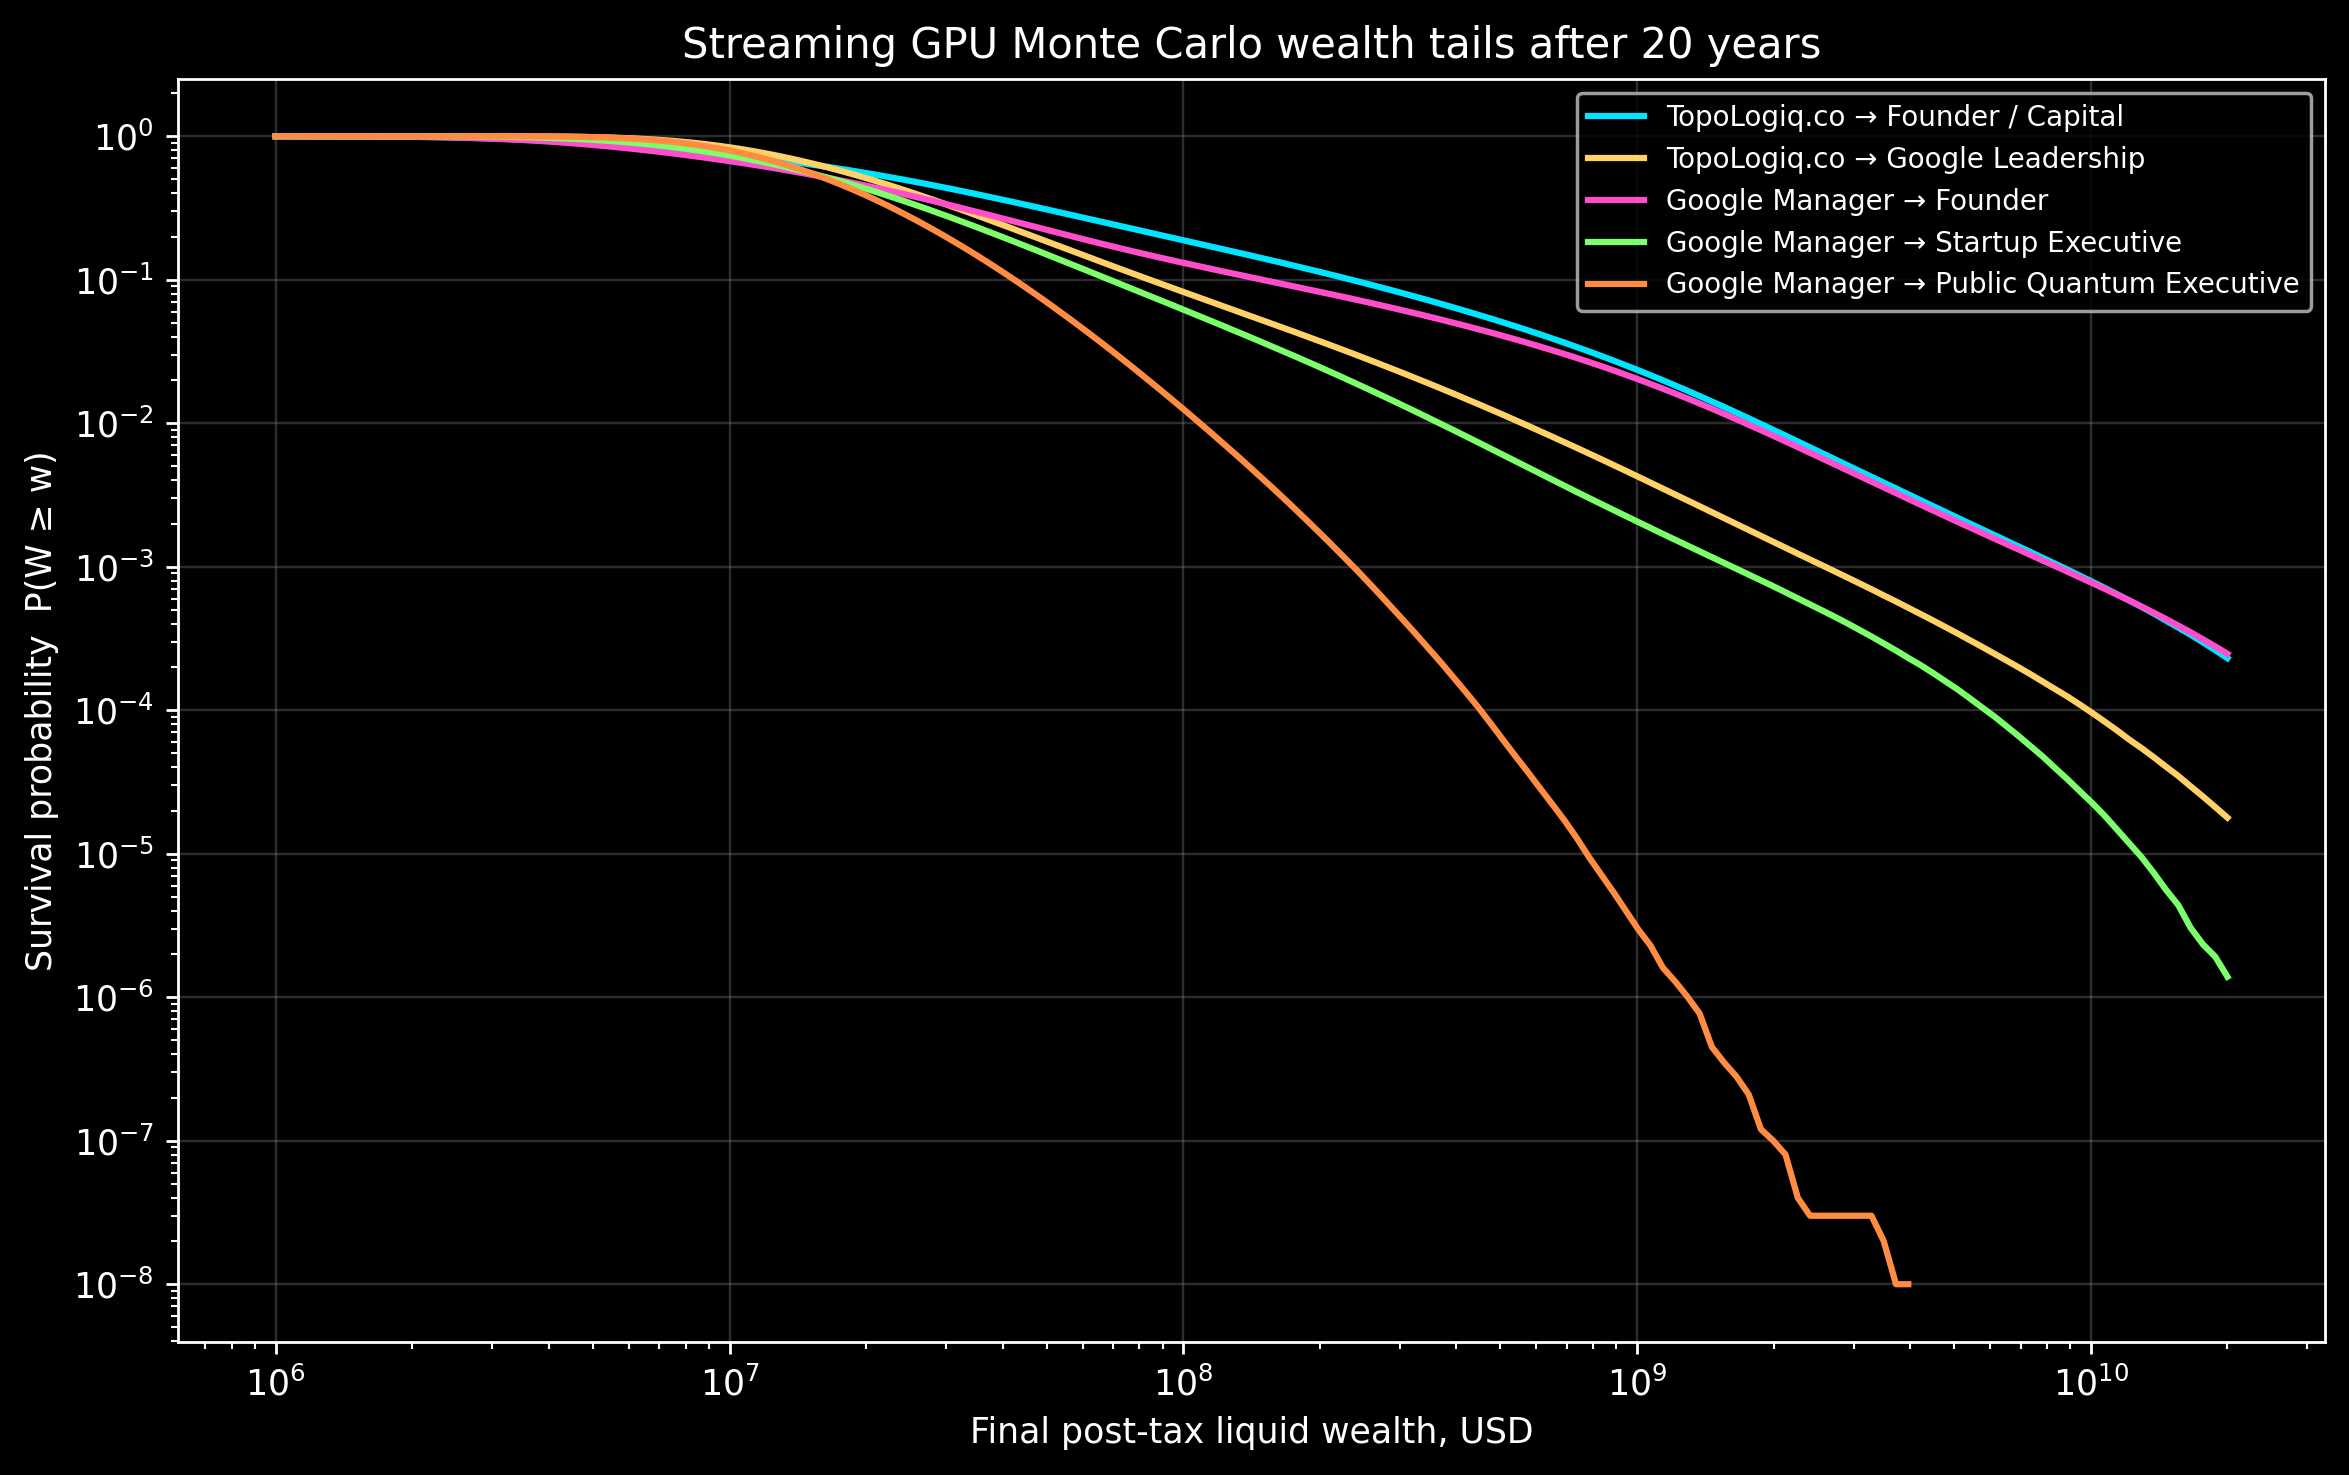

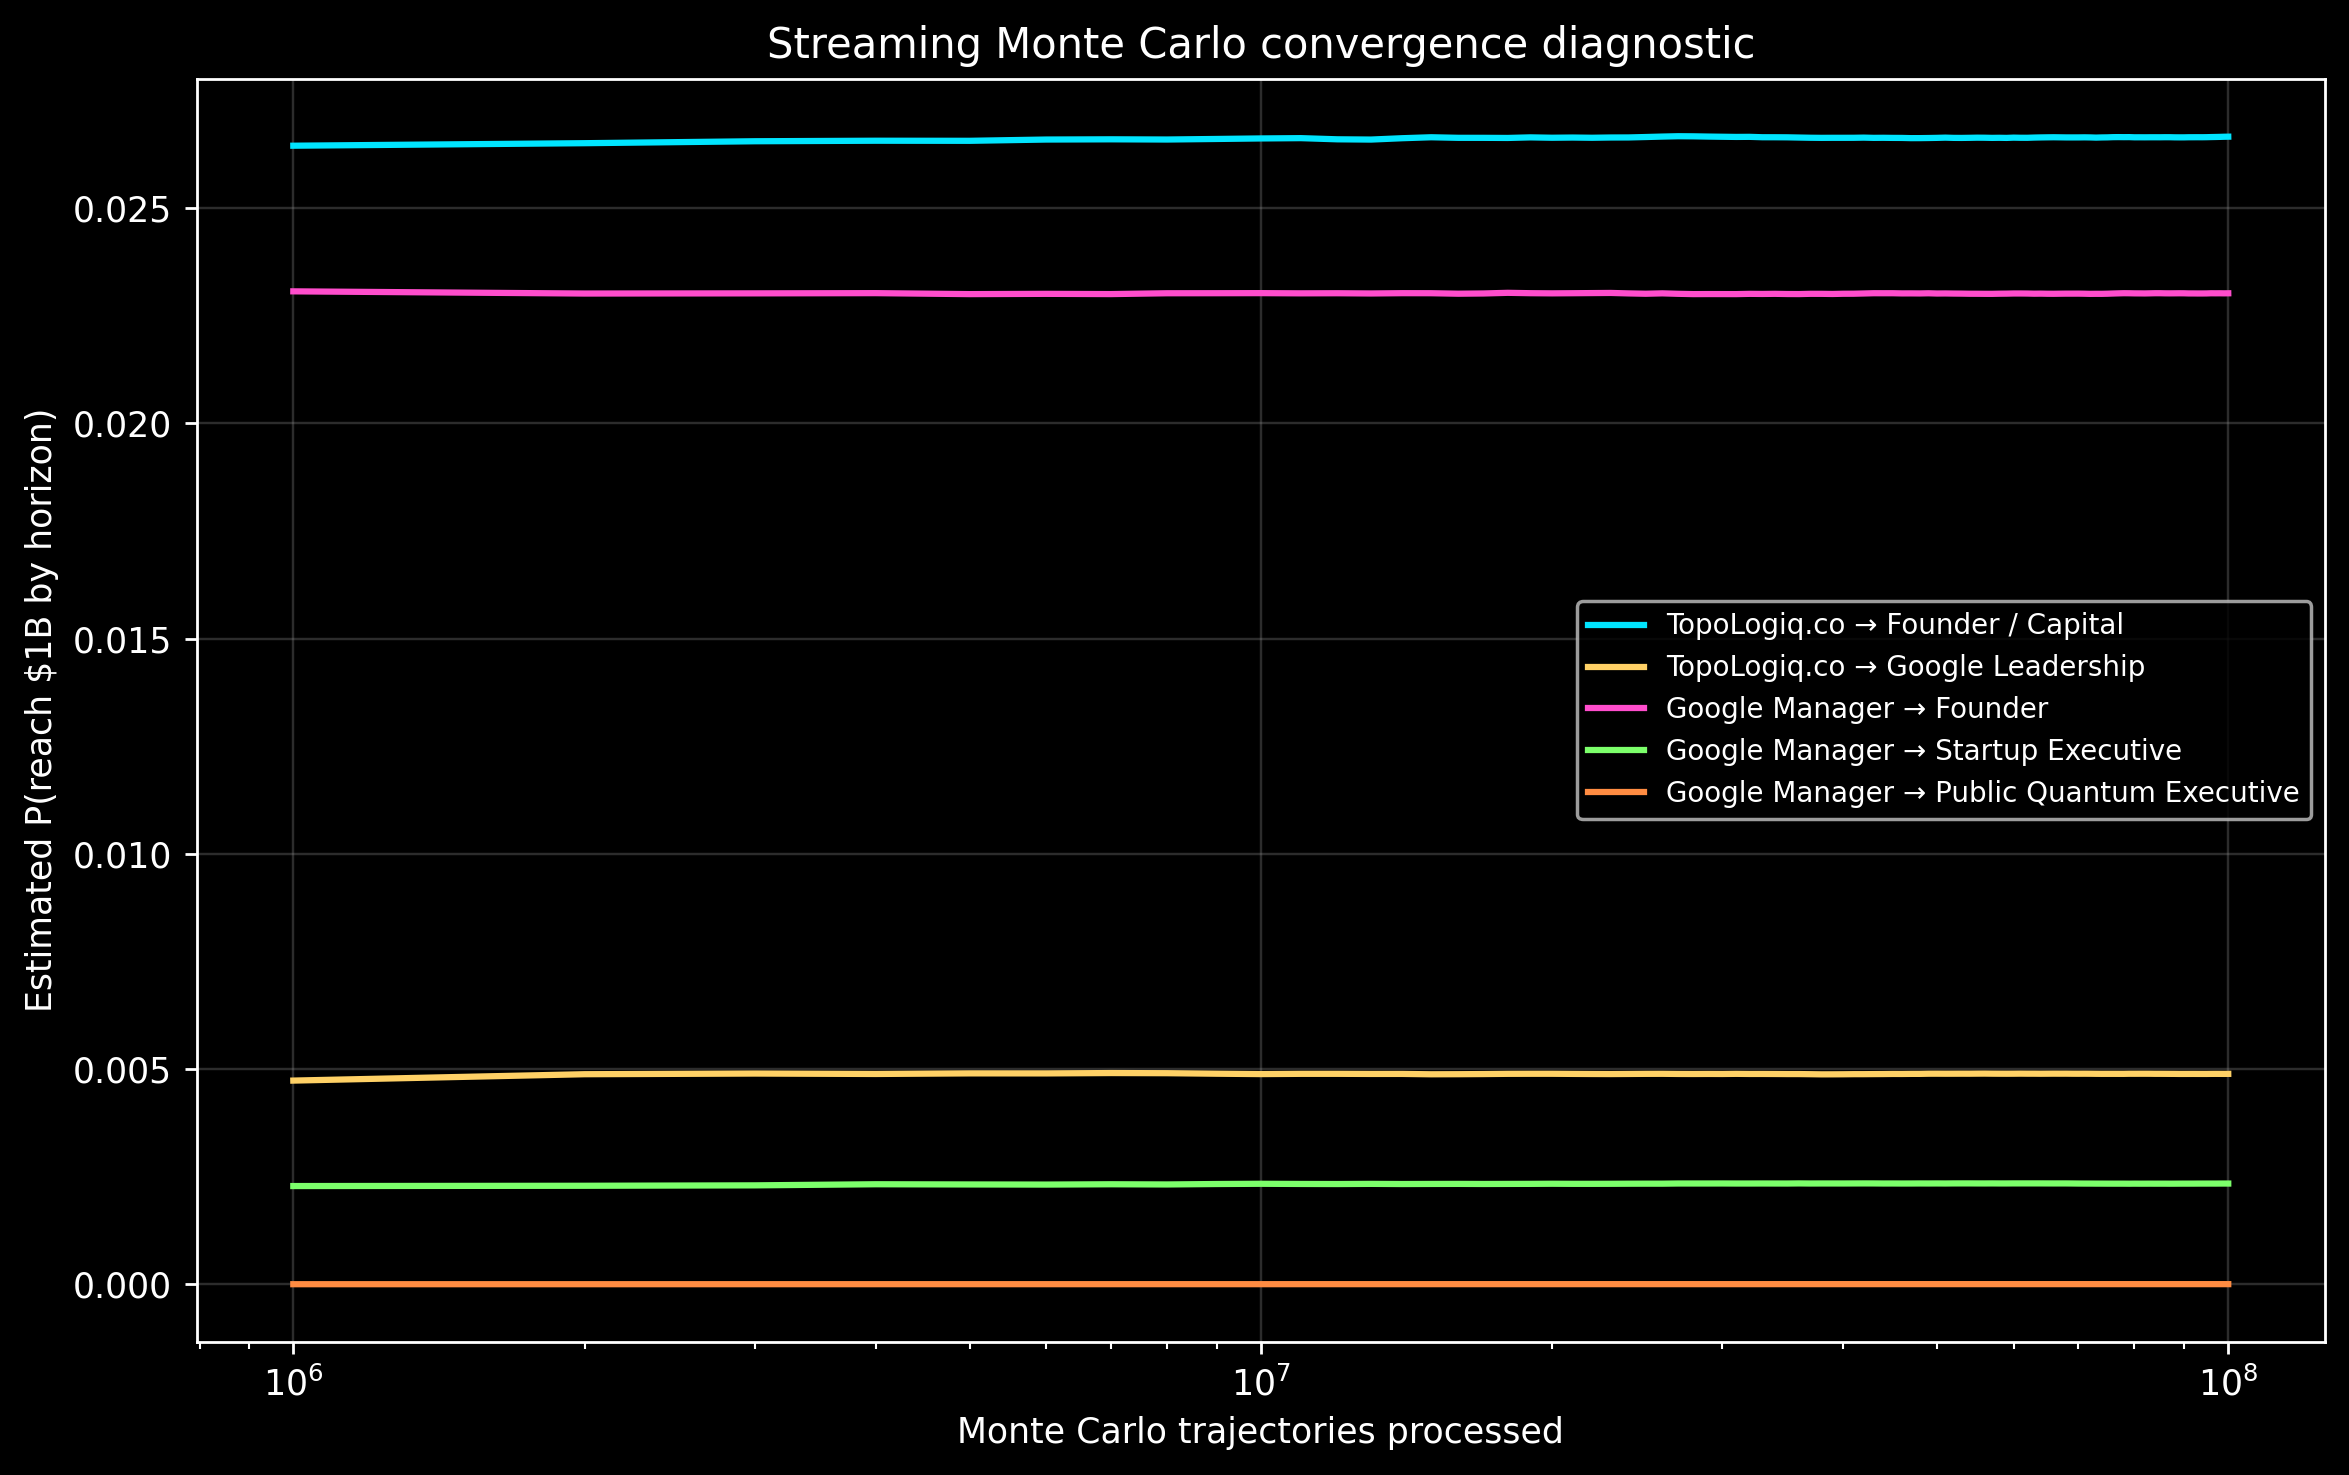

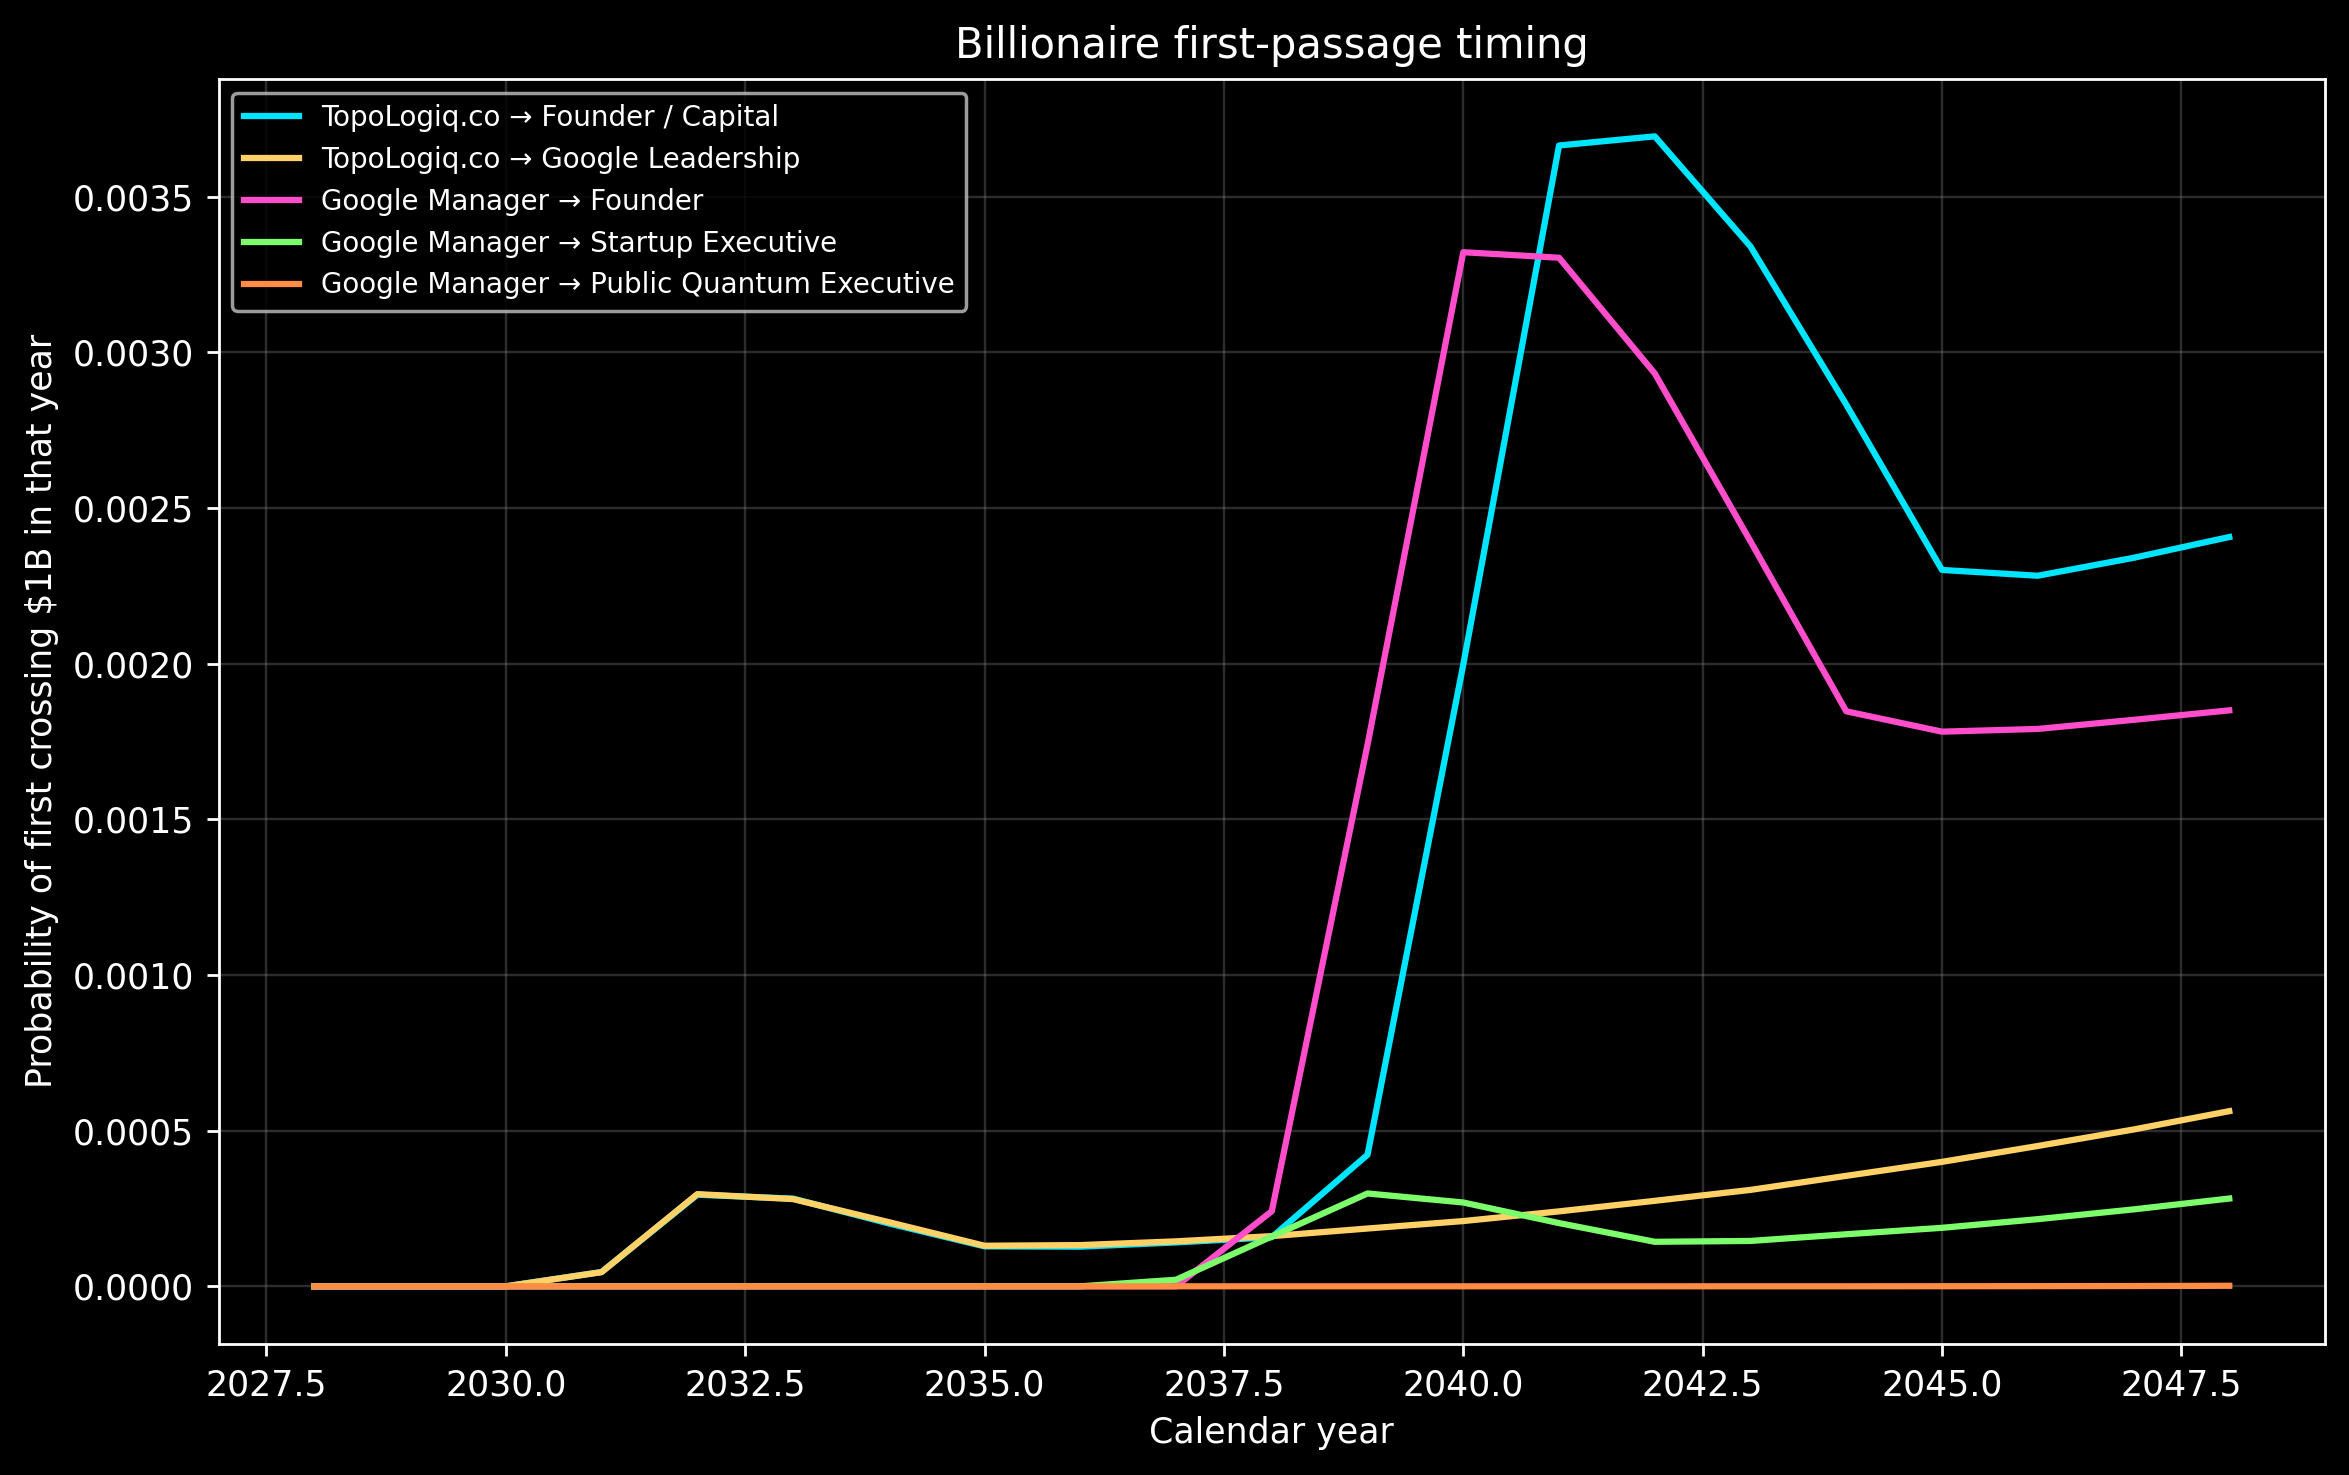

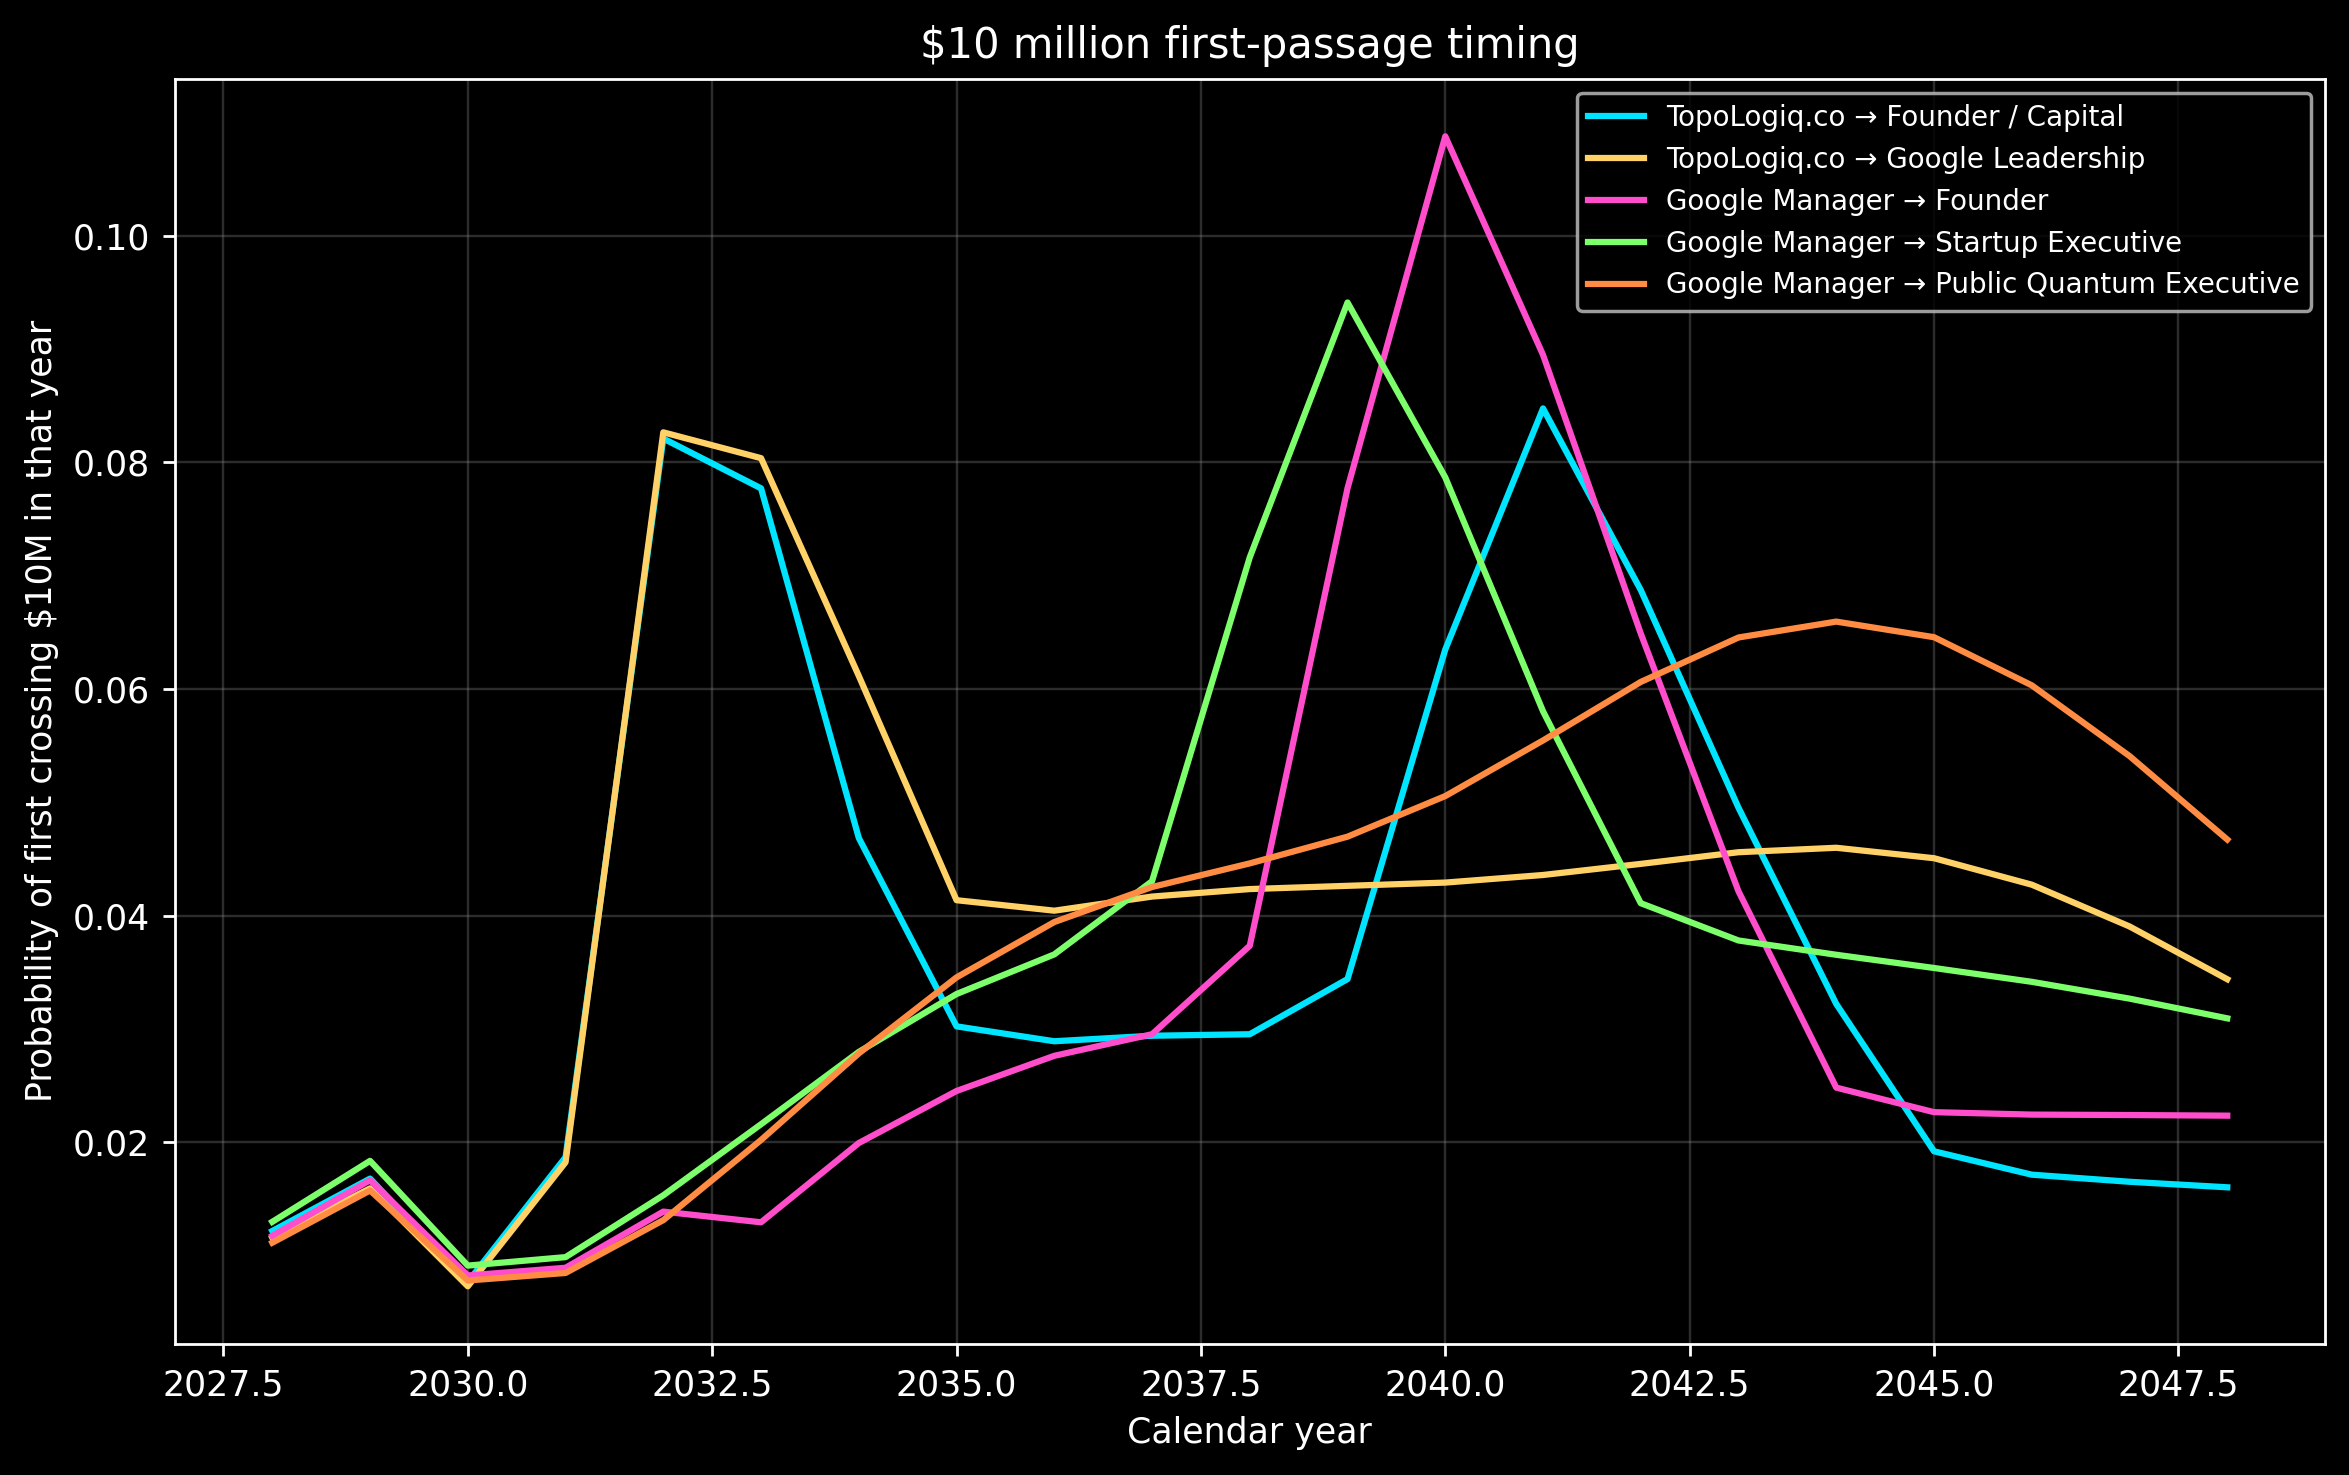

Sensitivity cells: 8/144 (8 cells processed concurrently)
Sensitivity cells: 16/144 (8 cells processed concurrently)
Sensitivity cells: 24/144 (8 cells processed concurrently)
Sensitivity cells: 32/144 (8 cells processed concurrently)
Sensitivity cells: 40/144 (8 cells processed concurrently)
Sensitivity cells: 48/144 (8 cells processed concurrently)
Sensitivity cells: 56/144 (8 cells processed concurrently)
Sensitivity cells: 64/144 (8 cells processed concurrently)
Sensitivity cells: 72/144 (8 cells processed concurrently)
Sensitivity cells: 80/144 (8 cells processed concurrently)
Sensitivity cells: 88/144 (8 cells processed concurrently)
Sensitivity cells: 96/144 (8 cells processed concurrently)
Sensitivity cells: 104/144 (8 cells processed concurrently)
Sensitivity cells: 112/144 (8 cells processed concurrently)
Sensitivity cells: 120/144 (8 cells processed concurrently)
Sensitivity cells: 128/144 (8 cells processed concurrently)
Sensitivity cells: 136/144 (8 cells processed concurr

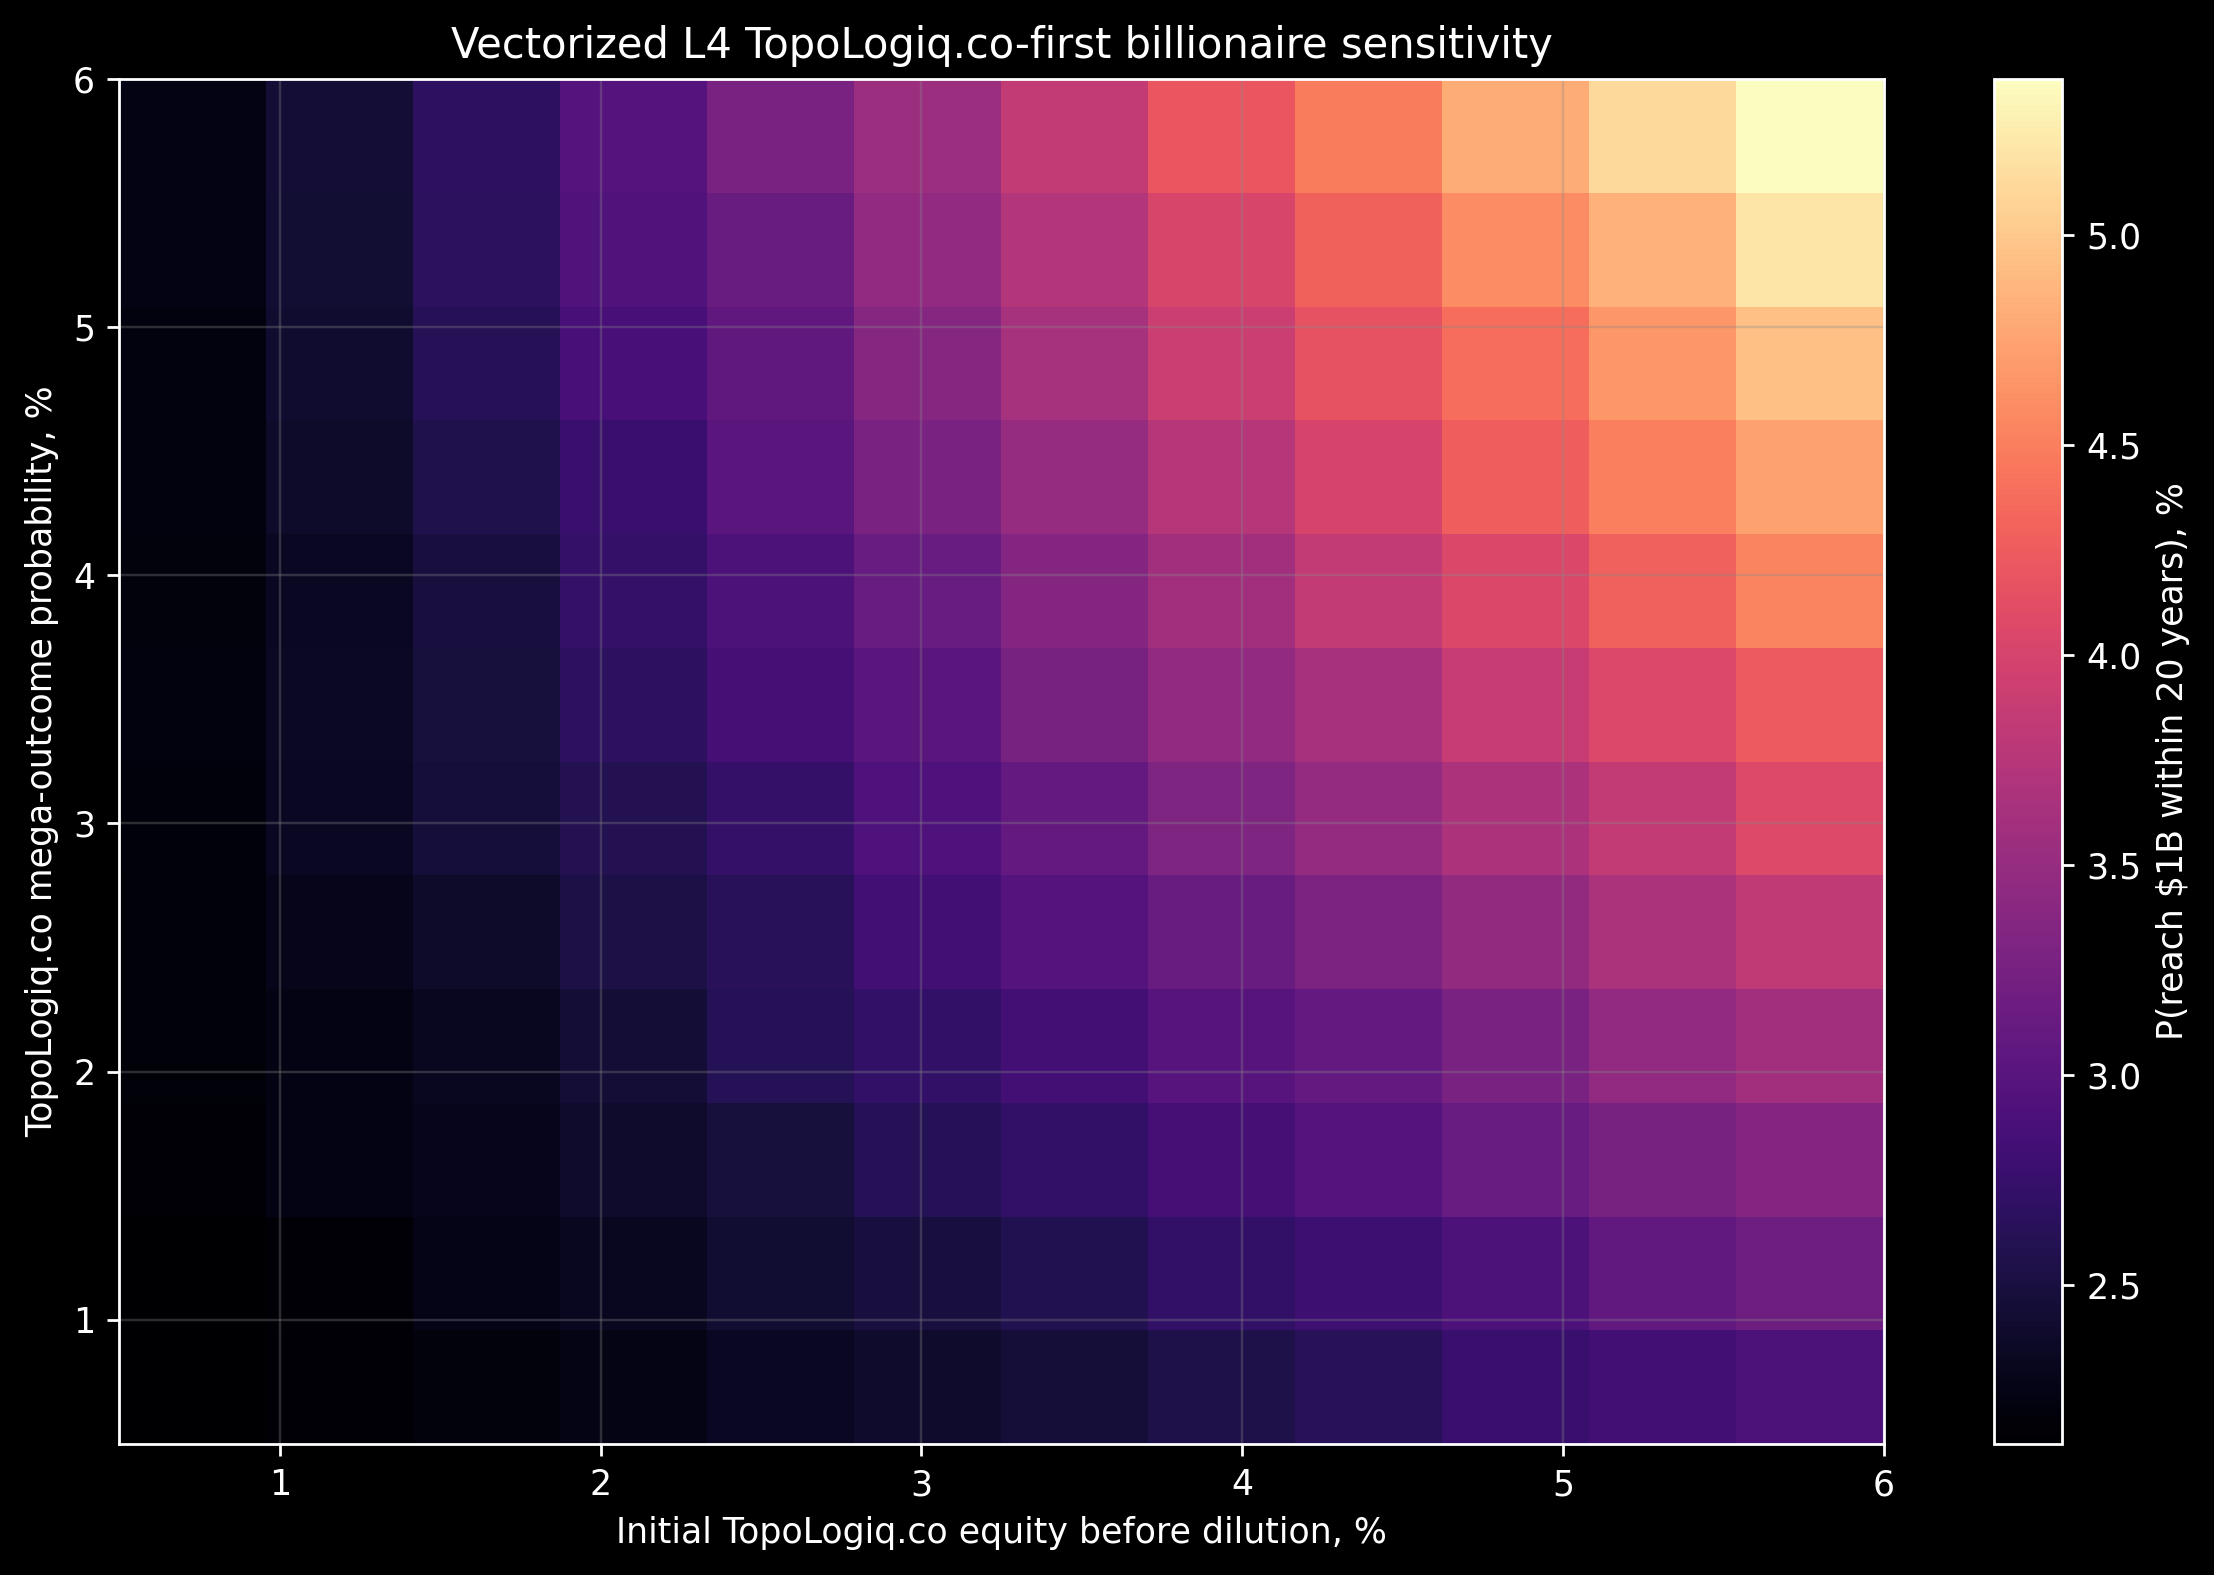


Recruiting cash is modeled as a realized post-tax award. An offer that is never accepted, matched, or converted into a paid package contributes zero liquid wealth.
Demonstrated engineering adoption is routed mainly into recruiting intensity, offer tails, compensation, and equity terms. Its direct effect on intrinsic venture-exit probabilities is intentionally weak.
Company, compensation, equity, financing, and exit inputs are scenario priors. Replace them with actual terms as those observations arrive.


In [ ]:
"""Run an L4-optimized GPU Monte Carlo career-to-wealth analysis.

The solver compares several career sequences with vectorized CuPy kernels,
streaming statistical reductions, heavy-tailed private-company outcomes, and
an optional GPU Metropolis-Hastings calibration stage. The implementation
adapts its trajectory count, memory budget, batch size, and sensitivity sweep
to an NVIDIA L4 when that device is detected in Google Colab.

Company-specific values are scenario priors. Replace them with actual offer
terms, cap-table information, financing expectations, comparable exits, and
other decision-relevant data as those values become available.

The model also includes bounded career leverage and a competitive recruiting
market. Observable work output, professional milestones, and demonstrated
engineering adoption can improve negotiating leverage. Engineering adoption
includes workflow integration, user-facility fabrication use, dissertation
reuse, and active technical-workshop use. Each recruiting cycle samples several
simultaneous serious bidders and carries the strongest monetized package into
the wealth trajectory. Package priors include ordinary awards, seven-figure
incentives, and a capped open-ended tail for blank-check-like recruiting
outcomes. Unrealized or declined recruiting cycles contribute zero liquid
wealth.
"""

import math
import time
from dataclasses import dataclass, field, replace
from typing import Final

import cupy as cp
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# -----------------------------------------------------------------------------
# Control knobs - simulation scale and L4 adaptation
# -----------------------------------------------------------------------------

RANDOM_SEED: Final[int] = 73

START_YEAR: Final[int] = 2028
HORIZON_YEARS: Final[int] = 20

"""Set to an integer to force a trajectory count.

Using None activates hardware-aware defaults. The L4 default is intentionally
larger than the generic-GPU default because the streaming reducer avoids
storing every trajectory for the complete path simulation.
"""
N_SIMULATIONS: Final[int | None] = None

"""Use an aggressive streaming sample budget on NVIDIA L4 hardware.

One hundred million trajectories are evaluated for each career path. Complete
trajectory histories are never retained, so this setting increases statistical
power without requiring all samples to fit in VRAM at the same time.
"""
L4_N_SIMULATIONS: Final[int] = 100_000_000
GENERIC_N_SIMULATIONS: Final[int] = 2_000_000

AUTO_TUNE_BATCH: Final[bool] = True
BENCHMARK_BATCH_AUTOTUNE: Final[bool] = True
PREFER_MAX_THROUGHPUT_BATCH: Final[bool] = True

"""Set to an integer to cap the batch size manually.

Using None enables the hardware-aware ceiling. The L4 profile permits batches
up to sixteen million trajectories, then benchmarks several resident batch
sizes and selects the measured throughput winner. Adaptive OOM recovery still
reduces the batch if the active Colab session has less usable VRAM.
"""
MAX_BATCH_SIZE: Final[int | None] = None
L4_MAX_BATCH_SIZE: Final[int] = 16_000_000
GENERIC_MAX_BATCH_SIZE: Final[int] = 1_000_000
MIN_BATCH_SIZE: Final[int] = 25_000

"""Set to a float in (0, 1) to force a GPU-memory target fraction."""
GPU_MEMORY_FRACTION: Final[float | None] = None
L4_GPU_MEMORY_FRACTION: Final[float] = 0.88
GENERIC_GPU_MEMORY_FRACTION: Final[float] = 0.35

ESTIMATED_BYTES_PER_SAMPLE: Final[int] = 288
OOM_BATCH_REDUCTION_FACTOR: Final[float] = 0.50

L4_BATCH_BENCHMARK_CANDIDATES: Final[tuple[int, ...]] = (
    500_000,
    1_000_000,
    2_000_000,
    4_000_000,
    6_000_000,
    8_000_000,
    12_000_000,
    16_000_000,
)
GENERIC_BATCH_BENCHMARK_CANDIDATES: Final[tuple[int, ...]] = (
    100_000,
    250_000,
    500_000,
    1_000_000,
)
BATCH_BENCHMARK_REPEATS: Final[int] = 5
BATCH_THROUGHPUT_FRACTION_OF_BEST: Final[float] = 0.995

SIM_DTYPE = cp.float32
SUMMARY_DTYPE = cp.float64

INITIAL_LIQUID_WEALTH_USD: Final[float] = 0.0

TEN_MILLION_USD: Final[float] = 10_000_000.0
RETIREMENT_TARGET_USD: Final[float] = TEN_MILLION_USD
RETIREMENT_TEST_YEAR: Final[int] = 4

HUNDRED_MILLION_USD: Final[float] = 100_000_000.0
BILLIONAIRE_TARGET_USD: Final[float] = 1_000_000_000.0

TAIL_HIT_DIAGNOSTIC_TARGET: Final[int] = 1_000


# -----------------------------------------------------------------------------
# Control knobs - streaming distributions and plots
# -----------------------------------------------------------------------------

WEALTH_SURVIVAL_GRID_USD = np.geomspace(
    1.0e6,
    2.0e10,
    160,
).astype(np.float64)

WEALTH_HISTOGRAM_MIN_USD: Final[float] = 1.0
WEALTH_HISTOGRAM_MAX_USD: Final[float] = 1.0e14
WEALTH_HISTOGRAM_LOG_POINTS: Final[int] = 8_192

_WEALTH_HISTOGRAM_BASE = np.geomspace(
    WEALTH_HISTOGRAM_MIN_USD,
    WEALTH_HISTOGRAM_MAX_USD,
    WEALTH_HISTOGRAM_LOG_POINTS,
).astype(np.float64)

WEALTH_HISTOGRAM_THRESHOLDS_USD = np.unique(
    np.concatenate(
        [
            _WEALTH_HISTOGRAM_BASE,
            WEALTH_SURVIVAL_GRID_USD,
            np.asarray(
                [
                    RETIREMENT_TARGET_USD,
                    HUNDRED_MILLION_USD,
                    BILLIONAIRE_TARGET_USD,
                ],
                dtype=np.float64,
            ),
        ]
    )
)


# -----------------------------------------------------------------------------
# Control knobs - diversified liquid portfolio
# -----------------------------------------------------------------------------

PUBLIC_MARKET_EXPECTED_RETURN: Final[float] = 0.075
PUBLIC_MARKET_VOLATILITY: Final[float] = 0.18


# -----------------------------------------------------------------------------
# Control knobs - track-record career leverage
# -----------------------------------------------------------------------------

USE_TRACK_RECORD_LEVERAGE: Final[bool] = True
TRACK_RECORD_LEVERAGE_STRENGTH: Final[float] = 0.35

TRACK_RECORD_TOTAL_STARS: Final[int] = 699
TRACK_RECORD_REPOSITORY_COUNT: Final[int] = 64
TRACK_RECORD_PINNED_STARS: Final[int] = 271
TRACK_RECORD_PINNED_FORKS: Final[int] = 45
TRACK_RECORD_CONTRIBUTIONS_1Y: Final[int] = 2_128
TRACK_RECORD_CONTRIBUTIONS_4Y: Final[int] = 7_841
TRACK_RECORD_RECENT_MONTHLY_COMMITS: Final[int] = 170
TRACK_RECORD_RECENT_ACTIVE_REPOSITORIES: Final[int] = 9

TRACK_RECORD_FORMER_IBM_QUANTUM_HARDWARE: Final[bool] = True
TRACK_RECORD_NSF_GRFP: Final[bool] = True
TRACK_RECORD_LEAD_DOCTORAL_RESEARCHER: Final[bool] = True
TRACK_RECORD_ECOSYSTEM_INTEGRATION: Final[bool] = True

"""Demonstrated technical adoption beyond repository popularity metrics."""
TRACK_RECORD_ENGINEERING_WORKFLOW_INTEGRATION: Final[bool] = True
TRACK_RECORD_USER_FACILITY_FAB_ADOPTION: Final[bool] = True
TRACK_RECORD_DISSERTATION_USAGE: Final[bool] = True
TRACK_RECORD_QUANTUM_DEVICE_CONSORTIUM_WORKSHOP_USAGE: Final[bool] = True

TRACK_RECORD_STAR_SCALE: Final[float] = 500.0
TRACK_RECORD_PINNED_STAR_SCALE: Final[float] = 180.0
TRACK_RECORD_FORK_SCALE: Final[float] = 35.0
TRACK_RECORD_REPOSITORY_SCALE: Final[float] = 50.0
TRACK_RECORD_CONTRIBUTION_1Y_SCALE: Final[float] = 1_800.0
TRACK_RECORD_ANNUALIZED_4Y_SCALE: Final[float] = 1_800.0
TRACK_RECORD_MONTHLY_COMMIT_SCALE: Final[float] = 150.0
TRACK_RECORD_ACTIVE_REPOSITORY_SCALE: Final[float] = 8.0

"""Career-leverage weights. Technical adoption receives the largest share."""
TRACK_RECORD_OPEN_SOURCE_WEIGHT: Final[float] = 0.20
TRACK_RECORD_EXECUTION_WEIGHT: Final[float] = 0.15
TRACK_RECORD_CREDENTIAL_WEIGHT: Final[float] = 0.25
TRACK_RECORD_TECHNICAL_ADOPTION_WEIGHT: Final[float] = 0.40

TRACK_RECORD_WORKFLOW_ADOPTION_WEIGHT: Final[float] = 0.35
TRACK_RECORD_FAB_ADOPTION_WEIGHT: Final[float] = 0.25
TRACK_RECORD_DISSERTATION_ADOPTION_WEIGHT: Final[float] = 0.20
TRACK_RECORD_WORKSHOP_ADOPTION_WEIGHT: Final[float] = 0.20

"""Career economics receive stronger adoption routing than venture outcomes."""
TRACK_RECORD_MAX_COMPENSATION_UPLIFT: Final[float] = 0.08
TECHNICAL_ADOPTION_MAX_COMPENSATION_UPLIFT: Final[float] = 0.10

TRACK_RECORD_MAX_EQUITY_UPLIFT: Final[float] = 0.12
TECHNICAL_ADOPTION_MAX_EQUITY_UPLIFT: Final[float] = 0.18

TRACK_RECORD_MAX_EXIT_DELAY_REDUCTION: Final[float] = 0.03
TRACK_RECORD_MAX_SALARY_GROWTH_SHIFT: Final[float] = 0.003
TECHNICAL_ADOPTION_MAX_SALARY_GROWTH_SHIFT: Final[float] = 0.003

"""Venture-outcome effects stay deliberately weak relative to recruiting."""
TRACK_RECORD_FAILURE_LOG_WEIGHT: Final[float] = -0.12
TRACK_RECORD_MODERATE_LOG_WEIGHT: Final[float] = 0.01
TRACK_RECORD_BREAKOUT_LOG_WEIGHT: Final[float] = 0.10
TRACK_RECORD_MEGA_LOG_WEIGHT: Final[float] = 0.12

VENTURE_SIGNAL_OPEN_SOURCE_WEIGHT: Final[float] = 0.30
VENTURE_SIGNAL_EXECUTION_WEIGHT: Final[float] = 0.35
VENTURE_SIGNAL_CREDENTIAL_WEIGHT: Final[float] = 0.25
VENTURE_SIGNAL_TECHNICAL_ADOPTION_WEIGHT: Final[float] = 0.10


# -----------------------------------------------------------------------------
# Control knobs - competitive recruiting and exceptional bonuses
# -----------------------------------------------------------------------------

"""Organizations named in the supplied post-PhD managerial-leverage chart.

The list defines the size of the recruiting market. It does not assign a
specific compensation package to any named organization. Actual offers should
replace the generic package priors below as offer letters and term sheets
become available.
"""
RECRUITING_COMPANIES: Final[tuple[str, ...]] = (
    "Google Quantum AI",
    "IonQ",
    "TopoLogiq.co",
    "Trimagnetix",
    "BesiMax AI Inc.",
    "Bluefors",
    "Quantum Circuits Inc. (QCI) / D-Wave",
    "IBM Research",
)

"""Probability that a competitive recruiting cycle produces liquid proceeds.

A realized cycle can represent an accepted sign-on package, a retention award,
a negotiated cash-equivalent incentive, or another monetized recruiting event.
Unrealized or declined cycles contribute zero liquid wealth.
"""
RECRUITING_PACKAGE_REALIZATION_PROB: Final[float] = 0.60

RECRUITING_EVENT_DELAY_TRIANGLE: Final[tuple[float, float, float]] = (
    0.0,
    0.0,
    2.0,
)

"""Number of simultaneous serious bidders in a realized recruiting cycle."""
RECRUITING_ACTIVE_BIDDERS_TRIANGLE: Final[tuple[float, float, float]] = (
    2.0,
    4.0,
    8.0,
)
RECRUITING_MAX_ACTIVE_BIDDERS: Final[int] = len(RECRUITING_COMPANIES)

"""Per-bid package mixture.

The open-ended tier represents the blank-check-like tail described by the user.
It remains capped so a rare draw cannot dominate the complete Monte Carlo
distribution without an actual contractual basis.
"""
RECRUITING_P_STANDARD: Final[float] = 0.62
RECRUITING_P_EXCEPTIONAL: Final[float] = 0.28
RECRUITING_P_OPEN_ENDED: Final[float] = 0.10

RECRUITING_STANDARD_BONUS_TRIANGLE: Final[tuple[float, float, float]] = (
    100_000.0,
    350_000.0,
    1_000_000.0,
)

RECRUITING_EXCEPTIONAL_BONUS_TRIANGLE: Final[
    tuple[float, float, float]
] = (
    1_000_000.0,
    2_500_000.0,
    6_000_000.0,
)

RECRUITING_OPEN_ENDED_MIN_USD: Final[float] = 2_500_000.0
RECRUITING_OPEN_ENDED_PARETO_ALPHA: Final[float] = 1.60
RECRUITING_OPEN_ENDED_CAP_USD: Final[float] = 25_000_000.0

RECRUITING_EFFECTIVE_CASH_TAX_RATE: Final[float] = 0.37

"""Negotiation uplift after selecting the strongest simultaneous bid.

The maximum bidder-count uplift is intentionally smaller than the max-of-bids
effect itself, avoiding excessive double counting of competitive pressure.
"""
RECRUITING_BIDDING_WAR_MAX_UPLIFT: Final[float] = 0.15
RECRUITING_TRACK_RECORD_MAX_UPLIFT: Final[float] = 0.15
RECRUITING_TECHNICAL_ADOPTION_MAX_UPLIFT: Final[float] = 0.20

"""Technical adoption can increase recruiting conversion and offer-tail weight."""
RECRUITING_TECHNICAL_ADOPTION_REALIZATION_UPLIFT: Final[float] = 0.15
RECRUITING_TECHNICAL_ADOPTION_MAX_EXTRA_BIDDERS: Final[int] = 2
RECRUITING_TECHNICAL_ADOPTION_TAIL_SHIFT: Final[float] = 0.12
RECRUITING_TECHNICAL_ADOPTION_EXCEPTIONAL_SHARE: Final[float] = 0.70

RECRUITING_TOPO_FOUNDER_EXPOSURE: Final[float] = 1.00
RECRUITING_TOPO_GOOGLE_EXPOSURE: Final[float] = 0.95
RECRUITING_GOOGLE_FOUNDER_EXPOSURE: Final[float] = 0.95
RECRUITING_GOOGLE_EXEC_EXPOSURE: Final[float] = 1.05
RECRUITING_GOOGLE_PUBLIC_EXPOSURE: Final[float] = 0.90

RECRUITING_DIAGNOSTIC_SAMPLES_L4: Final[int] = 2_000_000
RECRUITING_DIAGNOSTIC_SAMPLES_GENERIC: Final[int] = 250_000

# -----------------------------------------------------------------------------
# Control knobs - TopoLogiq.co executive-stage priors
# -----------------------------------------------------------------------------

TOPO_EQUITY_PCT_TRIANGLE: Final[tuple[float, float, float]] = (
    0.50,
    2.00,
    5.00,
)

TOPO_DILUTION_TRIANGLE: Final[tuple[float, float, float]] = (
    0.25,
    0.45,
    0.70,
)

TOPO_EXIT_DELAY_YEARS_TRIANGLE: Final[tuple[float, float, float]] = (
    3.0,
    4.0,
    7.0,
)

TOPO_P_FAILURE: Final[float] = 0.45
TOPO_P_MODERATE: Final[float] = 0.40
TOPO_P_BREAKOUT: Final[float] = 0.13
TOPO_P_MEGA: Final[float] = 0.02

TOPO_MODERATE_MEDIAN_USD: Final[float] = 250_000_000.0
TOPO_MODERATE_LOG_SIGMA: Final[float] = 0.80
TOPO_MODERATE_MIN_USD: Final[float] = 20_000_000.0
TOPO_MODERATE_MAX_USD: Final[float] = 5_000_000_000.0

TOPO_BREAKOUT_MEDIAN_USD: Final[float] = 3_000_000_000.0
TOPO_BREAKOUT_LOG_SIGMA: Final[float] = 0.85
TOPO_BREAKOUT_MIN_USD: Final[float] = 500_000_000.0
TOPO_BREAKOUT_MAX_USD: Final[float] = 40_000_000_000.0

TOPO_MEGA_PARETO_MIN_USD: Final[float] = 10_000_000_000.0
TOPO_MEGA_PARETO_ALPHA: Final[float] = 1.35
TOPO_MEGA_CAP_USD: Final[float] = 300_000_000_000.0

TOPO_LIQUIDITY_FRACTION_TRIANGLE: Final[tuple[float, float, float]] = (
    0.60,
    0.85,
    1.00,
)

TOPO_COMMON_PAYOUT_TRIANGLE: Final[tuple[float, float, float]] = (
    0.80,
    0.95,
    1.00,
)

TOPO_EFFECTIVE_TAX_TRIANGLE: Final[tuple[float, float, float]] = (
    0.20,
    0.28,
    0.38,
)

TOPO_START_TOTAL_COMP_USD: Final[float] = 220_000.0


# -----------------------------------------------------------------------------
# Control knobs - later founder-stage priors
# -----------------------------------------------------------------------------

FOUNDER_START_YEAR: Final[int] = 6

FOUNDER_EQUITY_PCT_TRIANGLE: Final[tuple[float, float, float]] = (
    10.0,
    18.0,
    30.0,
)

FOUNDER_DILUTION_TRIANGLE: Final[tuple[float, float, float]] = (
    0.40,
    0.58,
    0.75,
)

FOUNDER_EXIT_DELAY_YEARS_TRIANGLE: Final[tuple[float, float, float]] = (
    5.0,
    7.0,
    11.0,
)

FOUNDER_CAPITAL_FRACTION: Final[float] = 0.05
FOUNDER_CAPITAL_CAP_USD: Final[float] = 5_000_000.0

FOUNDER_P_FAILURE: Final[float] = 0.60
FOUNDER_P_MODERATE: Final[float] = 0.28
FOUNDER_P_BREAKOUT: Final[float] = 0.10
FOUNDER_P_MEGA: Final[float] = 0.02

FOUNDER_START_TOTAL_COMP_USD: Final[float] = 180_000.0


# -----------------------------------------------------------------------------
# Control knobs - startup executive stage after Google
# -----------------------------------------------------------------------------

EXEC_START_YEAR: Final[int] = 5

EXEC_EQUITY_PCT_TRIANGLE: Final[tuple[float, float, float]] = (
    1.0,
    2.5,
    5.0,
)

EXEC_DILUTION_TRIANGLE: Final[tuple[float, float, float]] = (
    0.30,
    0.50,
    0.70,
)

EXEC_EXIT_DELAY_YEARS_TRIANGLE: Final[tuple[float, float, float]] = (
    4.0,
    6.0,
    9.0,
)

EXEC_P_FAILURE: Final[float] = 0.50
EXEC_P_MODERATE: Final[float] = 0.36
EXEC_P_BREAKOUT: Final[float] = 0.12
EXEC_P_MEGA: Final[float] = 0.02

EXEC_START_TOTAL_COMP_USD: Final[float] = 300_000.0


# -----------------------------------------------------------------------------
# Control knobs - Google and scaled-company compensation
# -----------------------------------------------------------------------------

GOOGLE_MANAGER_TOTAL_COMP_USD: Final[float] = 450_000.0
GOOGLE_LEADERSHIP_TOTAL_COMP_USD: Final[float] = 550_000.0
PUBLIC_QUANTUM_EXEC_TOTAL_COMP_USD: Final[float] = 600_000.0

SAVINGS_RATE_TRIANGLE: Final[tuple[float, float, float]] = (
    0.25,
    0.40,
    0.55,
)

SALARY_GROWTH_TRIANGLE: Final[tuple[float, float, float]] = (
    0.02,
    0.045,
    0.08,
)


# -----------------------------------------------------------------------------
# Control knobs - optional GPU Metropolis-Hastings calibration
# -----------------------------------------------------------------------------

USE_MH_CALIBRATION: Final[bool] = False

"""Add successful comparable-company exit values here.

The Metropolis-Hastings stage updates the moderate-exit lognormal component.
Leave this array empty to retain the scenario prior.
"""
TOPO_SUCCESSFUL_COMPARABLE_EXITS_USD = np.array(
    [],
    dtype=np.float64,
)

MH_CHAINS: Final[int] = 2_048
MH_STEPS: Final[int] = 2_500
MH_BURN_IN: Final[int] = 1_000
MH_THIN: Final[int] = 5
MH_STEP_MU: Final[float] = 0.06
MH_STEP_LOG_SIGMA: Final[float] = 0.035


# -----------------------------------------------------------------------------
# Control knobs - L4-vectorized TopoLogiq.co sensitivity map
# -----------------------------------------------------------------------------

RUN_SENSITIVITY_HEATMAP: Final[bool] = True

"""Set to an integer to force trajectories per sensitivity cell."""
SENSITIVITY_SIMS_PER_CELL: Final[int | None] = None
L4_SENSITIVITY_SIMS_PER_CELL: Final[int] = 1_000_000
GENERIC_SENSITIVITY_SIMS_PER_CELL: Final[int] = 25_000

SENSITIVITY_CELLS_PER_GPU_BLOCK: Final[int] = 8

SENSITIVITY_EQUITY_PCT = np.linspace(
    0.5,
    6.0,
    12,
)

SENSITIVITY_MEGA_PROB = np.linspace(
    0.005,
    0.060,
    12,
)


# -----------------------------------------------------------------------------
# Plot configuration
# -----------------------------------------------------------------------------

HIGH_CONTRAST_COLORS: Final[list[str]] = [
    "#00E5FF",
    "#FFD166",
    "#FF4DCC",
    "#7CFF6B",
    "#FF8C42",
    "#B388FF",
    "#FFFFFF",
]

mpl.rcParams.update(
    {
        "figure.dpi": 250,
        "savefig.dpi": 250,
        "figure.facecolor": "black",
        "figure.edgecolor": "black",
        "savefig.facecolor": "black",
        "savefig.edgecolor": "black",
        "axes.facecolor": "black",
        "axes.edgecolor": "white",
        "axes.labelcolor": "white",
        "axes.titlecolor": "white",
        "axes.grid": True,
        "axes.prop_cycle": mpl.cycler(color=HIGH_CONTRAST_COLORS),
        "grid.color": "#8A8A8A",
        "grid.alpha": 0.32,
        "grid.linewidth": 0.7,
        "text.color": "white",
        "xtick.color": "white",
        "ytick.color": "white",
        "legend.facecolor": "black",
        "legend.edgecolor": "#BFBFBF",
        "legend.labelcolor": "white",
        "legend.framealpha": 0.82,
        "lines.linewidth": 2.0,
        "image.cmap": "magma",
    }
)


# -----------------------------------------------------------------------------
# Data models
# -----------------------------------------------------------------------------


@dataclass(frozen=True)
class GpuProfile:
    """Describe the active CUDA device and memory state."""

    name: str
    free_bytes: int
    total_bytes: int
    compute_capability: tuple[int, int]
    is_l4: bool


@dataclass(frozen=True)
class RuntimeControls:
    """Store hardware-resolved simulation controls."""

    n_simulations: int
    sensitivity_sims_per_cell: int
    memory_fraction: float
    max_batch_size: int


@dataclass(frozen=True)
class TrackRecordSignals:
    """Store observable professional inputs used by career leverage."""

    total_stars: int
    repository_count: int
    pinned_stars: int
    pinned_forks: int
    contributions_1y: int
    contributions_4y: int
    recent_monthly_commits: int
    recent_active_repositories: int
    former_ibm_quantum_hardware: bool
    nsf_grfp: bool
    lead_doctoral_researcher: bool
    ecosystem_integration: bool

    engineering_workflow_integration: bool
    user_facility_fab_adoption: bool
    dissertation_usage: bool
    quantum_device_consortium_workshop_usage: bool


@dataclass(frozen=True)
class CareerLeverage:
    """Store bounded career-leverage components and effective strength."""

    open_source_score: float
    execution_score: float
    credential_score: float
    technical_adoption_score: float
    raw_score: float
    effective_score: float
    technical_adoption_effective_score: float


@dataclass(frozen=True)
class OutcomeModel:
    """Describe a heavy-tailed private-company valuation mixture."""

    p_failure: float
    p_moderate: float
    p_breakout: float
    p_mega: float

    moderate_median_usd: float
    moderate_log_sigma: float
    moderate_min_usd: float
    moderate_max_usd: float

    breakout_median_usd: float
    breakout_log_sigma: float
    breakout_min_usd: float
    breakout_max_usd: float

    mega_pareto_min_usd: float
    mega_pareto_alpha: float
    mega_cap_usd: float


@dataclass(frozen=True)
class VentureStage:
    """Describe one private-equity stage in a career sequence."""

    name: str
    start_year: int

    equity_pct_triangle: tuple[float, float, float]
    dilution_triangle: tuple[float, float, float]
    exit_delay_years_triangle: tuple[float, float, float]

    liquidity_fraction_triangle: tuple[float, float, float]
    common_payout_triangle: tuple[float, float, float]
    effective_tax_triangle: tuple[float, float, float]

    capital_fraction: float
    capital_cap_usd: float

    outcome: OutcomeModel


@dataclass(frozen=True)
class CareerPath:
    """Describe salary phases and private-equity stages."""

    name: str

    phase_1_total_comp_usd: float
    phase_2_total_comp_usd: float
    phase_2_start_year: int

    savings_rate_triangle: tuple[float, float, float]
    salary_growth_triangle: tuple[float, float, float]

    ventures: tuple[VentureStage, ...]
    recruiting_exposure: float


@dataclass
class PathAccumulator:
    """Accumulate path statistics without retaining complete trajectories."""

    n_total: int = 0
    retire_count: int = 0
    ten_million_count: int = 0
    hundred_million_count: int = 0
    billion_count: int = 0
    billion_by_10_count: int = 0

    wealth_hist_counts: np.ndarray = field(
        default_factory=lambda: np.zeros(
            WEALTH_HISTOGRAM_THRESHOLDS_USD.size + 1,
            dtype=np.int64,
        )
    )

    ten_million_first_passage_counts: np.ndarray = field(
        default_factory=lambda: np.zeros(
            HORIZON_YEARS + 1,
            dtype=np.int64,
        )
    )

    first_passage_counts: np.ndarray = field(
        default_factory=lambda: np.zeros(
            HORIZON_YEARS + 1,
            dtype=np.int64,
        )
    )

    convergence_n: list[int] = field(default_factory=list)
    convergence_probability: list[float] = field(default_factory=list)


@dataclass(frozen=True)
class PathResult:
    """Store compact CPU-side outputs for one simulated path."""

    name: str
    summary: dict[str, float | int | str]

    survival_probability: np.ndarray

    convergence_n: np.ndarray
    convergence_probability: np.ndarray

    ten_million_first_passage_probability: np.ndarray
    first_passage_probability: np.ndarray


# -----------------------------------------------------------------------------
# Fused annual GPU kernel
# -----------------------------------------------------------------------------

ANNUAL_UPDATE_KERNEL = cp.ElementwiseKernel(
    in_params=(
        "float32 wealth_in, float32 z, float32 savings_rate, "
        "float32 salary_growth_factor, "
        "int16 first_ten_million_hit_in, int16 first_hit_in, "
        "int16 event_year_0, float32 proceeds_0, "
        "int16 event_year_1, float32 proceeds_1, "
        "int16 event_year_2, float32 proceeds_2, "
        "int16 year, float32 market_mu_log, float32 market_sigma, "
        "float32 salary_base, int16 salary_exponent, "
        "float32 capital_fraction, float32 capital_cap, "
        "float32 ten_million_target, float32 billionaire_target"
    ),
    out_params=(
        "float32 wealth_out, int16 first_ten_million_hit_out, "
        "int16 first_hit_out"
    ),
    operation=r"""
        float w = wealth_in;

        if (year > 0) {
            w *= expf(market_mu_log + market_sigma * z);
        }

        const float salary = salary_base
            * powf(salary_growth_factor, (float)salary_exponent);
        w += salary * savings_rate;

        if (capital_fraction > 0.0f) {
            const float commitment = fminf(
                w * capital_fraction,
                capital_cap
            );
            w -= commitment;
        }

        if (event_year_0 == year) {
            w += proceeds_0;
        }

        if (event_year_1 == year) {
            w += proceeds_1;
        }

        if (event_year_2 == year) {
            w += proceeds_2;
        }

        if (w < 0.0f) {
            w = 0.0f;
        }

        short ten_million_hit = first_ten_million_hit_in;
        if (ten_million_hit < 0 && w >= ten_million_target) {
            ten_million_hit = year;
        }

        short hit = first_hit_in;
        if (hit < 0 && w >= billionaire_target) {
            hit = year;
        }

        wealth_out = w;
        first_ten_million_hit_out = ten_million_hit;
        first_hit_out = hit;
    """,
    name="annual_wealth_update_l4",
)


# -----------------------------------------------------------------------------
# GPU and runtime helpers
# -----------------------------------------------------------------------------


def release_gpu_memory() -> None:
    """Release unused CuPy device and pinned-memory pool blocks."""

    cp.get_default_memory_pool().free_all_blocks()
    cp.get_default_pinned_memory_pool().free_all_blocks()



def get_gpu_profile() -> GpuProfile:
    """Inspect the active CUDA device and identify an NVIDIA L4."""

    device_id = cp.cuda.runtime.getDevice()
    properties = cp.cuda.runtime.getDeviceProperties(device_id)

    name = properties["name"]
    if isinstance(name, bytes):
        name = name.decode("utf-8")

    free_bytes, total_bytes = cp.cuda.runtime.memGetInfo()

    major = int(properties.get("major", 0))
    minor = int(properties.get("minor", 0))

    normalized_name = str(name).upper()
    is_l4 = "NVIDIA L4" in normalized_name or normalized_name.endswith("L4")

    return GpuProfile(
        name=str(name),
        free_bytes=int(free_bytes),
        total_bytes=int(total_bytes),
        compute_capability=(major, minor),
        is_l4=is_l4,
    )



def resolve_runtime_controls(profile: GpuProfile) -> RuntimeControls:
    """Resolve hardware-aware trajectory and memory settings."""

    if N_SIMULATIONS is None:
        n_simulations = (
            L4_N_SIMULATIONS
            if profile.is_l4
            else GENERIC_N_SIMULATIONS
        )
    else:
        n_simulations = int(N_SIMULATIONS)

    if SENSITIVITY_SIMS_PER_CELL is None:
        sensitivity_sims = (
            L4_SENSITIVITY_SIMS_PER_CELL
            if profile.is_l4
            else GENERIC_SENSITIVITY_SIMS_PER_CELL
        )
    else:
        sensitivity_sims = int(SENSITIVITY_SIMS_PER_CELL)

    if GPU_MEMORY_FRACTION is None:
        memory_fraction = (
            L4_GPU_MEMORY_FRACTION
            if profile.is_l4
            else GENERIC_GPU_MEMORY_FRACTION
        )
    else:
        memory_fraction = float(GPU_MEMORY_FRACTION)

    if MAX_BATCH_SIZE is None:
        max_batch_size = (
            L4_MAX_BATCH_SIZE
            if profile.is_l4
            else GENERIC_MAX_BATCH_SIZE
        )
    else:
        max_batch_size = int(MAX_BATCH_SIZE)

    if n_simulations <= 0:
        raise ValueError("n_simulations must be positive.")

    if sensitivity_sims <= 0:
        raise ValueError("sensitivity_sims_per_cell must be positive.")

    if not 0.0 < memory_fraction < 1.0:
        raise ValueError("GPU memory fraction must lie inside (0, 1).")

    if max_batch_size < MIN_BATCH_SIZE:
        raise ValueError(
            "max_batch_size must be at least MIN_BATCH_SIZE."
        )

    return RuntimeControls(
        n_simulations=n_simulations,
        sensitivity_sims_per_cell=sensitivity_sims,
        memory_fraction=memory_fraction,
        max_batch_size=max_batch_size,
    )



def print_runtime_profile(
    profile: GpuProfile,
    controls: RuntimeControls,
) -> None:
    """Print the resolved CUDA execution profile."""

    print(f"CUDA device: {profile.name}")
    print(
        "Compute capability: "
        f"{profile.compute_capability[0]}.{profile.compute_capability[1]}"
    )
    print(
        f"GPU memory: {profile.free_bytes / 2**30:.2f} GiB free / "
        f"{profile.total_bytes / 2**30:.2f} GiB total"
    )
    print(f"CuPy version: {cp.__version__}")
    print(f"L4 profile active: {profile.is_l4}")
    print(f"Main trajectories per path: {controls.n_simulations:,}")
    print(
        "Sensitivity trajectories per cell: "
        f"{controls.sensitivity_sims_per_cell:,}"
    )
    print(f"GPU memory target: {100.0 * controls.memory_fraction:.1f}%")
    print(f"Maximum batch cap: {controls.max_batch_size:,}")


# -----------------------------------------------------------------------------
# Distribution helpers
# -----------------------------------------------------------------------------


def validate_probability_model(model: OutcomeModel) -> None:
    """Check mixture probabilities before simulation."""

    total = (
        model.p_failure
        + model.p_moderate
        + model.p_breakout
        + model.p_mega
    )

    if abs(total - 1.0) > 1.0e-9:
        raise ValueError(
            "Outcome probabilities must sum to 1.0. "
            f"Received {total:.8f}."
        )

    values = (
        model.p_failure,
        model.p_moderate,
        model.p_breakout,
        model.p_mega,
    )

    if any(value < 0.0 or value > 1.0 for value in values):
        raise ValueError("Every outcome probability must lie in [0, 1].")



def gpu_triangular(
    low: float,
    mode: float,
    high: float,
    size: int,
    dtype: type,
) -> cp.ndarray:
    """Draw triangular random variates directly in the requested GPU dtype."""

    if abs(high - low) <= 1.0e-15:
        return cp.full(size, low, dtype=dtype)

    if low > mode or mode > high:
        raise ValueError(
            "Triangular parameters require low <= mode <= high."
        )

    u = cp.random.random(size, dtype=dtype)

    width = dtype(high - low)
    left_width = dtype(mode - low)
    right_width = dtype(high - mode)
    split = dtype((mode - low) / (high - low))

    left = dtype(low) + cp.sqrt(
        cp.maximum(
            u * width * left_width,
            dtype(0.0),
        )
    )

    right = dtype(high) - cp.sqrt(
        cp.maximum(
            (dtype(1.0) - u) * width * right_width,
            dtype(0.0),
        )
    )

    return cp.where(u <= split, left, right).astype(dtype, copy=False)



def sample_exit_valuation(
    n: int,
    model: OutcomeModel,
    dtype: type,
) -> cp.ndarray:
    """Sample a four-component heavy-tailed company valuation mixture."""

    validate_probability_model(model)

    valuation = cp.zeros(n, dtype=dtype)
    u = cp.random.random(n, dtype=dtype)

    moderate_upper = model.p_failure + model.p_moderate
    breakout_upper = moderate_upper + model.p_breakout

    moderate_mask = (
        (u >= dtype(model.p_failure))
        & (u < dtype(moderate_upper))
    )

    breakout_mask = (
        (u >= dtype(moderate_upper))
        & (u < dtype(breakout_upper))
    )

    mega_mask = u >= dtype(breakout_upper)

    z_moderate = cp.random.standard_normal(n, dtype=dtype)
    moderate = dtype(model.moderate_median_usd) * cp.exp(
        dtype(model.moderate_log_sigma) * z_moderate
    )
    moderate = cp.clip(
        moderate,
        dtype(model.moderate_min_usd),
        dtype(model.moderate_max_usd),
    )
    valuation = cp.where(moderate_mask, moderate, valuation)

    z_breakout = cp.random.standard_normal(n, dtype=dtype)
    breakout = dtype(model.breakout_median_usd) * cp.exp(
        dtype(model.breakout_log_sigma) * z_breakout
    )
    breakout = cp.clip(
        breakout,
        dtype(model.breakout_min_usd),
        dtype(model.breakout_max_usd),
    )
    valuation = cp.where(breakout_mask, breakout, valuation)

    u_mega = cp.maximum(
        cp.random.random(n, dtype=dtype),
        dtype(1.0e-7),
    )

    mega = dtype(model.mega_pareto_min_usd) * cp.power(
        u_mega,
        dtype(-1.0 / model.mega_pareto_alpha),
    )
    mega = cp.minimum(mega, dtype(model.mega_cap_usd))
    valuation = cp.where(mega_mask, mega, valuation)

    return valuation



def sample_exit_valuation_variable_mega(
    mega_probability: cp.ndarray,
    model: OutcomeModel,
    dtype: type,
) -> cp.ndarray:
    """Sample valuations with a per-trajectory mega-outcome probability.

    Failure and breakout probabilities stay fixed. Changing the mega-outcome
    probability transfers probability mass to or from the moderate component.
    This form lets one L4 batch process several sensitivity-map cells at once.
    """

    n = int(mega_probability.size)

    moderate_probability = (
        dtype(1.0)
        - dtype(model.p_failure)
        - dtype(model.p_breakout)
        - mega_probability
    )

    if bool(cp.any(moderate_probability <= dtype(0.0)).get()):
        raise ValueError(
            "Sensitivity settings leave no positive moderate-outcome mass."
        )

    valuation = cp.zeros(n, dtype=dtype)
    u = cp.random.random(n, dtype=dtype)

    moderate_upper = dtype(model.p_failure) + moderate_probability
    breakout_upper = dtype(1.0) - mega_probability

    moderate_mask = (
        (u >= dtype(model.p_failure))
        & (u < moderate_upper)
    )
    breakout_mask = (
        (u >= moderate_upper)
        & (u < breakout_upper)
    )
    mega_mask = u >= breakout_upper

    z_moderate = cp.random.standard_normal(n, dtype=dtype)
    moderate = dtype(model.moderate_median_usd) * cp.exp(
        dtype(model.moderate_log_sigma) * z_moderate
    )
    moderate = cp.clip(
        moderate,
        dtype(model.moderate_min_usd),
        dtype(model.moderate_max_usd),
    )
    valuation = cp.where(moderate_mask, moderate, valuation)

    z_breakout = cp.random.standard_normal(n, dtype=dtype)
    breakout = dtype(model.breakout_median_usd) * cp.exp(
        dtype(model.breakout_log_sigma) * z_breakout
    )
    breakout = cp.clip(
        breakout,
        dtype(model.breakout_min_usd),
        dtype(model.breakout_max_usd),
    )
    valuation = cp.where(breakout_mask, breakout, valuation)

    u_mega = cp.maximum(
        cp.random.random(n, dtype=dtype),
        dtype(1.0e-7),
    )
    mega = dtype(model.mega_pareto_min_usd) * cp.power(
        u_mega,
        dtype(-1.0 / model.mega_pareto_alpha),
    )
    mega = cp.minimum(mega, dtype(model.mega_cap_usd))
    valuation = cp.where(mega_mask, mega, valuation)

    return valuation



def sample_venture_event(
    n: int,
    stage: VentureStage,
    dtype: type,
) -> tuple[cp.ndarray, cp.ndarray]:
    """Sample timing and post-tax realized value for a venture stage."""

    equity_pct = gpu_triangular(
        *stage.equity_pct_triangle,
        size=n,
        dtype=dtype,
    )
    dilution = gpu_triangular(
        *stage.dilution_triangle,
        size=n,
        dtype=dtype,
    )
    delay = gpu_triangular(
        *stage.exit_delay_years_triangle,
        size=n,
        dtype=dtype,
    )
    liquidity_fraction = gpu_triangular(
        *stage.liquidity_fraction_triangle,
        size=n,
        dtype=dtype,
    )
    common_payout = gpu_triangular(
        *stage.common_payout_triangle,
        size=n,
        dtype=dtype,
    )
    tax_rate = gpu_triangular(
        *stage.effective_tax_triangle,
        size=n,
        dtype=dtype,
    )

    valuation = sample_exit_valuation(n, stage.outcome, dtype)

    ownership_at_exit = (
        equity_pct
        * dtype(0.01)
        * cp.maximum(dtype(1.0) - dilution, dtype(0.0))
    )

    realized_proceeds = (
        valuation
        * ownership_at_exit
        * liquidity_fraction
        * common_payout
        * cp.maximum(dtype(1.0) - tax_rate, dtype(0.0))
    )

    event_year = (
        stage.start_year
        + cp.rint(delay).astype(cp.int16)
    )

    return (
        event_year,
        realized_proceeds.astype(dtype, copy=False),
    )



def sample_topo_sensitivity_event(
    equity_pct_by_sample: cp.ndarray,
    mega_probability_by_sample: cp.ndarray,
    stage: VentureStage,
    dtype: type,
) -> tuple[cp.ndarray, cp.ndarray]:
    """Sample TopoLogiq.co proceeds for several sensitivity cells in one batch."""

    n = int(equity_pct_by_sample.size)

    dilution = gpu_triangular(
        *stage.dilution_triangle,
        size=n,
        dtype=dtype,
    )
    delay = gpu_triangular(
        *stage.exit_delay_years_triangle,
        size=n,
        dtype=dtype,
    )
    liquidity_fraction = gpu_triangular(
        *stage.liquidity_fraction_triangle,
        size=n,
        dtype=dtype,
    )
    common_payout = gpu_triangular(
        *stage.common_payout_triangle,
        size=n,
        dtype=dtype,
    )
    tax_rate = gpu_triangular(
        *stage.effective_tax_triangle,
        size=n,
        dtype=dtype,
    )

    valuation = sample_exit_valuation_variable_mega(
        mega_probability_by_sample,
        stage.outcome,
        dtype,
    )

    ownership_at_exit = (
        equity_pct_by_sample
        * dtype(0.01)
        * cp.maximum(dtype(1.0) - dilution, dtype(0.0))
    )

    realized_proceeds = (
        valuation
        * ownership_at_exit
        * liquidity_fraction
        * common_payout
        * cp.maximum(dtype(1.0) - tax_rate, dtype(0.0))
    )

    event_year = (
        stage.start_year
        + cp.rint(delay).astype(cp.int16)
    )

    return (
        event_year,
        realized_proceeds.astype(dtype, copy=False),
    )


# -----------------------------------------------------------------------------
# Optional Metropolis-Hastings calibration
# -----------------------------------------------------------------------------


def dtype_scalar(value: float, dtype: cp.dtype) -> cp.ndarray:
    """Create a scalar matching a CuPy array dtype."""

    return cp.asarray(value, dtype=dtype)



def lognormal_log_posterior(
    log_exit_values: cp.ndarray,
    mu: cp.ndarray,
    log_sigma: cp.ndarray,
    prior_mu: float,
    prior_log_sigma: float,
) -> cp.ndarray:
    """Evaluate the parallel-chain log posterior used by MH."""

    sigma = cp.exp(log_sigma)

    residual = (
        log_exit_values[None, :]
        - mu[:, None]
    ) / sigma[:, None]

    n_obs = log_exit_values.size

    log_like = (
        -dtype_scalar(n_obs, mu.dtype) * log_sigma
        - 0.5 * cp.sum(residual * residual, axis=1)
    )

    mu_prior_scale = dtype_scalar(1.50, mu.dtype)
    sigma_prior_scale = dtype_scalar(0.50, mu.dtype)

    log_prior_mu = -0.5 * (
        (
            mu
            - dtype_scalar(prior_mu, mu.dtype)
        )
        / mu_prior_scale
    ) ** 2

    log_prior_sigma = -0.5 * (
        (
            log_sigma
            - dtype_scalar(prior_log_sigma, mu.dtype)
        )
        / sigma_prior_scale
    ) ** 2

    return log_like + log_prior_mu + log_prior_sigma



def calibrate_moderate_exit_with_mh(
    observed_exit_values_usd: np.ndarray,
    prior_median_usd: float,
    prior_sigma_log: float,
) -> tuple[float, float, float]:
    """Calibrate a successful-exit lognormal model with parallel GPU MH."""

    values = np.asarray(observed_exit_values_usd, dtype=np.float64)

    if values.size < 3:
        raise ValueError(
            "MH calibration requires at least three positive comparable exits."
        )

    if np.any(values <= 0.0):
        raise ValueError("Comparable exit values must all be positive.")

    x = cp.asarray(np.log(values), dtype=cp.float64)

    prior_mu = math.log(prior_median_usd)
    prior_log_sigma = math.log(prior_sigma_log)

    mu = (
        prior_mu
        + 0.15 * cp.random.standard_normal(MH_CHAINS, dtype=cp.float64)
    )
    log_sigma = (
        prior_log_sigma
        + 0.10 * cp.random.standard_normal(MH_CHAINS, dtype=cp.float64)
    )

    current_lp = lognormal_log_posterior(
        x,
        mu,
        log_sigma,
        prior_mu,
        prior_log_sigma,
    )

    stored_mu: list[cp.ndarray] = []
    stored_log_sigma: list[cp.ndarray] = []
    accepted = cp.zeros(MH_CHAINS, dtype=cp.int32)

    for step in range(MH_STEPS):
        proposal_mu = (
            mu
            + MH_STEP_MU
            * cp.random.standard_normal(MH_CHAINS, dtype=cp.float64)
        )

        proposal_log_sigma = (
            log_sigma
            + MH_STEP_LOG_SIGMA
            * cp.random.standard_normal(MH_CHAINS, dtype=cp.float64)
        )

        proposal_lp = lognormal_log_posterior(
            x,
            proposal_mu,
            proposal_log_sigma,
            prior_mu,
            prior_log_sigma,
        )

        log_u = cp.log(
            cp.maximum(
                cp.random.random(MH_CHAINS, dtype=cp.float64),
                1.0e-300,
            )
        )

        accept = log_u < (proposal_lp - current_lp)

        mu = cp.where(accept, proposal_mu, mu)
        log_sigma = cp.where(accept, proposal_log_sigma, log_sigma)
        current_lp = cp.where(accept, proposal_lp, current_lp)
        accepted += accept.astype(cp.int32)

        keep_sample = (
            step >= MH_BURN_IN
            and (step - MH_BURN_IN) % MH_THIN == 0
        )

        if keep_sample:
            stored_mu.append(mu.copy())
            stored_log_sigma.append(log_sigma.copy())

    mu_samples = cp.concatenate(stored_mu)
    sigma_samples = cp.exp(cp.concatenate(stored_log_sigma))

    posterior_median = float(cp.median(cp.exp(mu_samples)).get())
    posterior_sigma = float(cp.median(sigma_samples).get())

    acceptance_rate = float(
        cp.mean(
            accepted.astype(cp.float64) / MH_STEPS
        ).get()
    )

    return posterior_median, posterior_sigma, acceptance_rate


# -----------------------------------------------------------------------------
# Career leverage and recruiting helpers
# -----------------------------------------------------------------------------


def saturating_signal(value: float, scale: float) -> float:
    """Map a nonnegative observable to [0, 1) with diminishing returns."""

    if value < 0.0:
        raise ValueError("Track-record observables must be nonnegative.")

    if scale <= 0.0:
        raise ValueError("Track-record saturation scales must be positive.")

    return 1.0 - math.exp(-value / scale)


def build_track_record_signals() -> TrackRecordSignals:
    """Build the supplied professional, open-source, and adoption signal set."""

    return TrackRecordSignals(
        total_stars=TRACK_RECORD_TOTAL_STARS,
        repository_count=TRACK_RECORD_REPOSITORY_COUNT,
        pinned_stars=TRACK_RECORD_PINNED_STARS,
        pinned_forks=TRACK_RECORD_PINNED_FORKS,
        contributions_1y=TRACK_RECORD_CONTRIBUTIONS_1Y,
        contributions_4y=TRACK_RECORD_CONTRIBUTIONS_4Y,
        recent_monthly_commits=TRACK_RECORD_RECENT_MONTHLY_COMMITS,
        recent_active_repositories=TRACK_RECORD_RECENT_ACTIVE_REPOSITORIES,
        former_ibm_quantum_hardware=(
            TRACK_RECORD_FORMER_IBM_QUANTUM_HARDWARE
        ),
        nsf_grfp=TRACK_RECORD_NSF_GRFP,
        lead_doctoral_researcher=TRACK_RECORD_LEAD_DOCTORAL_RESEARCHER,
        ecosystem_integration=TRACK_RECORD_ECOSYSTEM_INTEGRATION,
        engineering_workflow_integration=(
            TRACK_RECORD_ENGINEERING_WORKFLOW_INTEGRATION
        ),
        user_facility_fab_adoption=TRACK_RECORD_USER_FACILITY_FAB_ADOPTION,
        dissertation_usage=TRACK_RECORD_DISSERTATION_USAGE,
        quantum_device_consortium_workshop_usage=(
            TRACK_RECORD_QUANTUM_DEVICE_CONSORTIUM_WORKSHOP_USAGE
        ),
    )


def compute_technical_adoption_score(signals: TrackRecordSignals) -> float:
    """Combine demonstrated engineering and educational adoption signals."""

    weight_total = (
        TRACK_RECORD_WORKFLOW_ADOPTION_WEIGHT
        + TRACK_RECORD_FAB_ADOPTION_WEIGHT
        + TRACK_RECORD_DISSERTATION_ADOPTION_WEIGHT
        + TRACK_RECORD_WORKSHOP_ADOPTION_WEIGHT
    )

    if abs(weight_total - 1.0) > 1.0e-12:
        raise ValueError("Technical-adoption weights must sum to 1.0.")

    return float(
        TRACK_RECORD_WORKFLOW_ADOPTION_WEIGHT
        * float(signals.engineering_workflow_integration)
        + TRACK_RECORD_FAB_ADOPTION_WEIGHT
        * float(signals.user_facility_fab_adoption)
        + TRACK_RECORD_DISSERTATION_ADOPTION_WEIGHT
        * float(signals.dissertation_usage)
        + TRACK_RECORD_WORKSHOP_ADOPTION_WEIGHT
        * float(signals.quantum_device_consortium_workshop_usage)
    )


def compute_career_leverage(
    signals: TrackRecordSignals,
    strength: float,
) -> CareerLeverage:
    """Convert observable work and adoption signals into bounded leverage."""

    if not 0.0 <= strength <= 1.0:
        raise ValueError("TRACK_RECORD_LEVERAGE_STRENGTH must lie in [0, 1].")

    open_source_score = float(
        np.mean(
            [
                saturating_signal(
                    signals.total_stars,
                    TRACK_RECORD_STAR_SCALE,
                ),
                saturating_signal(
                    signals.pinned_stars,
                    TRACK_RECORD_PINNED_STAR_SCALE,
                ),
                saturating_signal(
                    signals.pinned_forks,
                    TRACK_RECORD_FORK_SCALE,
                ),
                saturating_signal(
                    signals.repository_count,
                    TRACK_RECORD_REPOSITORY_SCALE,
                ),
            ]
        )
    )

    annualized_four_year = signals.contributions_4y / 4.0
    execution_score = float(
        np.mean(
            [
                saturating_signal(
                    signals.contributions_1y,
                    TRACK_RECORD_CONTRIBUTION_1Y_SCALE,
                ),
                saturating_signal(
                    annualized_four_year,
                    TRACK_RECORD_ANNUALIZED_4Y_SCALE,
                ),
                saturating_signal(
                    signals.recent_monthly_commits,
                    TRACK_RECORD_MONTHLY_COMMIT_SCALE,
                ),
                saturating_signal(
                    signals.recent_active_repositories,
                    TRACK_RECORD_ACTIVE_REPOSITORY_SCALE,
                ),
            ]
        )
    )

    credential_score = float(
        np.mean(
            [
                float(signals.former_ibm_quantum_hardware),
                float(signals.nsf_grfp),
                float(signals.lead_doctoral_researcher),
                float(signals.ecosystem_integration),
            ]
        )
    )

    technical_adoption_score = compute_technical_adoption_score(signals)

    weight_total = (
        TRACK_RECORD_OPEN_SOURCE_WEIGHT
        + TRACK_RECORD_EXECUTION_WEIGHT
        + TRACK_RECORD_CREDENTIAL_WEIGHT
        + TRACK_RECORD_TECHNICAL_ADOPTION_WEIGHT
    )

    if abs(weight_total - 1.0) > 1.0e-12:
        raise ValueError("Career-leverage weights must sum to 1.0.")

    raw_score = (
        TRACK_RECORD_OPEN_SOURCE_WEIGHT * open_source_score
        + TRACK_RECORD_EXECUTION_WEIGHT * execution_score
        + TRACK_RECORD_CREDENTIAL_WEIGHT * credential_score
        + TRACK_RECORD_TECHNICAL_ADOPTION_WEIGHT * technical_adoption_score
    )

    return CareerLeverage(
        open_source_score=open_source_score,
        execution_score=execution_score,
        credential_score=credential_score,
        technical_adoption_score=technical_adoption_score,
        raw_score=raw_score,
        effective_score=raw_score * strength,
        technical_adoption_effective_score=(
            technical_adoption_score * strength
        ),
    )


def print_career_leverage(leverage: CareerLeverage) -> None:
    """Print bounded career-leverage diagnostics."""

    print()
    print("Career leverage diagnostics")
    print(f"  Open-source reach score: {leverage.open_source_score:.4f}")
    print(f"  Execution consistency score: {leverage.execution_score:.4f}")
    print(f"  Professional credential score: {leverage.credential_score:.4f}")
    print(
        "  Demonstrated technical-adoption score: "
        f"{leverage.technical_adoption_score:.4f}"
    )
    print(f"  Effective leverage score: {leverage.effective_score:.4f}")
    print(
        "  Effective technical-adoption score: "
        f"{leverage.technical_adoption_effective_score:.4f}"
    )


def leverage_compensation(
    base_compensation_usd: float,
    leverage: CareerLeverage | None,
    exposure: float,
) -> float:
    """Apply bounded negotiating leverage to base compensation."""

    if leverage is None:
        return base_compensation_usd

    uplift = exposure * (
        TRACK_RECORD_MAX_COMPENSATION_UPLIFT * leverage.effective_score
        + TECHNICAL_ADOPTION_MAX_COMPENSATION_UPLIFT
        * leverage.technical_adoption_effective_score
    )

    return base_compensation_usd * (1.0 + uplift)


def leverage_salary_growth(
    base_triangle: tuple[float, float, float],
    leverage: CareerLeverage | None,
    exposure: float,
) -> tuple[float, float, float]:
    """Apply bounded leverage to salary-growth priors."""

    if leverage is None:
        return base_triangle

    shift = exposure * (
        TRACK_RECORD_MAX_SALARY_GROWTH_SHIFT * leverage.effective_score
        + TECHNICAL_ADOPTION_MAX_SALARY_GROWTH_SHIFT
        * leverage.technical_adoption_effective_score
    )

    return tuple(float(value + shift) for value in base_triangle)


def venture_signal_strength(leverage: CareerLeverage) -> float:
    """Build a weak venture-outcome signal with limited adoption weight."""

    weight_total = (
        VENTURE_SIGNAL_OPEN_SOURCE_WEIGHT
        + VENTURE_SIGNAL_EXECUTION_WEIGHT
        + VENTURE_SIGNAL_CREDENTIAL_WEIGHT
        + VENTURE_SIGNAL_TECHNICAL_ADOPTION_WEIGHT
    )

    if abs(weight_total - 1.0) > 1.0e-12:
        raise ValueError("Venture-signal weights must sum to 1.0.")

    raw = (
        VENTURE_SIGNAL_OPEN_SOURCE_WEIGHT * leverage.open_source_score
        + VENTURE_SIGNAL_EXECUTION_WEIGHT * leverage.execution_score
        + VENTURE_SIGNAL_CREDENTIAL_WEIGHT * leverage.credential_score
        + VENTURE_SIGNAL_TECHNICAL_ADOPTION_WEIGHT
        * leverage.technical_adoption_score
    )

    return raw * TRACK_RECORD_LEVERAGE_STRENGTH


def leverage_outcome_model(
    model: OutcomeModel,
    leverage: CareerLeverage | None,
    exposure: float,
) -> OutcomeModel:
    """Apply a weak bounded tilt to venture-outcome probabilities."""

    if leverage is None:
        return model

    influence = venture_signal_strength(leverage) * exposure
    base_probability = np.asarray(
        [
            model.p_failure,
            model.p_moderate,
            model.p_breakout,
            model.p_mega,
        ],
        dtype=np.float64,
    )
    log_weights = influence * np.asarray(
        [
            TRACK_RECORD_FAILURE_LOG_WEIGHT,
            TRACK_RECORD_MODERATE_LOG_WEIGHT,
            TRACK_RECORD_BREAKOUT_LOG_WEIGHT,
            TRACK_RECORD_MEGA_LOG_WEIGHT,
        ],
        dtype=np.float64,
    )

    weighted = base_probability * np.exp(log_weights)
    probability = weighted / np.sum(weighted)

    return replace(
        model,
        p_failure=float(probability[0]),
        p_moderate=float(probability[1]),
        p_breakout=float(probability[2]),
        p_mega=float(probability[3]),
    )


def leverage_venture_stage(
    stage: VentureStage,
    leverage: CareerLeverage | None,
    exposure: float,
) -> VentureStage:
    """Apply leverage primarily to equity terms, with weak exit-timing effects."""

    if leverage is None:
        return stage

    equity_uplift = exposure * (
        TRACK_RECORD_MAX_EQUITY_UPLIFT * leverage.effective_score
        + TECHNICAL_ADOPTION_MAX_EQUITY_UPLIFT
        * leverage.technical_adoption_effective_score
    )
    equity_multiplier = 1.0 + equity_uplift

    venture_influence = venture_signal_strength(leverage) * exposure
    delay_multiplier = max(
        0.80,
        1.0 - TRACK_RECORD_MAX_EXIT_DELAY_REDUCTION * venture_influence,
    )

    return replace(
        stage,
        equity_pct_triangle=tuple(
            float(value * equity_multiplier)
            for value in stage.equity_pct_triangle
        ),
        exit_delay_years_triangle=tuple(
            float(max(0.25, value * delay_multiplier))
            for value in stage.exit_delay_years_triangle
        ),
        outcome=leverage_outcome_model(
            stage.outcome,
            leverage,
            exposure,
        ),
    )


def recruiting_path_exposure(path_name: str) -> float:
    """Return path-specific exposure to the competitive recruiting market."""

    exposure = {
        "TopoLogiq.co → Founder / Capital": RECRUITING_TOPO_FOUNDER_EXPOSURE,
        "TopoLogiq.co → Google Leadership": RECRUITING_TOPO_GOOGLE_EXPOSURE,
        "Google Manager → Founder": RECRUITING_GOOGLE_FOUNDER_EXPOSURE,
        "Google Manager → Startup Executive": RECRUITING_GOOGLE_EXEC_EXPOSURE,
        "Google Manager → Public Quantum Executive": (
            RECRUITING_GOOGLE_PUBLIC_EXPOSURE
        ),
    }

    return float(exposure.get(path_name, 1.0))


def recruiting_offer_probabilities(
    leverage: CareerLeverage | None,
) -> tuple[float, float, float]:
    """Shift recruiting mass toward exceptional tiers after technical adoption."""

    adoption_effect = (
        0.0
        if leverage is None
        else leverage.technical_adoption_effective_score
    )

    tail_shift = min(
        RECRUITING_P_STANDARD,
        RECRUITING_TECHNICAL_ADOPTION_TAIL_SHIFT * adoption_effect,
    )
    exceptional_shift = (
        tail_shift * RECRUITING_TECHNICAL_ADOPTION_EXCEPTIONAL_SHARE
    )
    open_ended_shift = tail_shift - exceptional_shift

    p_standard = RECRUITING_P_STANDARD - tail_shift
    p_exceptional = RECRUITING_P_EXCEPTIONAL + exceptional_shift
    p_open_ended = RECRUITING_P_OPEN_ENDED + open_ended_shift

    return p_standard, p_exceptional, p_open_ended


def sample_recruiting_offer_amount(
    n: int,
    leverage: CareerLeverage | None,
    dtype: type,
) -> cp.ndarray:
    """Sample one gross recruiting offer for every trajectory."""

    p_standard, p_exceptional, p_open_ended = recruiting_offer_probabilities(
        leverage
    )

    tier_total = p_standard + p_exceptional + p_open_ended

    if abs(tier_total - 1.0) > 1.0e-12:
        raise ValueError("Recruiting package probabilities must sum to 1.0.")

    tier_u = cp.random.random(n, dtype=dtype)

    standard_upper = p_standard
    exceptional_upper = standard_upper + p_exceptional

    standard_mask = tier_u < dtype(standard_upper)
    exceptional_mask = (
        (tier_u >= dtype(standard_upper))
        & (tier_u < dtype(exceptional_upper))
    )
    open_ended_mask = tier_u >= dtype(exceptional_upper)

    standard = gpu_triangular(
        *RECRUITING_STANDARD_BONUS_TRIANGLE,
        size=n,
        dtype=dtype,
    )

    exceptional = gpu_triangular(
        *RECRUITING_EXCEPTIONAL_BONUS_TRIANGLE,
        size=n,
        dtype=dtype,
    )

    pareto_u = cp.maximum(
        cp.random.random(n, dtype=dtype),
        dtype(1.0e-7),
    )

    open_ended = dtype(RECRUITING_OPEN_ENDED_MIN_USD) * cp.power(
        pareto_u,
        dtype(-1.0 / RECRUITING_OPEN_ENDED_PARETO_ALPHA),
    )
    open_ended = cp.minimum(
        open_ended,
        dtype(RECRUITING_OPEN_ENDED_CAP_USD),
    )

    offer = cp.zeros(n, dtype=dtype)
    offer = cp.where(standard_mask, standard, offer)
    offer = cp.where(exceptional_mask, exceptional, offer)
    offer = cp.where(open_ended_mask, open_ended, offer)

    return offer


def sample_recruiting_bidder_count(
    n: int,
    leverage: CareerLeverage | None,
    dtype: type,
) -> cp.ndarray:
    """Sample simultaneous bidders with bounded adoption-driven extra demand."""

    bidder_draw = gpu_triangular(
        *RECRUITING_ACTIVE_BIDDERS_TRIANGLE,
        size=n,
        dtype=dtype,
    )

    bidder_count = cp.rint(bidder_draw).astype(cp.int16)

    adoption_probability = (
        0.0
        if leverage is None
        else min(1.0, leverage.technical_adoption_effective_score)
    )

    for _ in range(RECRUITING_TECHNICAL_ADOPTION_MAX_EXTRA_BIDDERS):
        extra_bid = (
            cp.random.random(n, dtype=dtype)
            < dtype(adoption_probability)
        )
        bidder_count += extra_bid.astype(cp.int16)

    return cp.clip(
        bidder_count,
        cp.int16(1),
        cp.int16(RECRUITING_MAX_ACTIVE_BIDDERS),
    )


def sample_competing_recruiting_event(
    n: int,
    path: CareerPath,
    leverage: CareerLeverage | None,
    dtype: type,
) -> tuple[cp.ndarray, cp.ndarray]:
    """Sample the strongest monetized package from simultaneous outside bids."""

    exposure = path.recruiting_exposure
    leverage_score = 0.0 if leverage is None else leverage.effective_score
    adoption_score = (
        0.0
        if leverage is None
        else leverage.technical_adoption_effective_score
    )

    realization_probability = float(
        np.clip(
            RECRUITING_PACKAGE_REALIZATION_PROB * exposure
            + RECRUITING_TECHNICAL_ADOPTION_REALIZATION_UPLIFT
            * adoption_score
            * exposure,
            0.0,
            1.0,
        )
    )

    realized_mask = (
        cp.random.random(n, dtype=dtype)
        < dtype(realization_probability)
    )

    bidder_count = sample_recruiting_bidder_count(
        n=n,
        leverage=leverage,
        dtype=dtype,
    )
    best_gross_award = cp.zeros(n, dtype=dtype)

    for bidder_index in range(RECRUITING_MAX_ACTIVE_BIDDERS):
        active_bid = realized_mask & (
            bidder_count > cp.int16(bidder_index)
        )

        candidate_award = sample_recruiting_offer_amount(
            n=n,
            leverage=leverage,
            dtype=dtype,
        )

        best_gross_award = cp.maximum(
            best_gross_award,
            cp.where(
                active_bid,
                candidate_award,
                dtype(0.0),
            ),
        )

        del candidate_award

    bidder_denominator = max(RECRUITING_MAX_ACTIVE_BIDDERS - 1, 1)

    competition_fraction = (
        bidder_count.astype(dtype) - dtype(1.0)
    ) / dtype(float(bidder_denominator))

    competition_fraction = cp.clip(
        competition_fraction,
        dtype(0.0),
        dtype(1.0),
    )

    negotiation_multiplier = (
        dtype(1.0)
        + dtype(RECRUITING_BIDDING_WAR_MAX_UPLIFT)
        * competition_fraction
        + dtype(RECRUITING_TRACK_RECORD_MAX_UPLIFT * leverage_score)
        + dtype(RECRUITING_TECHNICAL_ADOPTION_MAX_UPLIFT * adoption_score)
    )

    gross_award = best_gross_award * negotiation_multiplier

    net_award = gross_award * dtype(
        1.0 - RECRUITING_EFFECTIVE_CASH_TAX_RATE
    )

    delay = gpu_triangular(
        *RECRUITING_EVENT_DELAY_TRIANGLE,
        size=n,
        dtype=dtype,
    )

    event_year = cp.rint(delay).astype(cp.int16)
    event_year = cp.where(
        realized_mask,
        event_year,
        cp.int16(-32768),
    )

    del bidder_count
    del competition_fraction
    del best_gross_award
    del negotiation_multiplier
    del gross_award

    return event_year, net_award.astype(dtype, copy=False)


def print_recruiting_market_diagnostic(
    leverage: CareerLeverage | None,
    is_l4: bool,
) -> None:
    """Sample and print the implied competitive recruiting distribution."""

    n = (
        RECRUITING_DIAGNOSTIC_SAMPLES_L4
        if is_l4
        else RECRUITING_DIAGNOSTIC_SAMPLES_GENERIC
    )

    diagnostic_path = CareerPath(
        name="Recruiting diagnostic",
        phase_1_total_comp_usd=0.0,
        phase_2_total_comp_usd=0.0,
        phase_2_start_year=0,
        savings_rate_triangle=(0.0, 0.0, 0.0),
        salary_growth_triangle=(0.0, 0.0, 0.0),
        ventures=(),
        recruiting_exposure=1.0,
    )

    cp.random.seed(RANDOM_SEED + 30_001)

    bidder_count = sample_recruiting_bidder_count(
        n=n,
        leverage=leverage,
        dtype=SIM_DTYPE,
    )

    mean_bidders = float(
        cp.mean(
            bidder_count.astype(cp.float64)
        ).get()
    )
    median_bidders = float(
        cp.median(
            bidder_count.astype(cp.float64)
        ).get()
    )

    (
        p_standard,
        p_exceptional,
        p_open_ended,
    ) = recruiting_offer_probabilities(leverage)

    cp.random.seed(RANDOM_SEED + 30_002)

    event_year, net_award = sample_competing_recruiting_event(
        n=n,
        path=diagnostic_path,
        leverage=leverage,
        dtype=SIM_DTYPE,
    )

    realized = event_year >= 0
    realized_count = int(cp.count_nonzero(realized).get())
    p_realized = realized_count / n

    if realized_count > 0:
        realized_award = net_award[realized]

        median_award = float(cp.median(realized_award).get())
        p90_award = float(cp.quantile(realized_award, 0.90).get())
        p95_award = float(cp.quantile(realized_award, 0.95).get())
        p99_award = float(cp.quantile(realized_award, 0.99).get())

        p_million_net = float(
            cp.mean(
                (
                    realized_award
                    >= SIM_DTYPE(1_000_000.0)
                ).astype(cp.float64)
            ).get()
        )

        p_five_million_net = float(
            cp.mean(
                (
                    realized_award
                    >= SIM_DTYPE(5_000_000.0)
                ).astype(cp.float64)
            ).get()
        )
    else:
        median_award = math.nan
        p90_award = math.nan
        p95_award = math.nan
        p99_award = math.nan
        p_million_net = 0.0
        p_five_million_net = 0.0

    print()
    print("Competitive recruiting diagnostic")
    print(f"  Named recruiting organizations: {len(RECRUITING_COMPANIES)}")
    print(
        "  Serious bidders per cycle, configured triangle: "
        f"{RECRUITING_ACTIVE_BIDDERS_TRIANGLE}"
    )
    print(f"  Simulated mean serious bidders: {mean_bidders:.3f}")
    print(f"  Simulated median serious bidders: {median_bidders:.1f}")
    print(
        "  Per-bid package mix, standard / exceptional / open-ended: "
        f"{100.0 * p_standard:.2f}% / "
        f"{100.0 * p_exceptional:.2f}% / "
        f"{100.0 * p_open_ended:.2f}%"
    )
    print(f"  Monetized recruiting-cycle probability: {100.0 * p_realized:.3f}%")
    print(f"  Conditional median net award: {money_label(median_award)}")
    print(f"  Conditional 90th percentile: {money_label(p90_award)}")
    print(f"  Conditional 95th percentile: {money_label(p95_award)}")
    print(f"  Conditional 99th percentile: {money_label(p99_award)}")
    print(
        "  Conditional P(net award ≥ $1M): "
        f"{100.0 * p_million_net:.3f}%"
    )
    print(
        "  Conditional P(net award ≥ $5M): "
        f"{100.0 * p_five_million_net:.3f}%"
    )

    del bidder_count
    del event_year
    del net_award
    release_gpu_memory()


# -----------------------------------------------------------------------------
# Model construction
# -----------------------------------------------------------------------------


def build_outcome_models() -> tuple[OutcomeModel, OutcomeModel, OutcomeModel]:
    """Build TopoLogiq.co, founder, and executive outcome priors."""

    topo = OutcomeModel(
        p_failure=TOPO_P_FAILURE,
        p_moderate=TOPO_P_MODERATE,
        p_breakout=TOPO_P_BREAKOUT,
        p_mega=TOPO_P_MEGA,
        moderate_median_usd=TOPO_MODERATE_MEDIAN_USD,
        moderate_log_sigma=TOPO_MODERATE_LOG_SIGMA,
        moderate_min_usd=TOPO_MODERATE_MIN_USD,
        moderate_max_usd=TOPO_MODERATE_MAX_USD,
        breakout_median_usd=TOPO_BREAKOUT_MEDIAN_USD,
        breakout_log_sigma=TOPO_BREAKOUT_LOG_SIGMA,
        breakout_min_usd=TOPO_BREAKOUT_MIN_USD,
        breakout_max_usd=TOPO_BREAKOUT_MAX_USD,
        mega_pareto_min_usd=TOPO_MEGA_PARETO_MIN_USD,
        mega_pareto_alpha=TOPO_MEGA_PARETO_ALPHA,
        mega_cap_usd=TOPO_MEGA_CAP_USD,
    )

    founder = replace(
        topo,
        p_failure=FOUNDER_P_FAILURE,
        p_moderate=FOUNDER_P_MODERATE,
        p_breakout=FOUNDER_P_BREAKOUT,
        p_mega=FOUNDER_P_MEGA,
    )

    executive = replace(
        topo,
        p_failure=EXEC_P_FAILURE,
        p_moderate=EXEC_P_MODERATE,
        p_breakout=EXEC_P_BREAKOUT,
        p_mega=EXEC_P_MEGA,
    )

    return topo, founder, executive



def maybe_calibrate_topo_model(topo: OutcomeModel) -> OutcomeModel:
    """Optionally update the moderate-exit component with GPU MH."""

    if USE_MH_CALIBRATION is False:
        return topo

    if TOPO_SUCCESSFUL_COMPARABLE_EXITS_USD.size < 3:
        print(
            "MH calibration skipped. Add at least three successful "
            "comparable exit values."
        )
        return topo

    median_usd, sigma_log, acceptance = calibrate_moderate_exit_with_mh(
        TOPO_SUCCESSFUL_COMPARABLE_EXITS_USD,
        topo.moderate_median_usd,
        topo.moderate_log_sigma,
    )

    print(
        "MH posterior moderate-exit median: "
        f"${median_usd / 1.0e6:,.1f}M"
    )
    print(f"MH posterior log-sigma: {sigma_log:.3f}")
    print(f"MH mean acceptance rate: {acceptance:.3f}")

    return replace(
        topo,
        moderate_median_usd=median_usd,
        moderate_log_sigma=sigma_log,
    )



def build_paths(
    topo: OutcomeModel,
    founder: OutcomeModel,
    executive: OutcomeModel,
    leverage: CareerLeverage | None = None,
) -> list[CareerPath]:
    """Construct the career sequences compared by the simulation."""

    topo_stage = VentureStage(
        name="TopoLogiq.co executive equity",
        start_year=0,
        equity_pct_triangle=TOPO_EQUITY_PCT_TRIANGLE,
        dilution_triangle=TOPO_DILUTION_TRIANGLE,
        exit_delay_years_triangle=TOPO_EXIT_DELAY_YEARS_TRIANGLE,
        liquidity_fraction_triangle=TOPO_LIQUIDITY_FRACTION_TRIANGLE,
        common_payout_triangle=TOPO_COMMON_PAYOUT_TRIANGLE,
        effective_tax_triangle=TOPO_EFFECTIVE_TAX_TRIANGLE,
        capital_fraction=0.0,
        capital_cap_usd=0.0,
        outcome=topo,
    )
    topo_stage = leverage_venture_stage(
        topo_stage,
        leverage,
        0.85,
    )

    founder_stage = VentureStage(
        name="Later founder venture",
        start_year=FOUNDER_START_YEAR,
        equity_pct_triangle=FOUNDER_EQUITY_PCT_TRIANGLE,
        dilution_triangle=FOUNDER_DILUTION_TRIANGLE,
        exit_delay_years_triangle=FOUNDER_EXIT_DELAY_YEARS_TRIANGLE,
        liquidity_fraction_triangle=TOPO_LIQUIDITY_FRACTION_TRIANGLE,
        common_payout_triangle=TOPO_COMMON_PAYOUT_TRIANGLE,
        effective_tax_triangle=TOPO_EFFECTIVE_TAX_TRIANGLE,
        capital_fraction=FOUNDER_CAPITAL_FRACTION,
        capital_cap_usd=FOUNDER_CAPITAL_CAP_USD,
        outcome=founder,
    )
    founder_stage = leverage_venture_stage(
        founder_stage,
        leverage,
        1.00,
    )

    executive_stage = VentureStage(
        name="Post-Google startup executive equity",
        start_year=EXEC_START_YEAR,
        equity_pct_triangle=EXEC_EQUITY_PCT_TRIANGLE,
        dilution_triangle=EXEC_DILUTION_TRIANGLE,
        exit_delay_years_triangle=EXEC_EXIT_DELAY_YEARS_TRIANGLE,
        liquidity_fraction_triangle=TOPO_LIQUIDITY_FRACTION_TRIANGLE,
        common_payout_triangle=TOPO_COMMON_PAYOUT_TRIANGLE,
        effective_tax_triangle=TOPO_EFFECTIVE_TAX_TRIANGLE,
        capital_fraction=0.0,
        capital_cap_usd=0.0,
        outcome=executive,
    )
    executive_stage = leverage_venture_stage(
        executive_stage,
        leverage,
        0.90,
    )

    google_founder_stage = replace(
        founder_stage,
        start_year=EXEC_START_YEAR,
    )

    topo_comp = leverage_compensation(
        TOPO_START_TOTAL_COMP_USD, leverage, 0.70
    )
    founder_comp = leverage_compensation(
        FOUNDER_START_TOTAL_COMP_USD, leverage, 0.45
    )
    google_manager_comp = leverage_compensation(
        GOOGLE_MANAGER_TOTAL_COMP_USD, leverage, 0.65
    )
    google_leadership_comp = leverage_compensation(
        GOOGLE_LEADERSHIP_TOTAL_COMP_USD, leverage, 0.80
    )
    startup_exec_comp = leverage_compensation(
        EXEC_START_TOTAL_COMP_USD, leverage, 0.85
    )
    public_exec_comp = leverage_compensation(
        PUBLIC_QUANTUM_EXEC_TOTAL_COMP_USD, leverage, 0.85
    )

    return [
        CareerPath(
            name="TopoLogiq.co → Founder / Capital",
            phase_1_total_comp_usd=topo_comp,
            phase_2_total_comp_usd=founder_comp,
            phase_2_start_year=FOUNDER_START_YEAR,
            savings_rate_triangle=SAVINGS_RATE_TRIANGLE,
            salary_growth_triangle=leverage_salary_growth(
                SALARY_GROWTH_TRIANGLE, leverage, 0.75
            ),
            ventures=(topo_stage, founder_stage),
            recruiting_exposure=RECRUITING_TOPO_FOUNDER_EXPOSURE,
        ),
        CareerPath(
            name="TopoLogiq.co → Google Leadership",
            phase_1_total_comp_usd=topo_comp,
            phase_2_total_comp_usd=google_leadership_comp,
            phase_2_start_year=RETIREMENT_TEST_YEAR,
            savings_rate_triangle=SAVINGS_RATE_TRIANGLE,
            salary_growth_triangle=leverage_salary_growth(
                SALARY_GROWTH_TRIANGLE, leverage, 0.80
            ),
            ventures=(topo_stage,),
            recruiting_exposure=RECRUITING_TOPO_GOOGLE_EXPOSURE,
        ),
        CareerPath(
            name="Google Manager → Founder",
            phase_1_total_comp_usd=google_manager_comp,
            phase_2_total_comp_usd=founder_comp,
            phase_2_start_year=EXEC_START_YEAR,
            savings_rate_triangle=SAVINGS_RATE_TRIANGLE,
            salary_growth_triangle=leverage_salary_growth(
                SALARY_GROWTH_TRIANGLE, leverage, 0.75
            ),
            ventures=(google_founder_stage,),
            recruiting_exposure=RECRUITING_GOOGLE_FOUNDER_EXPOSURE,
        ),
        CareerPath(
            name="Google Manager → Startup Executive",
            phase_1_total_comp_usd=google_manager_comp,
            phase_2_total_comp_usd=startup_exec_comp,
            phase_2_start_year=EXEC_START_YEAR,
            savings_rate_triangle=SAVINGS_RATE_TRIANGLE,
            salary_growth_triangle=leverage_salary_growth(
                SALARY_GROWTH_TRIANGLE, leverage, 0.85
            ),
            ventures=(executive_stage,),
            recruiting_exposure=RECRUITING_GOOGLE_EXEC_EXPOSURE,
        ),
        CareerPath(
            name="Google Manager → Public Quantum Executive",
            phase_1_total_comp_usd=google_manager_comp,
            phase_2_total_comp_usd=public_exec_comp,
            phase_2_start_year=EXEC_START_YEAR,
            savings_rate_triangle=SAVINGS_RATE_TRIANGLE,
            salary_growth_triangle=leverage_salary_growth(
                SALARY_GROWTH_TRIANGLE, leverage, 0.85
            ),
            ventures=(),
            recruiting_exposure=RECRUITING_GOOGLE_PUBLIC_EXPOSURE,
        ),
    ]


# -----------------------------------------------------------------------------
# Annual schedules and fused trajectory execution
# -----------------------------------------------------------------------------


def build_annual_schedules(
    path: CareerPath,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Build salary and venture-capital schedules for every simulated year."""

    years = np.arange(HORIZON_YEARS + 1, dtype=np.int16)
    phase_1 = years < path.phase_2_start_year

    salary_bases = np.where(
        phase_1,
        path.phase_1_total_comp_usd,
        path.phase_2_total_comp_usd,
    ).astype(np.float32)

    growth_exponents = np.where(
        phase_1,
        years,
        years - path.phase_2_start_year,
    ).astype(np.int16)

    capital_fraction = np.zeros(HORIZON_YEARS + 1, dtype=np.float32)
    capital_cap = np.zeros(HORIZON_YEARS + 1, dtype=np.float32)

    occupied_capital_years: set[int] = set()

    for stage in path.ventures:
        if stage.capital_fraction <= 0.0:
            continue

        if stage.start_year > HORIZON_YEARS:
            continue

        if stage.start_year in occupied_capital_years:
            raise ValueError(
                "The fused schedule supports one capital commitment per year."
            )

        occupied_capital_years.add(stage.start_year)
        capital_fraction[stage.start_year] = stage.capital_fraction
        capital_cap[stage.start_year] = stage.capital_cap_usd

    return (
        salary_bases,
        growth_exponents,
        capital_fraction,
        capital_cap,
    )



def pad_event_data(
    event_data: list[tuple[cp.ndarray, cp.ndarray]],
    n: int,
) -> tuple[
    cp.ndarray,
    cp.ndarray,
    cp.ndarray,
    cp.ndarray,
    cp.ndarray,
    cp.ndarray,
]:
    """Pad venture and recruiting events to three fused event slots."""

    if len(event_data) > 3:
        raise ValueError(
            "The fused annual kernel supports at most three events per path."
        )

    padded = list(event_data)

    while len(padded) < 3:
        padded.append(
            (
                cp.full(n, -32768, dtype=cp.int16),
                cp.zeros(n, dtype=SIM_DTYPE),
            )
        )

    event_year_0, proceeds_0 = padded[0]
    event_year_1, proceeds_1 = padded[1]
    event_year_2, proceeds_2 = padded[2]

    return (
        event_year_0,
        proceeds_0,
        event_year_1,
        proceeds_1,
        event_year_2,
        proceeds_2,
    )


def simulate_trajectory_batch(
    path: CareerPath,
    n: int,
    event_data: list[tuple[cp.ndarray, cp.ndarray]],
    market_mu_log: float,
    schedules: tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray],
) -> tuple[cp.ndarray, cp.ndarray, cp.ndarray, cp.ndarray]:
    """Simulate one GPU-resident trajectory batch with a fused annual kernel."""

    (
        salary_bases,
        growth_exponents,
        capital_fraction,
        capital_cap,
    ) = schedules

    wealth = cp.full(
        n,
        INITIAL_LIQUID_WEALTH_USD,
        dtype=SIM_DTYPE,
    )

    savings_rate = gpu_triangular(
        *path.savings_rate_triangle,
        size=n,
        dtype=SIM_DTYPE,
    )

    salary_growth = gpu_triangular(
        *path.salary_growth_triangle,
        size=n,
        dtype=SIM_DTYPE,
    )
    salary_growth_factor = SIM_DTYPE(1.0) + salary_growth

    first_ten_million_hit = cp.full(n, -1, dtype=cp.int16)
    first_hit = cp.full(n, -1, dtype=cp.int16)
    retirement_wealth = cp.empty(n, dtype=SIM_DTYPE)

    (
        event_year_0,
        proceeds_0,
        event_year_1,
        proceeds_1,
        event_year_2,
        proceeds_2,
    ) = pad_event_data(event_data, n)

    z = cp.zeros(n, dtype=SIM_DTYPE)

    for year in range(HORIZON_YEARS + 1):
        if year > 0:
            z = cp.random.standard_normal(n, dtype=SIM_DTYPE)

        ANNUAL_UPDATE_KERNEL(
            wealth,
            z,
            savings_rate,
            salary_growth_factor,
            first_ten_million_hit,
            first_hit,
            event_year_0,
            proceeds_0,
            event_year_1,
            proceeds_1,
            event_year_2,
            proceeds_2,
            np.int16(year),
            np.float32(market_mu_log),
            np.float32(PUBLIC_MARKET_VOLATILITY),
            np.float32(salary_bases[year]),
            np.int16(growth_exponents[year]),
            np.float32(capital_fraction[year]),
            np.float32(capital_cap[year]),
            np.float32(TEN_MILLION_USD),
            np.float32(BILLIONAIRE_TARGET_USD),
            wealth,
            first_ten_million_hit,
            first_hit,
        )

        if year == RETIREMENT_TEST_YEAR:
            retirement_wealth[...] = wealth

    return wealth, retirement_wealth, first_ten_million_hit, first_hit


def simulate_path_batch(
    path: CareerPath,
    n: int,
    market_mu_log: float,
    schedules: tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray],
    leverage: CareerLeverage | None,
) -> tuple[cp.ndarray, cp.ndarray, cp.ndarray, cp.ndarray]:
    """Sample venture and recruiting events, then simulate one path batch."""

    event_data = [
        sample_venture_event(n, stage, SIM_DTYPE)
        for stage in path.ventures
    ]

    event_data.append(
        sample_competing_recruiting_event(
            n=n,
            path=path,
            leverage=leverage,
            dtype=SIM_DTYPE,
        )
    )

    return simulate_trajectory_batch(
        path=path,
        n=n,
        event_data=event_data,
        market_mu_log=market_mu_log,
        schedules=schedules,
    )


# -----------------------------------------------------------------------------
# L4 batch-size tuning
# -----------------------------------------------------------------------------


def memory_limited_batch_size(
    profile: GpuProfile,
    controls: RuntimeControls,
) -> int:
    """Estimate a safe batch size from current free GPU memory."""

    budget_bytes = int(profile.free_bytes * controls.memory_fraction)
    memory_limit = max(
        MIN_BATCH_SIZE,
        budget_bytes // ESTIMATED_BYTES_PER_SAMPLE,
    )

    return int(
        min(
            controls.max_batch_size,
            controls.n_simulations,
            memory_limit,
        )
    )



def benchmark_batch_throughput(candidate_size: int) -> float:
    """Benchmark representative annual random-generation and fused updates."""

    wealth = cp.full(
        candidate_size,
        1.0e6,
        dtype=SIM_DTYPE,
    )
    savings_rate = cp.full(
        candidate_size,
        0.40,
        dtype=SIM_DTYPE,
    )
    growth_factor = cp.full(
        candidate_size,
        1.045,
        dtype=SIM_DTYPE,
    )
    first_ten_million_hit = cp.full(
        candidate_size,
        -1,
        dtype=cp.int16,
    )
    first_hit = cp.full(
        candidate_size,
        -1,
        dtype=cp.int16,
    )

    event_year_0 = cp.full(
        candidate_size,
        -32768,
        dtype=cp.int16,
    )
    event_year_1 = cp.full(
        candidate_size,
        -32768,
        dtype=cp.int16,
    )
    event_year_2 = cp.full(
        candidate_size,
        -32768,
        dtype=cp.int16,
    )
    proceeds_0 = cp.zeros(candidate_size, dtype=SIM_DTYPE)
    proceeds_1 = cp.zeros(candidate_size, dtype=SIM_DTYPE)
    proceeds_2 = cp.zeros(candidate_size, dtype=SIM_DTYPE)

    z = cp.random.standard_normal(candidate_size, dtype=SIM_DTYPE)

    ANNUAL_UPDATE_KERNEL(
        wealth,
        z,
        savings_rate,
        growth_factor,
        first_ten_million_hit,
        first_hit,
        event_year_0,
        proceeds_0,
        event_year_1,
        proceeds_1,
        event_year_2,
        proceeds_2,
        np.int16(1),
        np.float32(0.05),
        np.float32(PUBLIC_MARKET_VOLATILITY),
        np.float32(450_000.0),
        np.int16(1),
        np.float32(0.0),
        np.float32(0.0),
        np.float32(TEN_MILLION_USD),
        np.float32(BILLIONAIRE_TARGET_USD),
        wealth,
        first_ten_million_hit,
        first_hit,
    )
    cp.cuda.Stream.null.synchronize()

    start_time = time.perf_counter()

    for _ in range(BATCH_BENCHMARK_REPEATS):
        z = cp.random.standard_normal(candidate_size, dtype=SIM_DTYPE)

        ANNUAL_UPDATE_KERNEL(
            wealth,
            z,
            savings_rate,
            growth_factor,
            first_ten_million_hit,
            first_hit,
            event_year_0,
            proceeds_0,
            event_year_1,
            proceeds_1,
            event_year_2,
            proceeds_2,
            np.int16(1),
            np.float32(0.05),
            np.float32(PUBLIC_MARKET_VOLATILITY),
            np.float32(450_000.0),
            np.int16(1),
            np.float32(0.0),
            np.float32(0.0),
            np.float32(TEN_MILLION_USD),
            np.float32(BILLIONAIRE_TARGET_USD),
            wealth,
            first_ten_million_hit,
            first_hit,
        )

    cp.cuda.Stream.null.synchronize()

    elapsed = time.perf_counter() - start_time
    updates = candidate_size * BATCH_BENCHMARK_REPEATS
    throughput = updates / max(elapsed, 1.0e-12)

    del wealth
    del savings_rate
    del growth_factor
    del first_ten_million_hit
    del first_hit
    del event_year_0
    del event_year_1
    del event_year_2
    del proceeds_0
    del proceeds_1
    del proceeds_2
    del z

    release_gpu_memory()

    return throughput



def choose_batch_size(
    profile: GpuProfile,
    controls: RuntimeControls,
) -> int:
    """Choose a memory-safe, throughput-oriented GPU batch size."""

    safe_ceiling = memory_limited_batch_size(profile, controls)

    if AUTO_TUNE_BATCH is False:
        return safe_ceiling

    if BENCHMARK_BATCH_AUTOTUNE is False:
        return safe_ceiling

    candidates = (
        L4_BATCH_BENCHMARK_CANDIDATES
        if profile.is_l4
        else GENERIC_BATCH_BENCHMARK_CANDIDATES
    )

    candidates = tuple(
        value
        for value in candidates
        if MIN_BATCH_SIZE <= value <= safe_ceiling
    )

    if not candidates:
        return safe_ceiling

    throughput_rows: list[tuple[int, float]] = []

    print("Benchmarking candidate GPU batch sizes...")

    for candidate in candidates:
        try:
            throughput = benchmark_batch_throughput(candidate)
        except cp.cuda.memory.OutOfMemoryError:
            release_gpu_memory()
            print(f"  {candidate:,}: OOM")
            continue

        throughput_rows.append((candidate, throughput))
        print(
            f"  {candidate:,}: "
            f"{throughput / 1.0e6:,.2f} million annual updates/s"
        )

    if not throughput_rows:
        return max(MIN_BATCH_SIZE, min(safe_ceiling, 250_000))

    best_size, best_throughput = max(
        throughput_rows,
        key=lambda item: item[1],
    )

    if PREFER_MAX_THROUGHPUT_BATCH:
        selected = best_size
        print(
            "Selected measured maximum-throughput batch size: "
            f"{selected:,}"
        )
        return selected

    target_throughput = (
        BATCH_THROUGHPUT_FRACTION_OF_BEST
        * best_throughput
    )

    efficient_candidates = [
        size
        for size, throughput in throughput_rows
        if throughput >= target_throughput
    ]

    selected = min(efficient_candidates)

    print(f"Selected throughput-efficient batch size: {selected:,}")
    return selected


# -----------------------------------------------------------------------------
# Streaming statistics
# -----------------------------------------------------------------------------


def accumulate_batch_statistics(
    accumulator: PathAccumulator,
    final_wealth: cp.ndarray,
    retirement_wealth: cp.ndarray,
    first_ten_million_hit: cp.ndarray,
    first_hit: cp.ndarray,
    histogram_thresholds_gpu: cp.ndarray,
) -> None:
    """Accumulate one batch into compact integer statistics."""

    n = int(final_wealth.size)

    retire_count = int(
        cp.count_nonzero(
            retirement_wealth >= SIM_DTYPE(RETIREMENT_TARGET_USD)
        ).get()
    )

    ten_million_hit_mask = first_ten_million_hit >= 0
    ten_million_hit_count = int(cp.count_nonzero(ten_million_hit_mask).get())

    hundred_million_count = int(
        cp.count_nonzero(
            final_wealth >= SIM_DTYPE(HUNDRED_MILLION_USD)
        ).get()
    )

    hit_mask = first_hit >= 0
    hit_count = int(cp.count_nonzero(hit_mask).get())

    hit_by_10_count = int(
        cp.count_nonzero(
            hit_mask & (first_hit <= 10)
        ).get()
    )

    histogram_index = cp.searchsorted(
        histogram_thresholds_gpu,
        final_wealth,
        side="right",
    )

    histogram_counts = cp.bincount(
        histogram_index.astype(cp.int32),
        minlength=histogram_thresholds_gpu.size + 1,
    )

    accumulator.wealth_hist_counts += cp.asnumpy(histogram_counts)

    if ten_million_hit_count > 0:
        ten_million_years = first_ten_million_hit[ten_million_hit_mask]
        ten_million_passage_counts = cp.bincount(
            ten_million_years.astype(cp.int32),
            minlength=HORIZON_YEARS + 1,
        )
        accumulator.ten_million_first_passage_counts += cp.asnumpy(
            ten_million_passage_counts
        )

    if hit_count > 0:
        valid_years = first_hit[hit_mask]
        passage_counts = cp.bincount(
            valid_years.astype(cp.int32),
            minlength=HORIZON_YEARS + 1,
        )
        accumulator.first_passage_counts += cp.asnumpy(passage_counts)

    accumulator.n_total += n
    accumulator.retire_count += retire_count
    accumulator.ten_million_count += ten_million_hit_count
    accumulator.hundred_million_count += hundred_million_count
    accumulator.billion_count += hit_count
    accumulator.billion_by_10_count += hit_by_10_count

    accumulator.convergence_n.append(accumulator.n_total)
    accumulator.convergence_probability.append(
        accumulator.billion_count / accumulator.n_total
    )


def run_streaming_path(
    path: CareerPath,
    n_simulations: int,
    batch_size: int,
    leverage: CareerLeverage | None,
) -> PathAccumulator:
    """Run one path with streaming reductions and adaptive OOM retry."""

    accumulator = PathAccumulator()

    market_mu_log = (
        math.log(1.0 + PUBLIC_MARKET_EXPECTED_RETURN)
        - 0.5 * PUBLIC_MARKET_VOLATILITY**2
    )

    schedules = build_annual_schedules(path)

    histogram_thresholds_gpu = cp.asarray(
        WEALTH_HISTOGRAM_THRESHOLDS_USD,
        dtype=SIM_DTYPE,
    )

    current_batch_size = min(batch_size, n_simulations)
    completed = 0

    while completed < n_simulations:
        attempt_size = min(
            current_batch_size,
            n_simulations - completed,
        )

        try:
            (
                final_wealth,
                retirement_wealth,
                first_ten_million_hit,
                first_hit,
            ) = simulate_path_batch(
                path=path,
                n=attempt_size,
                market_mu_log=market_mu_log,
                schedules=schedules,
                leverage=leverage,
            )

            accumulate_batch_statistics(
                accumulator,
                final_wealth,
                retirement_wealth,
                first_ten_million_hit,
                first_hit,
                histogram_thresholds_gpu,
            )

            completed += attempt_size

            del final_wealth
            del retirement_wealth
            del first_ten_million_hit
            del first_hit

        except cp.cuda.memory.OutOfMemoryError as exc:
            release_gpu_memory()

            reduced_size = max(
                MIN_BATCH_SIZE,
                int(
                    attempt_size
                    * OOM_BATCH_REDUCTION_FACTOR
                ),
            )

            if reduced_size >= attempt_size:
                reduced_size = attempt_size // 2

            if reduced_size < MIN_BATCH_SIZE:
                raise RuntimeError(
                    "GPU memory stayed insufficient at the minimum batch "
                    f"size of {MIN_BATCH_SIZE:,}. Reduce the simulation "
                    "scale or clear other GPU allocations in the notebook."
                ) from exc

            current_batch_size = reduced_size

            print(
                "GPU OOM encountered. Retrying the current batch at "
                f"{current_batch_size:,} trajectories."
            )

    del histogram_thresholds_gpu
    release_gpu_memory()

    return accumulator



def approximate_histogram_quantile(
    counts: np.ndarray,
    thresholds: np.ndarray,
    quantile: float,
) -> float:
    """Estimate a quantile from the streaming logarithmic wealth histogram."""

    total = int(np.sum(counts))

    if total <= 0:
        return math.nan

    if not 0.0 <= quantile <= 1.0:
        raise ValueError("quantile must lie inside [0, 1].")

    cumulative = np.cumsum(counts, dtype=np.int64)
    target = max(1, int(math.ceil(quantile * total)))
    bin_index = int(np.searchsorted(cumulative, target, side="left"))

    if bin_index <= 0:
        return float(thresholds[0] * 0.5)

    if bin_index >= thresholds.size:
        return float(thresholds[-1])

    low = float(thresholds[bin_index - 1])
    high = float(thresholds[bin_index])

    if low <= 0.0:
        return 0.5 * high

    return math.sqrt(low * high)



def survival_probability_from_histogram(
    counts: np.ndarray,
    thresholds: np.ndarray,
    survival_grid: np.ndarray,
) -> np.ndarray:
    """Compute survival probabilities from streaming histogram counts."""

    total = int(np.sum(counts))

    if total <= 0:
        raise ValueError("Histogram contains no trajectories.")

    reverse_cumulative = np.cumsum(
        counts[::-1],
        dtype=np.int64,
    )[::-1]

    probabilities = np.empty(
        survival_grid.size,
        dtype=np.float64,
    )

    for index, threshold in enumerate(survival_grid):
        position = int(
            np.searchsorted(
                thresholds,
                threshold,
                side="left",
            )
        )

        count_index = position + 1

        if count_index >= reverse_cumulative.size:
            surviving = 0
        else:
            surviving = int(reverse_cumulative[count_index])

        probabilities[index] = surviving / total

    return probabilities



def median_first_passage_from_counts(
    first_passage_counts: np.ndarray,
) -> float:
    """Return the median first-passage year among successful trajectories."""

    hit_count = int(np.sum(first_passage_counts))

    if hit_count <= 0:
        return math.nan

    cumulative = np.cumsum(first_passage_counts, dtype=np.int64)
    target = int(math.ceil(0.5 * hit_count))

    return float(
        np.searchsorted(
            cumulative,
            target,
            side="left",
        )
    )



def wilson_interval(
    successes: int,
    trials: int,
    z_value: float = 1.959963984540054,
) -> tuple[float, float]:
    """Compute a Wilson score interval for a Bernoulli probability."""

    if trials <= 0:
        return math.nan, math.nan

    p_hat = successes / trials
    z2 = z_value**2

    denominator = 1.0 + z2 / trials
    center = (
        p_hat
        + z2 / (2.0 * trials)
    ) / denominator

    half_width = (
        z_value
        * math.sqrt(
            p_hat * (1.0 - p_hat) / trials
            + z2 / (4.0 * trials**2)
        )
        / denominator
    )

    return (
        max(0.0, center - half_width),
        min(1.0, center + half_width),
    )



def finalize_path_result(
    path: CareerPath,
    accumulator: PathAccumulator,
) -> PathResult:
    """Convert a streaming accumulator into user-facing statistics."""

    n_total = accumulator.n_total

    if n_total <= 0:
        raise ValueError("Path accumulator contains zero trajectories.")

    q05 = approximate_histogram_quantile(
        accumulator.wealth_hist_counts,
        WEALTH_HISTOGRAM_THRESHOLDS_USD,
        0.05,
    )
    q50 = approximate_histogram_quantile(
        accumulator.wealth_hist_counts,
        WEALTH_HISTOGRAM_THRESHOLDS_USD,
        0.50,
    )
    q90 = approximate_histogram_quantile(
        accumulator.wealth_hist_counts,
        WEALTH_HISTOGRAM_THRESHOLDS_USD,
        0.90,
    )
    q95 = approximate_histogram_quantile(
        accumulator.wealth_hist_counts,
        WEALTH_HISTOGRAM_THRESHOLDS_USD,
        0.95,
    )
    q99 = approximate_histogram_quantile(
        accumulator.wealth_hist_counts,
        WEALTH_HISTOGRAM_THRESHOLDS_USD,
        0.99,
    )

    p_retire = accumulator.retire_count / n_total
    p_10m = accumulator.ten_million_count / n_total
    p_100m = accumulator.hundred_million_count / n_total
    p_billion = accumulator.billion_count / n_total
    p_billion_by_10 = accumulator.billion_by_10_count / n_total

    billion_ci_low, billion_ci_high = wilson_interval(
        accumulator.billion_count,
        n_total,
    )

    survival_probability = survival_probability_from_histogram(
        accumulator.wealth_hist_counts,
        WEALTH_HISTOGRAM_THRESHOLDS_USD,
        WEALTH_SURVIVAL_GRID_USD,
    )

    ten_million_first_passage_probability = (
        accumulator.ten_million_first_passage_counts.astype(np.float64)
        / n_total
    )

    first_passage_probability = (
        accumulator.first_passage_counts.astype(np.float64)
        / n_total
    )

    median_first_ten_million_passage = median_first_passage_from_counts(
        accumulator.ten_million_first_passage_counts
    )

    median_first_passage = median_first_passage_from_counts(
        accumulator.first_passage_counts
    )

    if accumulator.billion_count >= TAIL_HIT_DIAGNOSTIC_TARGET:
        tail_status = "well sampled"
    elif accumulator.billion_count > 0:
        tail_status = "thin tail sample"
    else:
        tail_status = "zero observed hits"

    summary: dict[str, float | int | str] = {
        "n_simulated": n_total,
        "billion_hits": accumulator.billion_count,
        "tail_status": tail_status,
        "p_retire_by_test_year": p_retire,
        "p_10m_by_horizon": p_10m,
        "p_100m_by_horizon": p_100m,
        "p_billion_by_10": p_billion_by_10,
        "p_billion_by_horizon": p_billion,
        "p_billion_ci_low": billion_ci_low,
        "p_billion_ci_high": billion_ci_high,
        "median_first_10m_year": median_first_ten_million_passage,
        "median_first_billion_year": median_first_passage,
        "q05_final_usd": q05,
        "median_final_usd": q50,
        "q90_final_usd": q90,
        "q95_final_usd": q95,
        "q99_final_usd": q99,
    }

    return PathResult(
        name=path.name,
        summary=summary,
        survival_probability=survival_probability,
        convergence_n=np.asarray(
            accumulator.convergence_n,
            dtype=np.int64,
        ),
        convergence_probability=np.asarray(
            accumulator.convergence_probability,
            dtype=np.float64,
        ),
        ten_million_first_passage_probability=(
            ten_million_first_passage_probability
        ),
        first_passage_probability=first_passage_probability,
    )



def run_path(
    path: CareerPath,
    n_simulations: int,
    batch_size: int,
    leverage: CareerLeverage | None,
) -> PathResult:
    """Run and summarize one complete career pathway."""

    start_time = time.perf_counter()

    accumulator = run_streaming_path(
        path=path,
        n_simulations=n_simulations,
        batch_size=batch_size,
        leverage=leverage,
    )

    result = finalize_path_result(path, accumulator)

    elapsed = time.perf_counter() - start_time

    hits = int(result.summary["billion_hits"])
    probability = float(result.summary["p_billion_by_horizon"])

    print(
        f"{path.name}: {n_simulations:,} trajectories in {elapsed:.2f} s; "
        f"$1B hits={hits:,}; P={probability:.6g}"
    )

    if hits < TAIL_HIT_DIAGNOSTIC_TARGET:
        print(
            "  Tail diagnostic: fewer than "
            f"{TAIL_HIT_DIAGNOSTIC_TARGET:,} billionaire trajectories were "
            "observed. Interpret the extreme-tail estimate with its interval."
        )

    return result


# -----------------------------------------------------------------------------
# L4-vectorized sensitivity sweep
# -----------------------------------------------------------------------------


def simulate_sensitivity_cell_block(
    base_path: CareerPath,
    equity_values: np.ndarray,
    mega_probabilities: np.ndarray,
    sims_per_cell: int,
    leverage: CareerLeverage | None,
) -> np.ndarray:
    """Simulate several TopoLogiq.co sensitivity cells in one flattened GPU batch."""

    if len(base_path.ventures) != 2:
        raise ValueError(
            "The vectorized sensitivity sweep expects the TopoLogiq.co-to-founder "
            "path with two venture stages."
        )

    n_cells = int(equity_values.size)

    if n_cells <= 0:
        return np.empty(0, dtype=np.float64)

    if mega_probabilities.size != n_cells:
        raise ValueError(
            "equity_values and mega_probabilities must have equal length."
        )

    moderate_probability = (
        1.0
        - base_path.ventures[0].outcome.p_failure
        - base_path.ventures[0].outcome.p_breakout
        - mega_probabilities
    )

    if np.any(moderate_probability <= 0.0):
        raise ValueError(
            "At least one sensitivity cell leaves no moderate-outcome mass."
        )

    total_n = n_cells * sims_per_cell

    equity_by_sample = cp.repeat(
        cp.asarray(equity_values, dtype=SIM_DTYPE),
        sims_per_cell,
    )
    mega_by_sample = cp.repeat(
        cp.asarray(mega_probabilities, dtype=SIM_DTYPE),
        sims_per_cell,
    )

    topo_stage = base_path.ventures[0]
    founder_stage = base_path.ventures[1]

    topo_event = sample_topo_sensitivity_event(
        equity_by_sample,
        mega_by_sample,
        topo_stage,
        SIM_DTYPE,
    )

    founder_event = sample_venture_event(
        total_n,
        founder_stage,
        SIM_DTYPE,
    )

    recruiting_event = sample_competing_recruiting_event(
        n=total_n,
        path=base_path,
        leverage=leverage,
        dtype=SIM_DTYPE,
    )

    market_mu_log = (
        math.log(1.0 + PUBLIC_MARKET_EXPECTED_RETURN)
        - 0.5 * PUBLIC_MARKET_VOLATILITY**2
    )

    schedules = build_annual_schedules(base_path)

    (
        final_wealth,
        retirement_wealth,
        first_ten_million_hit,
        first_hit,
    ) = simulate_trajectory_batch(
        path=base_path,
        n=total_n,
        event_data=[topo_event, founder_event, recruiting_event],
        market_mu_log=market_mu_log,
        schedules=schedules,
    )

    hit_matrix = (first_hit >= 0).reshape(n_cells, sims_per_cell)

    probabilities = cp.asnumpy(
        cp.mean(
            hit_matrix,
            axis=1,
            dtype=SUMMARY_DTYPE,
        )
    )

    del equity_by_sample
    del mega_by_sample
    del final_wealth
    del retirement_wealth
    del first_ten_million_hit
    del first_hit
    del hit_matrix

    release_gpu_memory()

    return probabilities.astype(np.float64, copy=False)



def run_sensitivity_heatmap(
    base_path: CareerPath,
    sims_per_cell: int,
    leverage: CareerLeverage | None,
) -> np.ndarray:
    """Map billionaire probability with vectorized blocks of sensitivity cells."""

    equity_mesh, mega_mesh = np.meshgrid(
        SENSITIVITY_EQUITY_PCT,
        SENSITIVITY_MEGA_PROB,
    )

    equity_flat = equity_mesh.ravel()
    mega_flat = mega_mesh.ravel()

    probabilities = np.empty(
        equity_flat.size,
        dtype=np.float64,
    )

    total_cells = int(equity_flat.size)
    start_cell = 0
    current_block_size = min(
        SENSITIVITY_CELLS_PER_GPU_BLOCK,
        total_cells,
    )

    start_time = time.perf_counter()

    while start_cell < total_cells:
        block_size = min(
            current_block_size,
            total_cells - start_cell,
        )
        stop_cell = start_cell + block_size

        try:
            block_probability = simulate_sensitivity_cell_block(
                base_path=base_path,
                equity_values=equity_flat[start_cell:stop_cell],
                mega_probabilities=mega_flat[start_cell:stop_cell],
                sims_per_cell=sims_per_cell,
                leverage=leverage,
            )

            probabilities[start_cell:stop_cell] = block_probability
            start_cell = stop_cell

            print(
                "Sensitivity cells: "
                f"{start_cell}/{total_cells} "
                f"({block_size} cells processed concurrently)"
            )

        except cp.cuda.memory.OutOfMemoryError as exc:
            release_gpu_memory()

            if current_block_size <= 1:
                raise RuntimeError(
                    "Sensitivity simulation exceeded GPU memory with one cell "
                    "per block. Reduce SENSITIVITY_SIMS_PER_CELL."
                ) from exc

            current_block_size = max(1, current_block_size // 2)

            print(
                "Sensitivity OOM encountered. Reducing concurrent cell block "
                f"to {current_block_size}."
            )

    elapsed = time.perf_counter() - start_time
    print(f"Sensitivity sweep finished in {elapsed:.2f} s")

    heatmap = probabilities.reshape(mega_mesh.shape)

    plt.figure(figsize=(9.5, 6.4))

    image = plt.imshow(
        100.0 * heatmap,
        origin="lower",
        aspect="auto",
        cmap="magma",
        extent=[
            SENSITIVITY_EQUITY_PCT[0],
            SENSITIVITY_EQUITY_PCT[-1],
            100.0 * SENSITIVITY_MEGA_PROB[0],
            100.0 * SENSITIVITY_MEGA_PROB[-1],
        ],
    )

    plt.colorbar(
        image,
        label=(
            "P(reach $1B within "
            f"{HORIZON_YEARS} years), %"
        ),
    )

    plt.xlabel("Initial TopoLogiq.co equity before dilution, %")
    plt.ylabel("TopoLogiq.co mega-outcome probability, %")
    plt.title("Vectorized L4 TopoLogiq.co-first billionaire sensitivity")

    plt.tight_layout()
    plt.show()

    return heatmap


# -----------------------------------------------------------------------------
# Tables and plots
# -----------------------------------------------------------------------------


def money_label(value: float) -> str:
    """Format a dollar quantity compactly."""

    if math.isnan(value):
        return "NaN"

    if value >= 1.0e12:
        return f"${value / 1.0e12:,.2f}T"

    if value >= 1.0e9:
        return f"${value / 1.0e9:,.2f}B"

    if value >= 1.0e6:
        return f"${value / 1.0e6:,.2f}M"

    if value >= 1.0e3:
        return f"${value / 1.0e3:,.1f}K"

    return f"${value:,.0f}"



def probability_interval_label(
    estimate: float,
    low: float,
    high: float,
) -> str:
    """Format an estimated probability and Wilson interval as percentages."""

    return (
        f"{100.0 * estimate:.6f}% "
        f"[{100.0 * low:.6f}, {100.0 * high:.6f}]"
    )



def build_summary_table(results: list[PathResult]) -> pd.DataFrame:
    """Build a ranked pathway summary table."""

    rows = []

    for result in results:
        summary = result.summary

        rows.append(
            {
                "Path": result.name,
                "N simulated": int(summary["n_simulated"]),
                "Billion hits": int(summary["billion_hits"]),
                "Tail status": str(summary["tail_status"]),
                (
                    "P(≥$"
                    f"{RETIREMENT_TARGET_USD / 1e6:.0f}M "
                    f"by year {RETIREMENT_TEST_YEAR})"
                ): 100.0 * float(summary["p_retire_by_test_year"]),
                "P(≥$10M by horizon)": (
                    100.0 * float(summary["p_10m_by_horizon"])
                ),
                "P(≥$100M by horizon)": (
                    100.0 * float(summary["p_100m_by_horizon"])
                ),
                "P(≥$1B by year 10)": (
                    100.0 * float(summary["p_billion_by_10"])
                ),
                "P(≥$1B by horizon)": (
                    100.0 * float(summary["p_billion_by_horizon"])
                ),
                "P(≥$1B) 95% Wilson interval": probability_interval_label(
                    float(summary["p_billion_by_horizon"]),
                    float(summary["p_billion_ci_low"]),
                    float(summary["p_billion_ci_high"]),
                ),
                "Median first $10M year": float(
                    summary["median_first_10m_year"]
                ),
                "Median first $1B year": float(
                    summary["median_first_billion_year"]
                ),
                "Median final wealth": money_label(
                    float(summary["median_final_usd"])
                ),
                "95th percentile": money_label(
                    float(summary["q95_final_usd"])
                ),
                "99th percentile": money_label(
                    float(summary["q99_final_usd"])
                ),
            }
        )

    table = pd.DataFrame(rows)

    return table.sort_values(
        "P(≥$1B by horizon)",
        ascending=False,
    ).reset_index(drop=True)



def plot_survival_curves(results: list[PathResult]) -> None:
    """Plot terminal wealth survival functions."""

    plt.figure(figsize=(9.5, 6.0))

    for result in results:
        positive_probability = np.where(
            result.survival_probability > 0.0,
            result.survival_probability,
            np.nan,
        )

        plt.plot(
            WEALTH_SURVIVAL_GRID_USD,
            positive_probability,
            label=result.name,
            linewidth=1.8,
        )

    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Final post-tax liquid wealth, USD")
    plt.ylabel("Survival probability  P(W ≥ w)")
    plt.title(
        "Streaming GPU Monte Carlo wealth tails "
        f"after {HORIZON_YEARS} years"
    )
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()



def plot_convergence(results: list[PathResult]) -> None:
    """Plot batch-level convergence of the billionaire probability estimate."""

    plt.figure(figsize=(9.5, 6.0))

    for result in results:
        plt.plot(
            result.convergence_n,
            result.convergence_probability,
            label=result.name,
            linewidth=1.8,
        )

    plt.xscale("log")
    plt.xlabel("Monte Carlo trajectories processed")
    plt.ylabel("Estimated P(reach $1B by horizon)")
    plt.title("Streaming Monte Carlo convergence diagnostic")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()



def plot_ten_million_first_passage(results: list[PathResult]) -> None:
    """Plot annual $10 million first-passage probabilities."""

    years = np.arange(HORIZON_YEARS + 1)

    plt.figure(figsize=(9.5, 6.0))

    for result in results:
        plt.plot(
            START_YEAR + years,
            result.ten_million_first_passage_probability,
            label=result.name,
            linewidth=1.8,
        )

    plt.xlabel("Calendar year")
    plt.ylabel("Probability of first crossing $10M in that year")
    plt.title("$10 million first-passage timing")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_first_passage(results: list[PathResult]) -> None:
    """Plot annual billionaire first-passage probabilities."""

    years = np.arange(HORIZON_YEARS + 1)

    plt.figure(figsize=(9.5, 6.0))

    for result in results:
        plt.plot(
            START_YEAR + years,
            result.first_passage_probability,
            label=result.name,
            linewidth=1.8,
        )

    plt.xlabel("Calendar year")
    plt.ylabel("Probability of first crossing $1B in that year")
    plt.title("Billionaire first-passage timing")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


# -----------------------------------------------------------------------------
# Main entry point
# -----------------------------------------------------------------------------


def main() -> tuple[pd.DataFrame, list[PathResult], np.ndarray | None]:
    """Run the complete L4-aware GPU career-to-wealth analysis."""

    cp.random.seed(RANDOM_SEED)

    gpu_profile = get_gpu_profile()
    controls = resolve_runtime_controls(gpu_profile)

    print_runtime_profile(gpu_profile, controls)
    print(
        "Engine: fused CuPy annual updates, streaming reductions, heavy-tailed "
        "private-equity outcomes, competitive recruiting, and sensitivity blocks."
    )
    print(
        "Wealth thresholds use a post-tax liquid-wealth proxy. Recruiting terms "
        "enter wealth only after a simulated package is realized."
    )

    batch_size = choose_batch_size(gpu_profile, controls)

    topo, founder, executive = build_outcome_models()
    topo = maybe_calibrate_topo_model(topo)

    leverage = None

    if USE_TRACK_RECORD_LEVERAGE:
        leverage = compute_career_leverage(
            build_track_record_signals(),
            TRACK_RECORD_LEVERAGE_STRENGTH,
        )
        print_career_leverage(leverage)
        print(
            "  Technical adoption includes engineering-workflow integration, "
            "user-facility fab use, dissertation use, and Quantum Device "
            "Consortium workshop use."
        )

    print()
    print(
        "Competitive recruiting pool: "
        + ", ".join(RECRUITING_COMPANIES)
    )

    print_recruiting_market_diagnostic(
        leverage=leverage,
        is_l4=gpu_profile.is_l4,
    )

    paths = build_paths(
        topo=topo,
        founder=founder,
        executive=executive,
        leverage=leverage,
    )

    main_trajectory_total = len(paths) * controls.n_simulations
    print(
        "Configured main-path trajectories: "
        f"{main_trajectory_total:,} across {len(paths)} paths"
    )

    if RUN_SENSITIVITY_HEATMAP:
        sensitivity_cells = int(
            SENSITIVITY_EQUITY_PCT.size * SENSITIVITY_MEGA_PROB.size
        )
        sensitivity_trajectory_total = (
            sensitivity_cells * controls.sensitivity_sims_per_cell
        )
        print(
            "Configured sensitivity trajectories: "
            f"{sensitivity_trajectory_total:,} across "
            f"{sensitivity_cells} cells"
        )
        print(
            "Configured aggregate scenario trajectories: "
            f"{main_trajectory_total + sensitivity_trajectory_total:,}"
        )

    cp.random.seed(RANDOM_SEED)
    results = []

    for path in paths:
        result = run_path(
            path,
            n_simulations=controls.n_simulations,
            batch_size=batch_size,
            leverage=leverage,
        )
        results.append(result)

    summary_table = build_summary_table(results)

    pd.set_option("display.max_colwidth", 80)
    pd.set_option("display.width", 220)
    pd.set_option("display.max_columns", None)

    print()
    print("Ranked path summary")
    print(
        summary_table.to_string(
            index=False,
            float_format=lambda value: f"{value:,.6f}",
        )
    )

    plot_survival_curves(results)
    plot_convergence(results)
    plot_first_passage(results)
    plot_ten_million_first_passage(results)

    heatmap = None

    if RUN_SENSITIVITY_HEATMAP:
        heatmap = run_sensitivity_heatmap(
            base_path=paths[0],
            sims_per_cell=controls.sensitivity_sims_per_cell,
            leverage=leverage,
        )

    print()
    print(
        "Recruiting cash is modeled as a realized post-tax award. An offer that "
        "is never accepted, matched, or converted into a paid package contributes "
        "zero liquid wealth."
    )
    print(
        "Demonstrated engineering adoption is routed mainly into recruiting "
        "intensity, offer tails, compensation, and equity terms. Its direct "
        "effect on intrinsic venture-exit probabilities is intentionally weak."
    )
    print(
        "Company, compensation, equity, financing, and exit inputs are scenario "
        "priors. Replace them with actual terms as those observations arrive."
    )

    return summary_table, results, heatmap

SUMMARY_TABLE, PATH_RESULTS, TOPO_SENSITIVITY = main()